<a href="https://colab.research.google.com/github/Thamil-DSci/int1_Thamil/blob/main/Hilton_ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Problem Statement

The Rich-Man bank recently saw a steep decline in the number of users of their credit card, credit cards are a good source of income for banks because of different kinds of fees charged by the banks like annual fees, balance transfer fees, and cash advance fees, late payment fees, foreign transaction fees, and others. Some fees are charged to every user irrespective of usage, while others are charged under specified circumstances.

Customers leaving credit cards services would lead bank to loss, so the bank wants to analyze the data of customers and identify the customers who will leave their credit card services and reason for same - so that bank could improve upon those areas

## Objective
For the Hilton Data scientist Interview evaluation I'm using the data from Kaggle to compare my Model vs. Kaushik, this is just to show case only and not to compare Kaushik's skills or share my work in Public.
https://www.kaggle.com/code/kaushikmajumder/credit-card-customer-churn-prediction/notebook


## Data dictionary
* CLIENTNUM: Client number. Unique identifier for the customer holding the account
* Attrition_Flag: Internal event (customer activity) variable - if the account is closed then 1 else 0
* Customer_Age: Age in Years
* Gender: Gender of account holder
* Dependent_count: Number of dependents
* Education_Level: Educational Qualification of the account holder
* Marital_Status: Marital Status of account holder
* Income_Category: Annual Income Category of the account holder
* Card_Category: Type of Card
* Months_on_book: Period of relationship with bank (in months)
* Total_Relationship_Count: Total no. of products held by the customer
* Months_Inactive_12_mon: No. of months inactive in the last 12 months
* Contacts_Count_12_mon: No. of Contacts in the last 12 months
* Credit_Limit: Credit Limit on the Credit Card
* Total_Revolving_Bal: Total Revolving Balance on the Credit Card
* Avg_Open_To_Buy: Open to Buy Credit Line (Average of last 12 months)
* Total_Amt_Chng_Q4_Q1: Change in Transaction Amount (Q4 over Q1)
* Total_Trans_Amt: Total Transaction Amount (Last 12 months)
* Total_Trans_Ct: Total Transaction Count (Last 12 months)
* Total_Ct_Chng_Q4_Q1: Change in Transaction Count (Q4 over Q1)
* Avg_Utilization_Ratio: Average Card Utilization Ratio


#### What Is a Revolving Balance?

* If we don't pay the balance of the revolving credit account in full every month, the unpaid portion carries over to the next month. That's called a revolving balance


#### What is the Average Open to buy?

* 'Open to Buy' means the amount left on your credit card to use. Now, this column represents the average of this value for the last 12 months.

#### What is the Average utilization Ratio?

* The Avg_Utilization_Ratio represents how much of the available credit the customer spent. This is useful for calculating credit scores.


#### Relation b/w Avg_Open_To_Buy, Credit_Limit and Avg_Utilization_Ratio:

* ( Avg_Open_To_Buy / Credit_Limit ) + Avg_Utilization_Ratio = 1

In [1]:
import warnings

warnings.filterwarnings("ignore")
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Libraries to tune model, get different metric scores, and split data
from sklearn import metrics
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline, make_pipeline

#libraries to help with model building
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier)
from xgboost import XGBClassifier

# to suppress scientifiv notations
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [ ]:
pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 21.6 MB/s  0:00:00

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [55]:
#Downloaded the data from Kaggle and saved in GDrive

file_path = '/content/drive/MyDrive/Colab Notebooks/BankChurners.csv'

# Read the CSV
df = pd.read_csv(file_path)

# View the first few rows
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.000,777,11914.000,1.335,1144,42,1.625,0.061,0.000,1.000
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.000,864,7392.000,1.541,1291,33,3.714,0.105,0.000,1.000
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.000,0,3418.000,2.594,1887,20,2.333,0.000,0.000,1.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.000,2517,796.000,1.405,1171,20,2.333,0.760,0.000,1.000
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.000,0,4716.000,2.175,816,28,2.500,0.000,0.000,1.000


In [57]:
# copying data to another varaible to avoid any changes to original data
data = df.copy()

### Pulling the first and last 5 rows of the dataset.

In [7]:
data.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.000,777,11914.000,1.335,1144,42,1.625,0.061,0.000,1.000
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.000,864,7392.000,1.541,1291,33,3.714,0.105,0.000,1.000
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.000,0,3418.000,2.594,1887,20,2.333,0.000,0.000,1.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.000,2517,796.000,1.405,1171,20,2.333,0.760,0.000,1.000
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.000,0,4716.000,2.175,816,28,2.500,0.000,0.000,1.000


In [8]:
data.tail()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
10122,772366833,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,...,4003.000,1851,2152.000,0.703,15476,117,0.857,0.462,0.000,1.000
10123,710638233,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,...,4277.000,2186,2091.000,0.804,8764,69,0.683,0.511,0.995,0.005
10124,716506083,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,...,5409.000,0,5409.000,0.819,10291,60,0.818,0.000,0.998,0.002
10125,717406983,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,...,5281.000,0,5281.000,0.535,8395,62,0.722,0.000,0.997,0.003
10126,714337233,Attrited Customer,43,F,2,Graduate,Married,Less than $40K,Silver,25,...,10388.000,1961,8427.000,0.703,10294,61,0.649,0.189,0.997,0.003


### Checking on the Shape of the dataset.

In [58]:
data.shape

(10127, 23)

* The dataset has 10127 rows and 21 columns

### Checking the data types of the columns for the dataset.

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

* There are no null values in the data.
* 5 columns are of object type rest all are numerical.

### Summary of the dataset.

In [11]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
CLIENTNUM,10127.000,739177606.334,36903783.450,708082083.000,713036770.500,717926358.000,773143533.000,828343083.000
Customer_Age,10127.000,46.326,8.017,26.000,41.000,46.000,52.000,73.000
Dependent_count,10127.000,2.346,1.299,0.000,1.000,2.000,3.000,5.000
Months_on_book,10127.000,35.928,7.986,13.000,31.000,36.000,40.000,56.000
Total_Relationship_Count,10127.000,3.813,1.554,1.000,3.000,4.000,5.000,6.000
Months_Inactive_12_mon,10127.000,2.341,1.011,0.000,2.000,2.000,3.000,6.000
Contacts_Count_12_mon,10127.000,2.455,1.106,0.000,2.000,2.000,3.000,6.000
Credit_Limit,10127.000,8631.954,9088.777,1438.300,2555.000,4549.000,11067.500,34516.000
Total_Revolving_Bal,10127.000,1162.814,814.987,0.000,359.000,1276.000,1784.000,2517.000
Avg_Open_To_Buy,10127.000,7469.140,9090.685,3.000,1324.500,3474.000,9859.000,34516.000


#### Observations:
* CLIENTNUM: It is a unique identifier for customers and can be dropped as it wouldn't add any information to our analysis.
* Customer_Age: Average age of customers is 46 years, age of customers has a wide range from 26 to 73 years.
* Dependent_count: On average the customers in the data have 2 dependents and a maximum of 5 dependents.
* Months_on_book: All the customers of the bank have at least been with them for a year and 50% of the customers for at least 3 years.
* Total_Relationship_Count: All customers use at least one product of the bank, whereas 75% of customers use 5 or less products of the bank.
* Months_Inactive_12_mon: On average customers were inactive for two months in the past 12 months - this shows that the bank customers are active in transactions or usage of cards it would be interesting to see if high inactivity lead to churning of a customer.
* Contacts_Count_12_mon: On average bank and customers interacted twice in the past 12 months.
* Credit_Limit: There's a huge difference between the third quartile and maximum value. The range of credit limit is very wide from 1438 to 34516, customers with high credit limit might be outliers.
* Total_Revolving_Bal: Average revolving balance of customers is 1162, there's not much difference in the third quartile and maximum value.
* Avg_Open_To_Buy: Average amount that goes unused by the customers is 7469, the range is very wide for this variable and the extreme values(min and max) might be outliers.
* Total_Amt_Chng_Q4_Q1: For 75% of the customers the tranaction amount in Q4 was less than the transaction amount in Q1 (as value is equal to ~0.9).
* Total_Trans_Amt: Average transaction amount of last 12 months is 4404, some customers spent as little as 510 while some customers made the transaction of more than 18k.
* Total_Trans_Ct: On average customers made 64 or less transactions while 75% of the customers made 81 transactions.
* Total_Ct_Chng_Q4_Q1: For 75% of the customers the number of transaction in Q4 were less than the transactions made in Q1.
* Avg_Utilization_Ratio: On average customers used ~27% of the available credit amount of their card, with 75% of the customers utilizing 50% or less of their available credit amount.
* Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1 - This col can be removed
* Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2 - This col can be removed


In [59]:
data.drop(['CLIENTNUM','Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1','Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'],axis=1,inplace=True)

In [13]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Customer_Age,10127.000,46.326,8.017,26.000,41.000,46.000,52.000,73.000
Dependent_count,10127.000,2.346,1.299,0.000,1.000,2.000,3.000,5.000
Months_on_book,10127.000,35.928,7.986,13.000,31.000,36.000,40.000,56.000
Total_Relationship_Count,10127.000,3.813,1.554,1.000,3.000,4.000,5.000,6.000
Months_Inactive_12_mon,10127.000,2.341,1.011,0.000,2.000,2.000,3.000,6.000
Contacts_Count_12_mon,10127.000,2.455,1.106,0.000,2.000,2.000,3.000,6.000
Credit_Limit,10127.000,8631.954,9088.777,1438.300,2555.000,4549.000,11067.500,34516.000
Total_Revolving_Bal,10127.000,1162.814,814.987,0.000,359.000,1276.000,1784.000,2517.000
Avg_Open_To_Buy,10127.000,7469.140,9090.685,3.000,1324.500,3474.000,9859.000,34516.000
Total_Amt_Chng_Q4_Q1,10127.000,0.760,0.219,0.000,0.631,0.736,0.859,3.397


In [14]:
data.describe(include=['object']).T

,count,unique,top,freq
Attrition_Flag,10127,2,Existing Customer,8500
Gender,10127,2,F,5358
Education_Level,10127,7,Graduate,3128
Marital_Status,10127,4,Married,4687
Income_Category,10127,6,Less than $40K,3561
Card_Category,10127,4,Blue,9436


In [15]:
for i in data.describe(include=['object']).columns:
    print('Unique values in',i, 'are :')
    print(data[i].value_counts())
    print('*'*50)

Unique values in Attrition_Flag are :
Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64
**************************************************
Unique values in Gender are :
Gender
F    5358
M    4769
Name: count, dtype: int64
**************************************************
Unique values in Education_Level are :
Education_Level
Graduate         3128
High School      2013
Unknown          1519
Uneducated       1487
College          1013
Post-Graduate     516
Doctorate         451
Name: count, dtype: int64
**************************************************
Unique values in Marital_Status are :
Marital_Status
Married     4687
Single      3943
Unknown      749
Divorced     748
Name: count, dtype: int64
**************************************************
Unique values in Income_Category are :
Income_Category
Less than $40K    3561
$40K - $60K       1790
$80K - $120K      1535
$60K - $80K       1402
Unknown           1112
$120K +            727
Name: c

**Observations-**
* Most of the records are for existing customers.
* Most of the bank's customers are female
* Most customers are graduates.
* Most customers are married.
* Most customers lie in the income group of less than $40k
* Most customers have a blue card.

**Missing values-**
* 'Unknown' value of Education_Level, Marital_Status, and Income_Category can be considered and treated as missing values.

### EDA

### Univariate analysis

In [20]:
# While doing uni-variate analysis of numerical variables we want to study their central tendency
# and dispersion.
# Let me write a function that will help us create boxplot and histogram for any input numerical
# variable.
# This function takes the numerical column as the input and returns the boxplots
# and histograms for the variable.

def histogram_boxplot(feature, figsize=(15, 10), bins=None):
    """Boxplot and histogram combined, sharing the x-axis.
    feature: 1-d numeric column (e.g. data['Customer_Age'])
    bins: number of histogram bins (default: auto)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(nrows=2, sharex=True,
                                           gridspec_kw={"height_ratios": (.25, .75)},
                                           figsize=figsize)
    sns.boxplot(x=feature, ax=ax_box2, showmeans=True, color="violet")    # x= keeps the box horizontal
    sns.histplot(x=feature, ax=ax_hist2, bins=bins if bins else "auto",
                 color="tab:cyan")                                          # replaces deprecated distplot
    ax_hist2.axvline(np.mean(feature), color="purple", linestyle="--")      # mean
    ax_hist2.axvline(np.median(feature), color="black", linestyle="-")      # median
    plt.show()

### Observations on Customer_Age

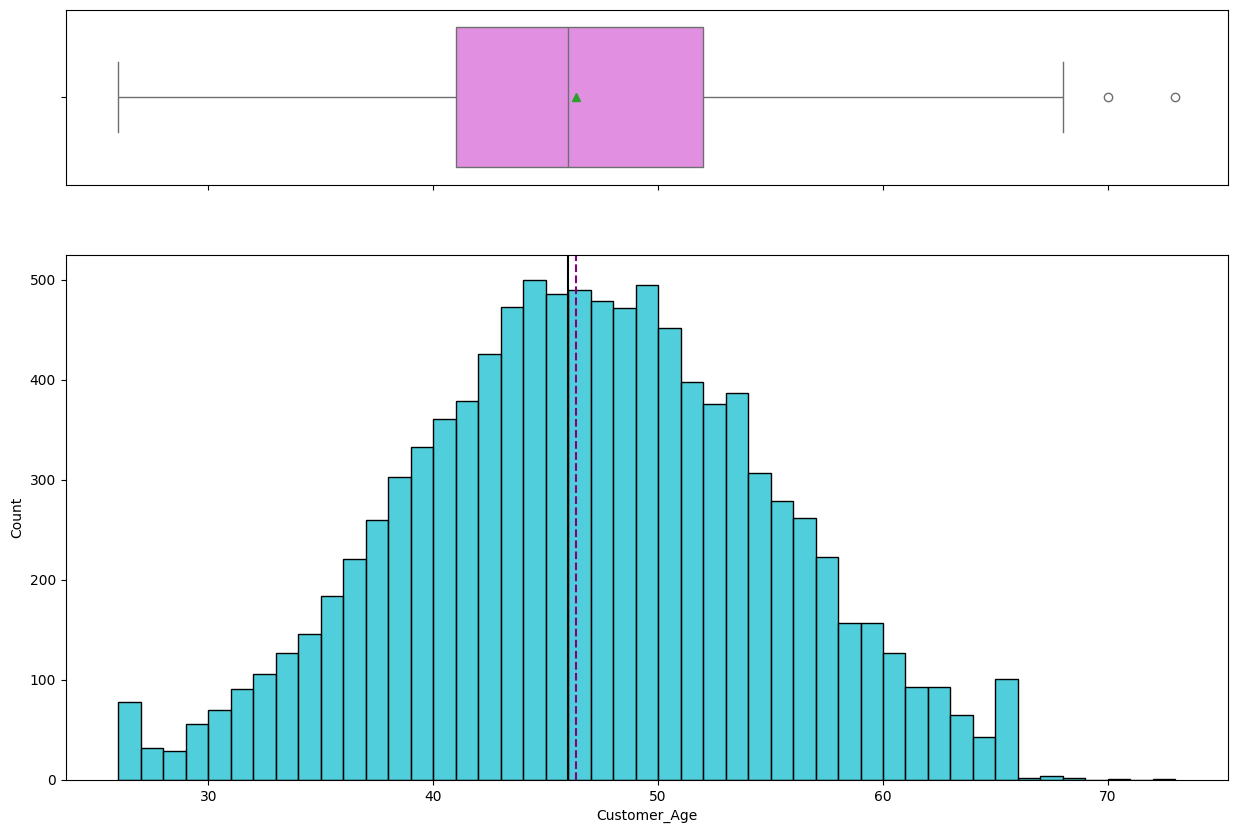

In [21]:
histogram_boxplot(data['Customer_Age'])

* The distribution of Customer_Age is normally distributed with mean and median at 46 years.
* From the boxplot, we can see that there are a few outliers.

### Observations on Months_on_book

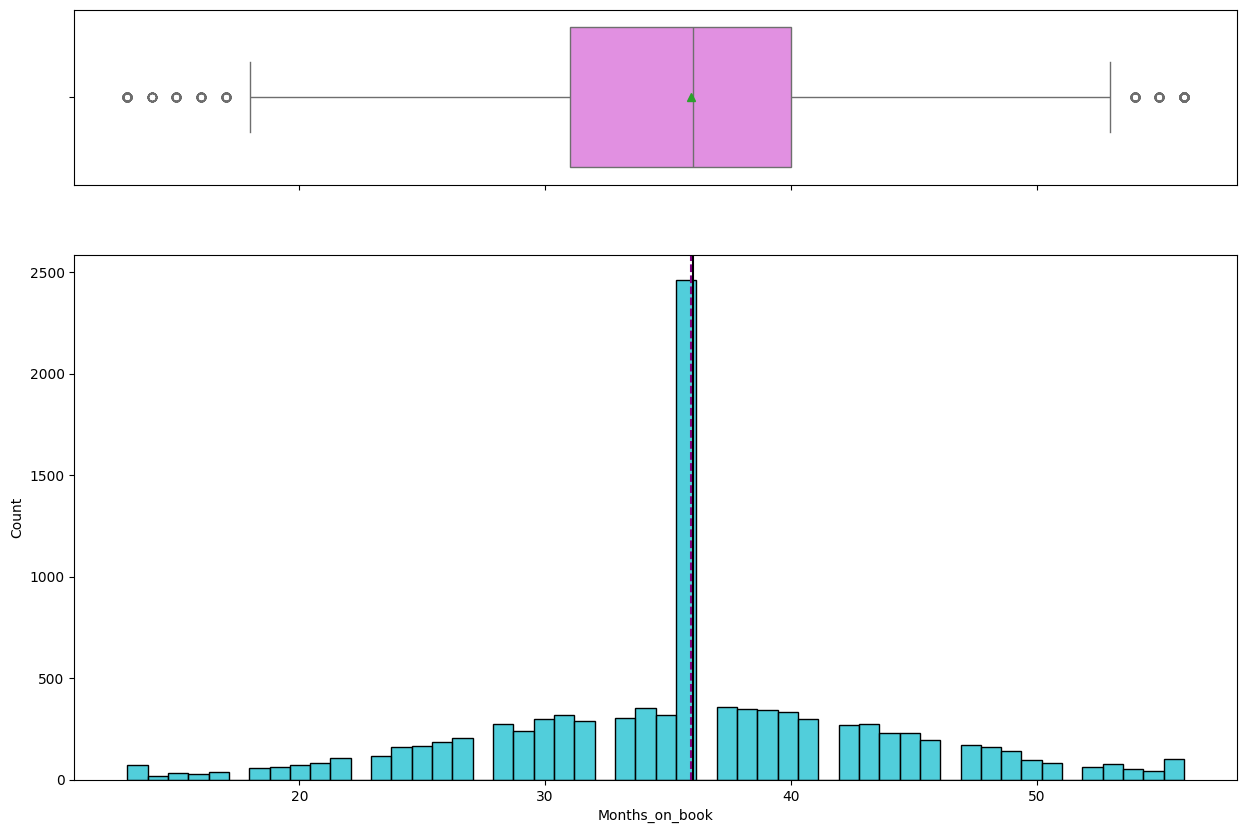

In [22]:
histogram_boxplot(data['Months_on_book'])

* Most customers are with the bank for 3 years.
* From the boxplot, we can see that there are outliers on both sides of the whiskers.

### Observations on Credit_Limit

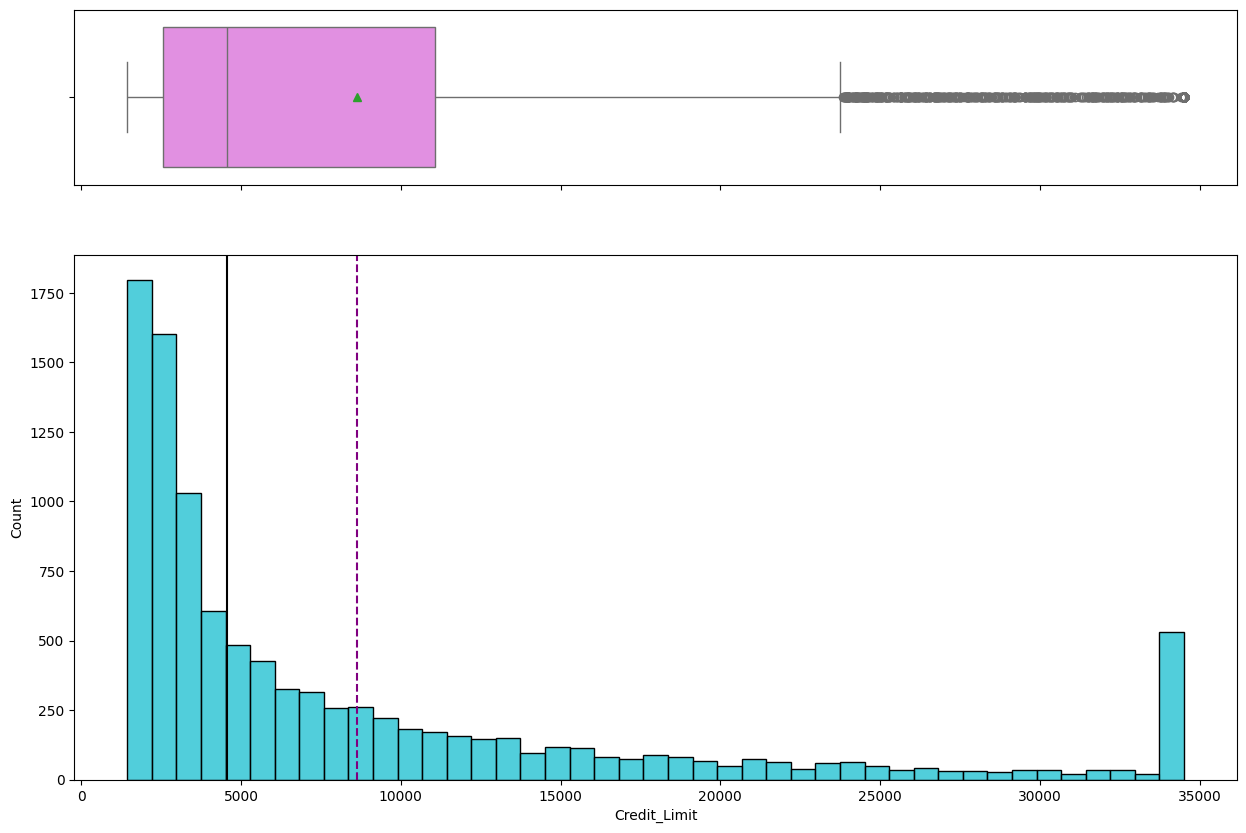

In [23]:
histogram_boxplot(data['Credit_Limit'])

* The distribution of the Credit_Limit is skewed to the right.
* There are quite a few customers with a maximum Credit Limit of 35000.
* 50% of the customers of the bank have a credit limit of less than <5000.

### Observations on Total_Revolving_Bal

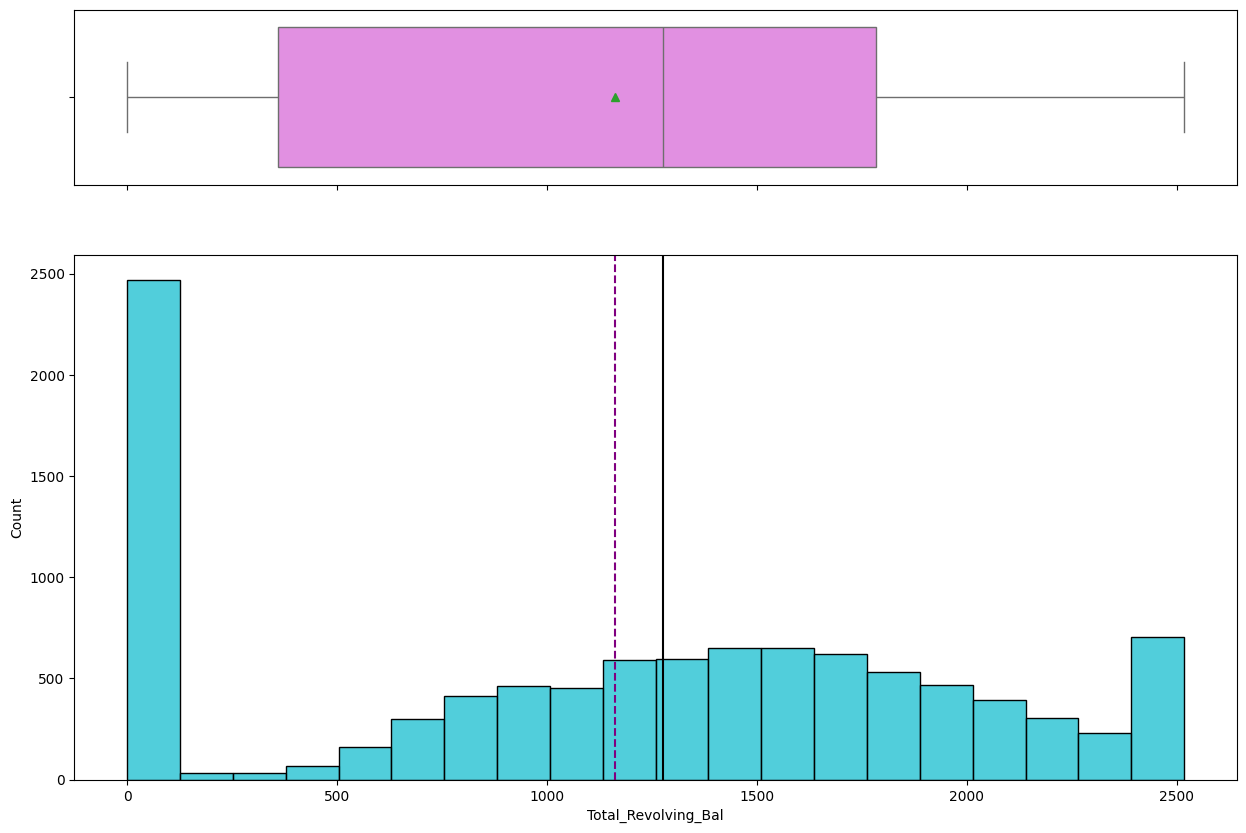

In [24]:
histogram_boxplot(data['Total_Revolving_Bal'])

* Most customers pay the complete dues of credit card and have 0 revolving balance.
* There are quite a few customers with a revolving balance of 2500.

### Observations on Avg_Open_To_Buy

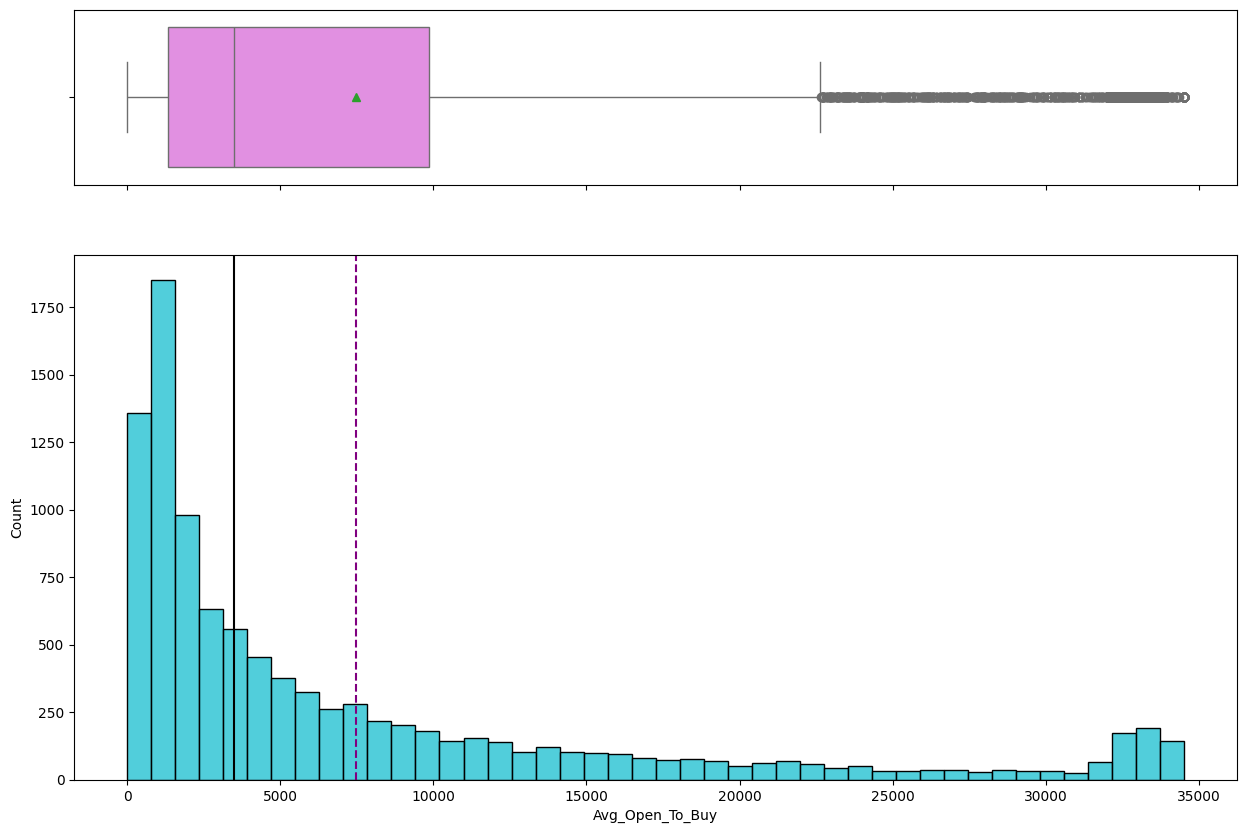

In [25]:

histogram_boxplot(data['Avg_Open_To_Buy'])

* The distribution of the Avg_Open_To_Buy column is right-skewed.
* A right-skewed distribution indicates that most customers used a big part of their limit while only a few customers (on the right tail) were left with a majority of their credit amount.

### Observations on Total_Trans_Ct

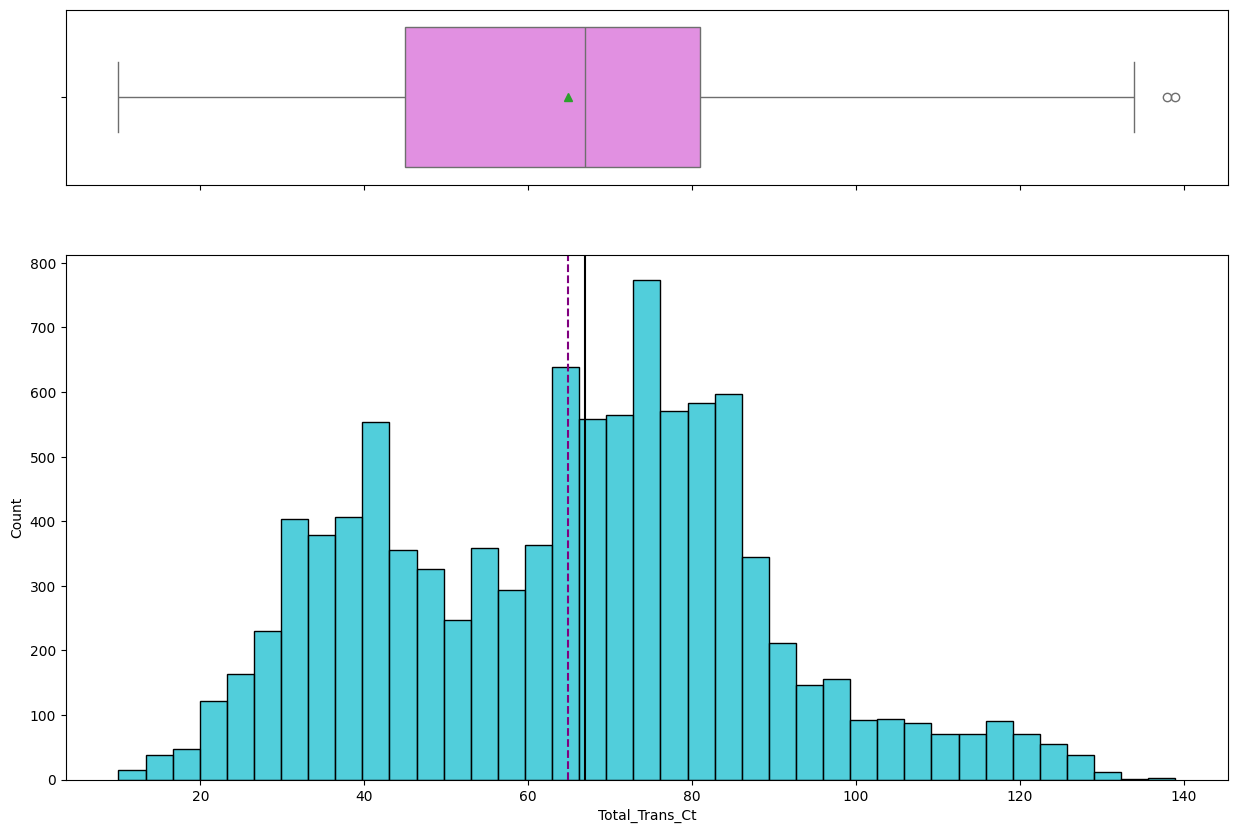

In [26]:
histogram_boxplot(data['Total_Trans_Ct'])

* The distribution of Total_Trans_Ct shows two peaks on 40 and 80 transactions in a year which indicates that customers used credit cards 3 to 6 times a month to make transactions.

### Observations on Total_Amt_Chng_Q4_Q1

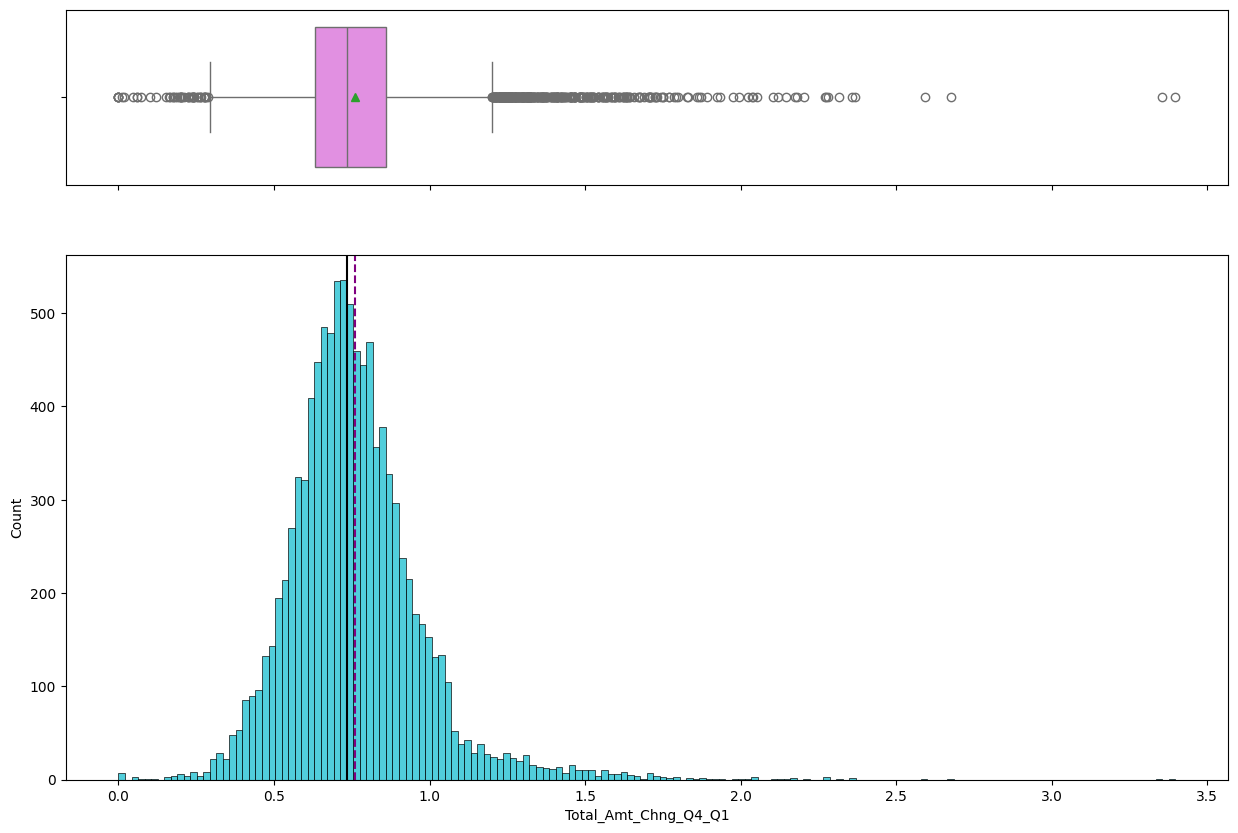

In [27]:

histogram_boxplot(data['Total_Amt_Chng_Q4_Q1'])

* The distribution of Total_Amt_Chng_Q4_Q1 looks normally distributed but there's a slight skew towards the right.
* From the boxplot, we can see that there are outliers on both sides of the whiskers.

### Observations on Total_Trans_Amt

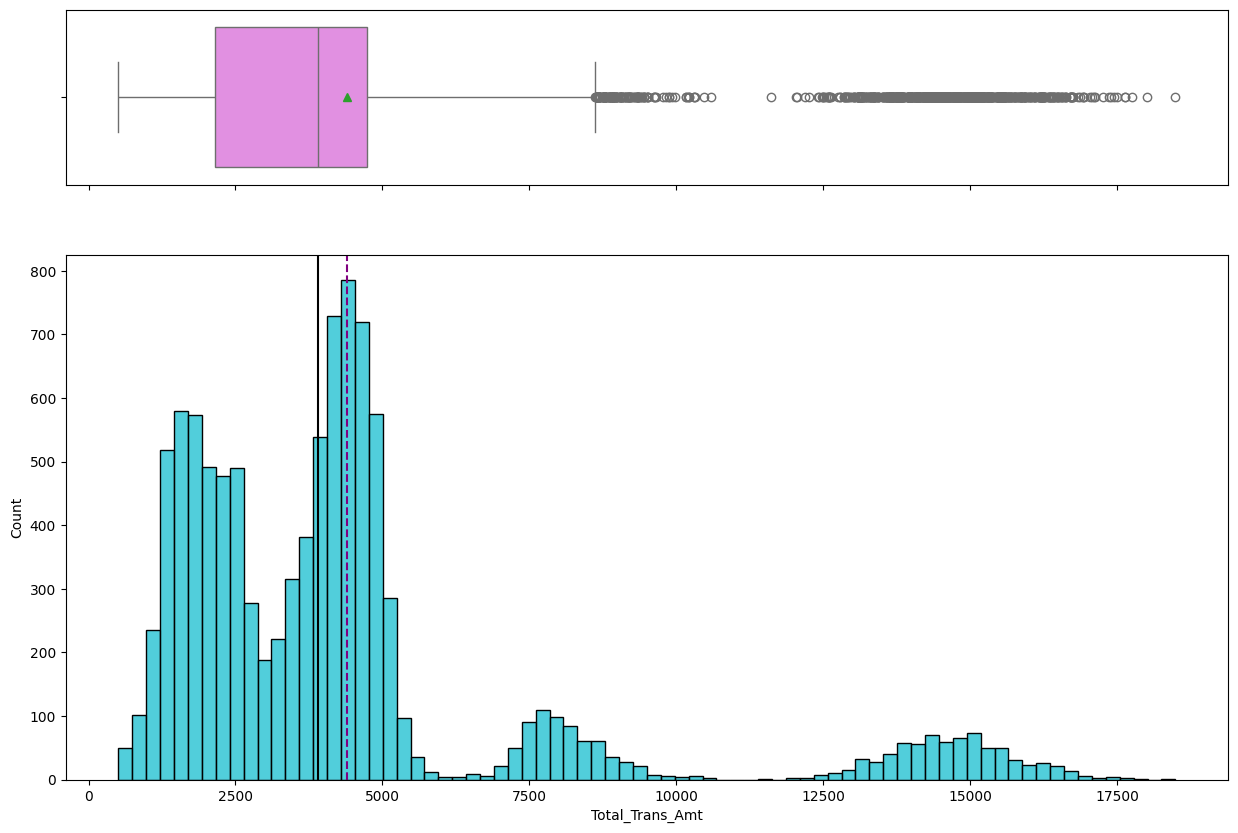

In [28]:
histogram_boxplot(data['Total_Trans_Amt'])

* The distribution of Total_Trans_Amt is skewed to the right.
* There are two peaks in data at total transaction amounts of one around 2500 and second around the mean value of ~4500.
* From the boxplot, we can see that there are outliers - customers with more than ~8000 total transaction amounts are being considered as outliers.
* It would be interesting to check if the customers spending less with the card are the ones churning or the ones spending more are churning, if the latter is the case then there is a problem for the bank as it is losing valuable customers.

### Observations on Total_Ct_Chng_Q4_Q1

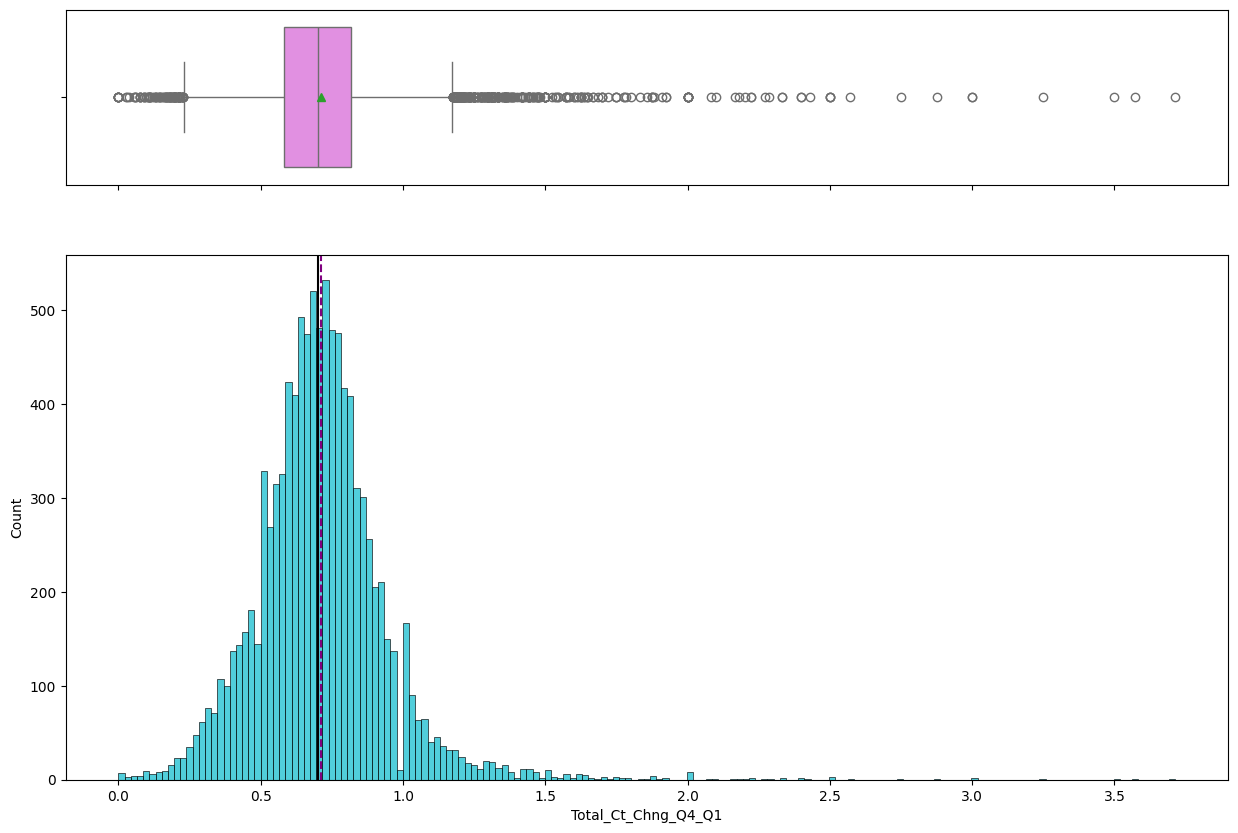

In [29]:
histogram_boxplot(data['Total_Ct_Chng_Q4_Q1'])

* The distribution of Total_Ct_Chng_Q4_Q1 looks normally distributed but there's a slight skew towards the right.
* From the boxplot, we can see that there are outliers on both sides of the whiskers.

### Observations on Avg_Utilization_Ratio

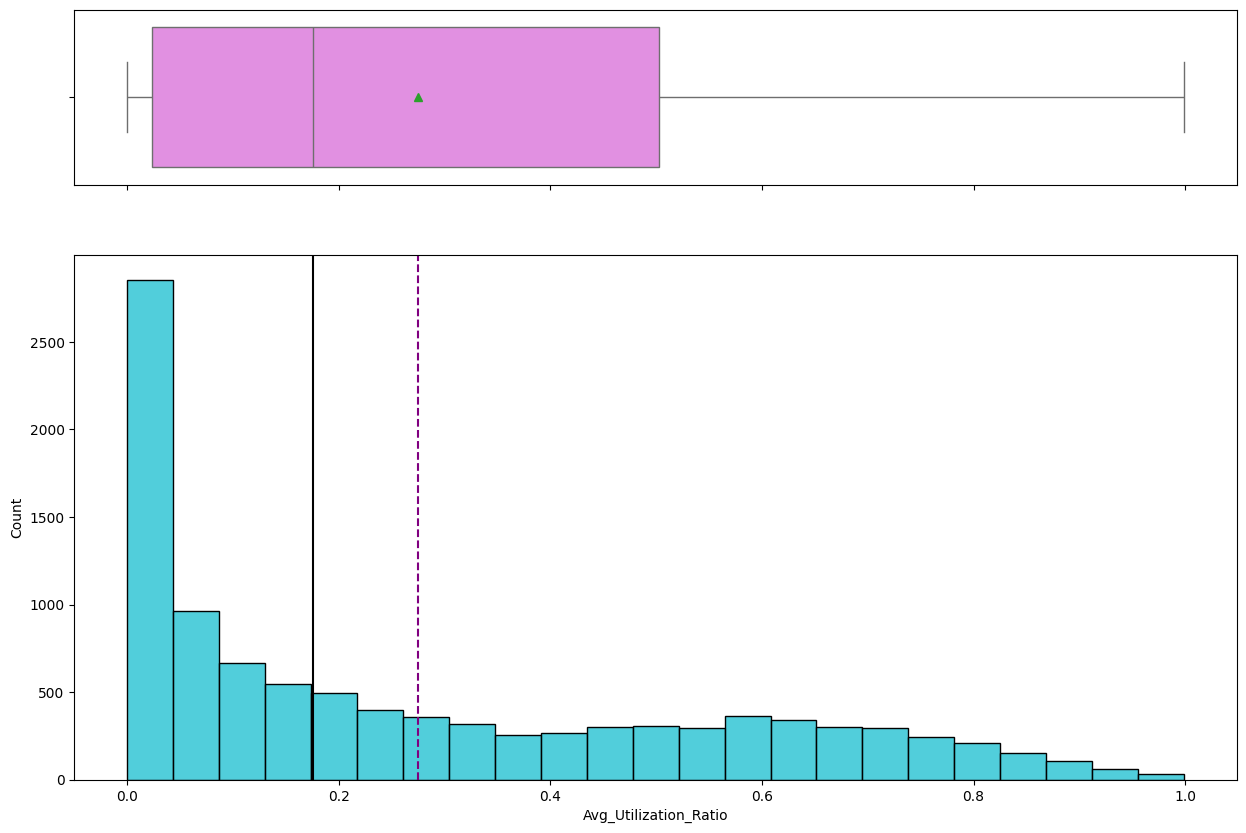

In [30]:
histogram_boxplot(data['Avg_Utilization_Ratio'])

* The distribution of Avg_Utilization_Ratio is skewed to the right.
* This distribution is not a positive sign for the bank as most of the customers are not utilizing their credit amount.

In [34]:
# Function to create barplots that indicate percentage for each category.
def perc_on_bar(z):
    '''
    feature: categorical column name
    Plots the count of each category with its % of rows on top of the bar.
    '''
    total = len(data[z])                                   # number of rows
    plt.figure(figsize=(15, 5))
    ax = sns.countplot(x=data[z], hue=data[z], palette='Paired', legend=False)   # x= -> vertical bars
    for p in ax.patches:
        if p.get_height() == 0:                            # skip empty bars
            continue
        percentage = '{:.1f}%'.format(100 * p.get_height() / total)
        x = p.get_x() + p.get_width() / 2                  # centre of the bar
        y = p.get_height()                                 # top of the bar
        ax.annotate(percentage, (x, y), ha='center', va='bottom', size=12)
    ax.margins(y=0.1)                                      # headroom so the top label isn't clipped
    plt.show()

### Observations on Dependent_count

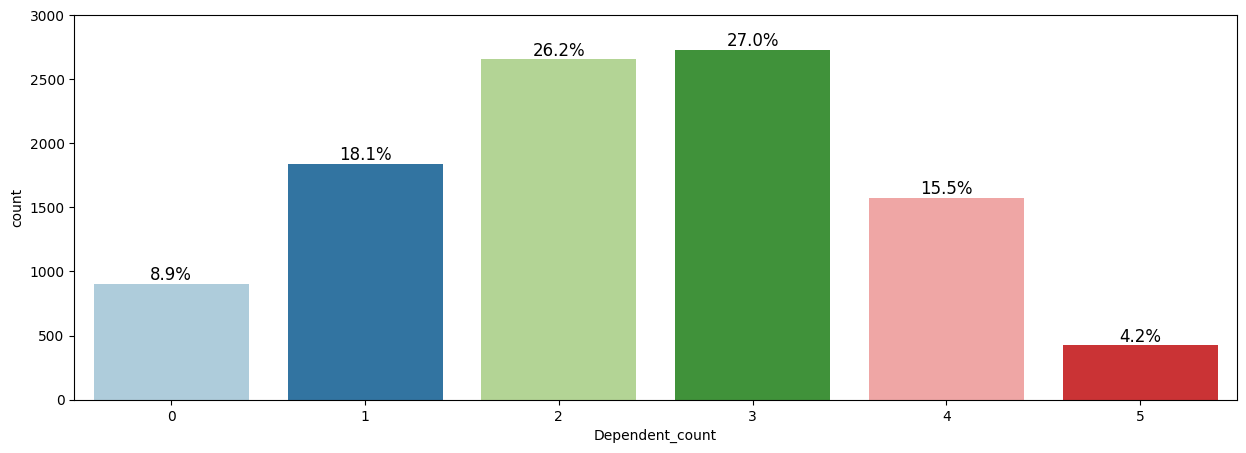

In [35]:
perc_on_bar('Dependent_count')

* The distribution of dependents is very realistic with most customers having 2 or 3 dependents.

### Observations on Total_Relationship_Count

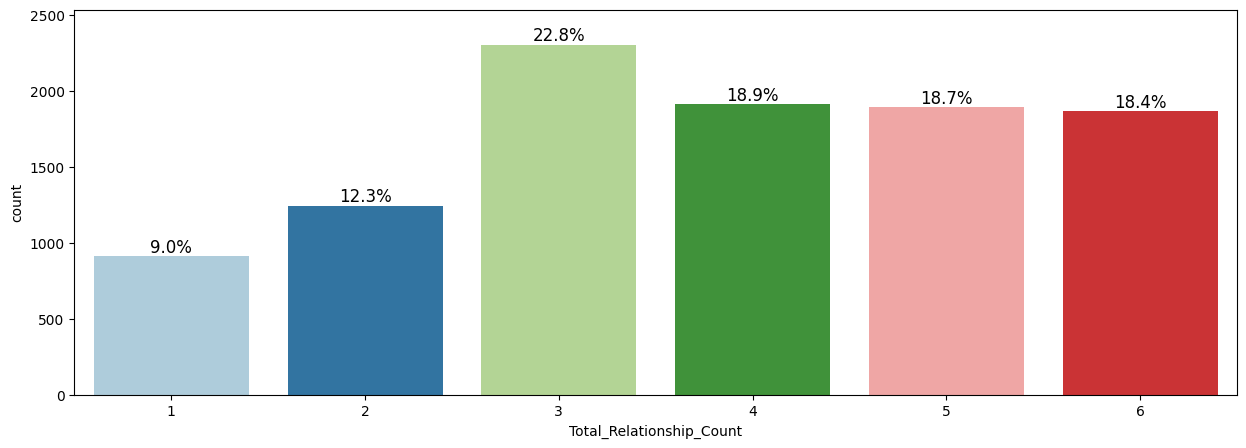

In [36]:
perc_on_bar('Total_Relationship_Count')

* 22.8% of the customers are using 3 products offered by the bank while an equal percentage ~19% of customers use 4 or more than 4 products.
* Equal percentage of customers using 4,5 and 6 products might suggest that customers who opt or buy the 4th product will also be ready to buy more products.

### Observations on Months_Inactive_12_mon

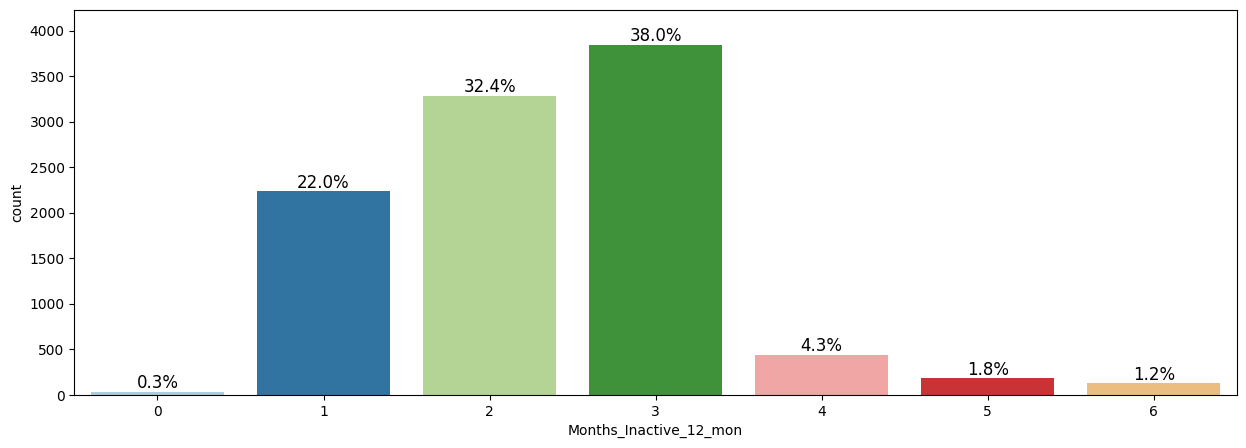

In [37]:
perc_on_bar('Months_Inactive_12_mon')

* Around 7.5% of the customers were inactive for more than 3 months.

### Observations on Contacts_Count_12_mon

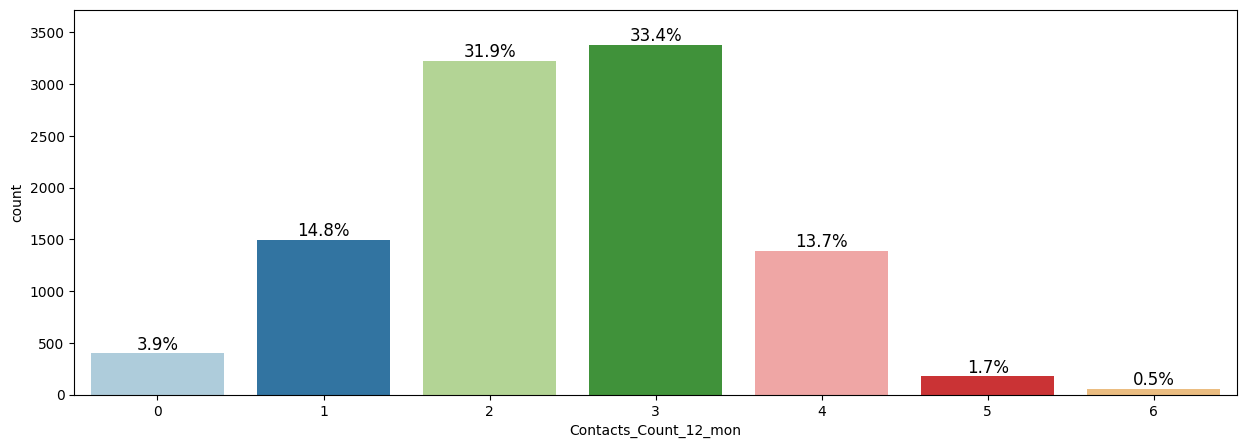

In [39]:
perc_on_bar('Contacts_Count_12_mon')

* ~16% of the customers interacted with the bank more than 3 times in the past 12 months.

### Observations on Gender

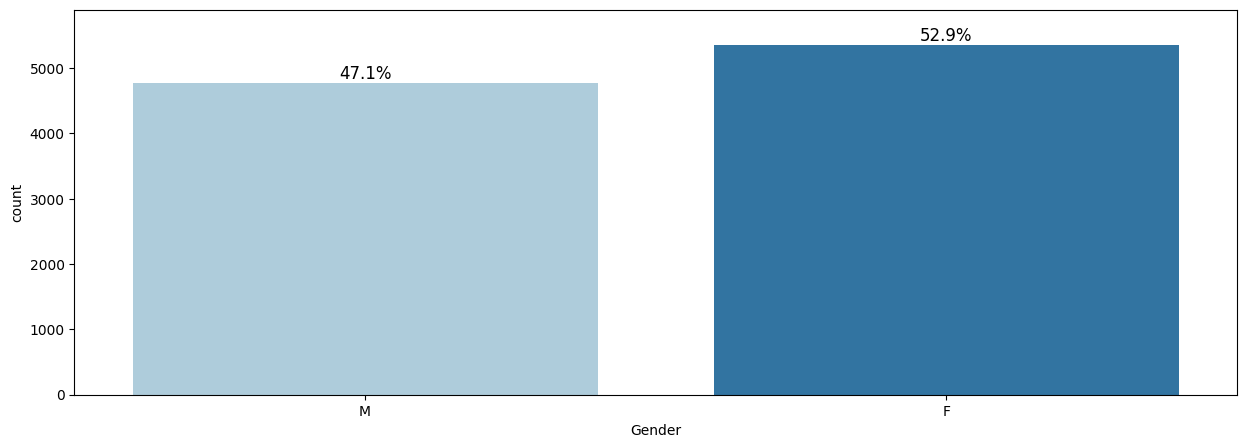

In [40]:
perc_on_bar('Gender')

* We have Male 47% and Female 53% of customers.

### Observations on Education_Level

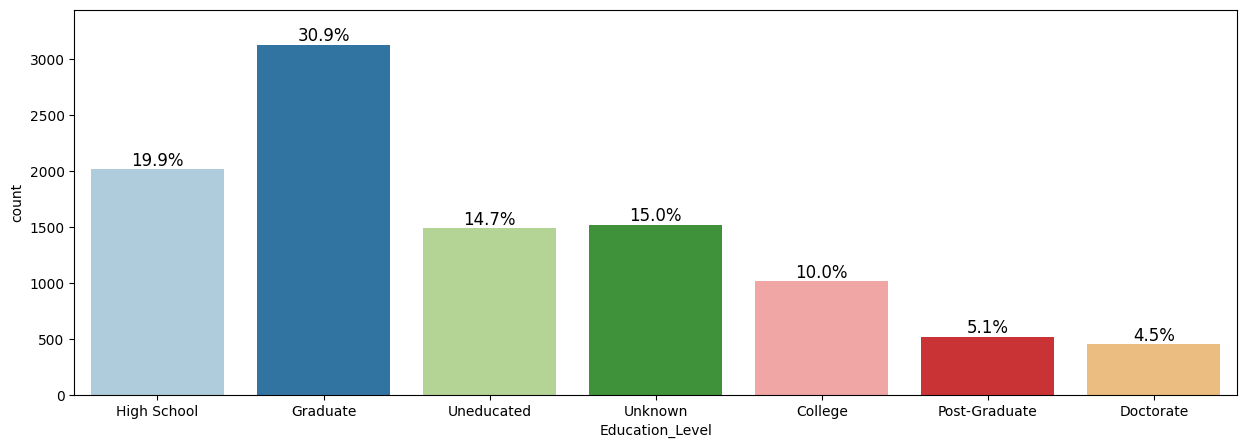

In [41]:
perc_on_bar('Education_Level')

* 30.9% of the customers are graduates, followed by 19.9% of the customers who completed high school.
* Percentage of missing value in Education_Level column - 15%.

### Observations on Marital_Status

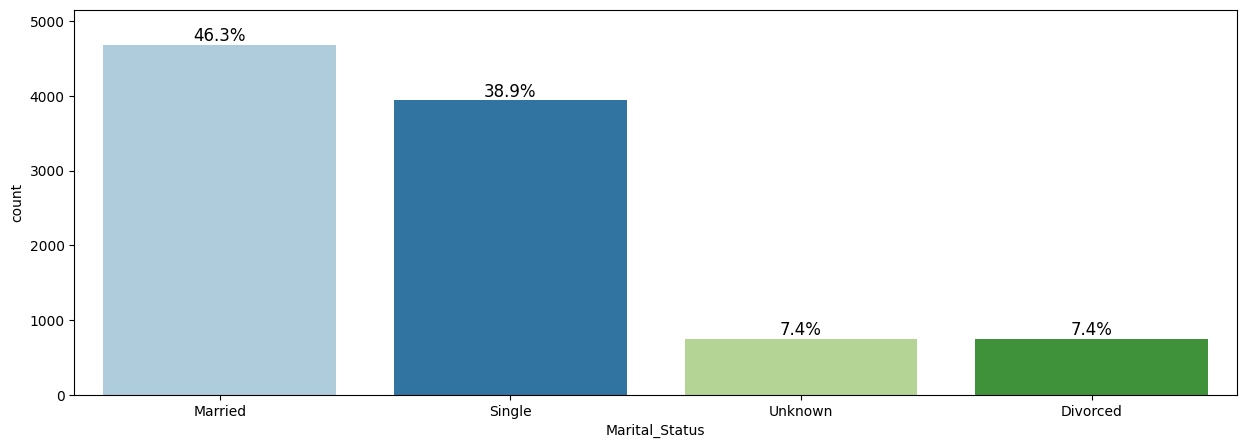

In [42]:
perc_on_bar('Marital_Status')

* 46.3% of the customers are Married, followed by 38.9% of Single customers.
* Percentage of missing value in Marital_Status column - 7.4%.

### Observations on Income_Category

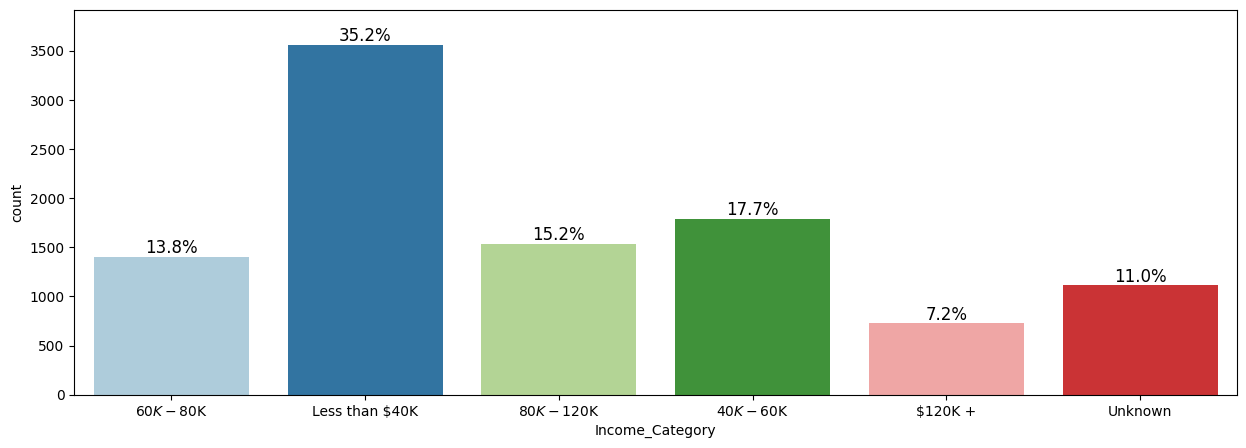

In [43]:
perc_on_bar('Income_Category')

* 35.2% of the customers lie in the Less than 40k income category group, followed by 17.7% of the customers in the 40k-60k income group.
* Percentage of missing value in Income_Category column - 11%.

### Observations on Card_Category

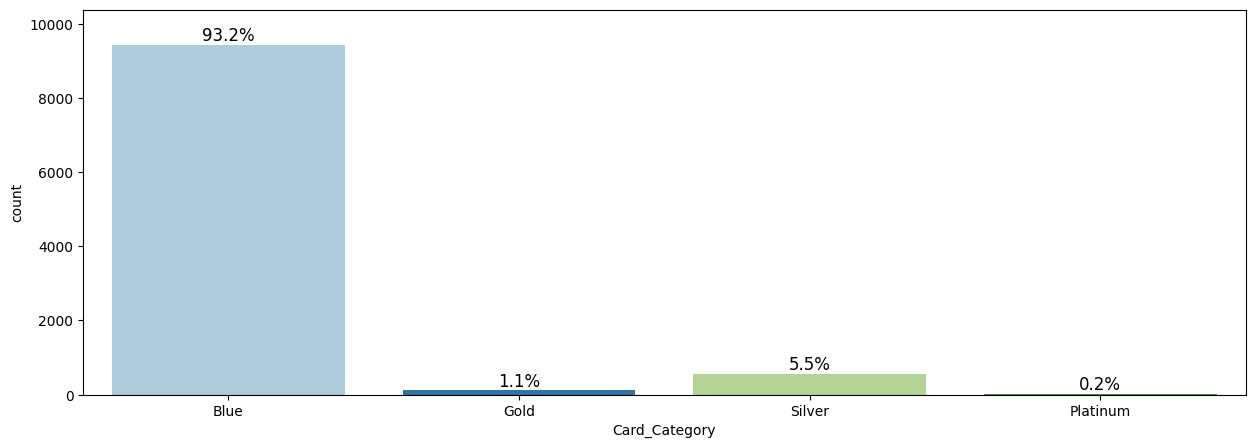

In [44]:
perc_on_bar('Card_Category')

* 93.2% of the customers have the Blue card.
* Blue card would be a standard card given by the bank to all its customers.

### Observations on Attrition_Flag

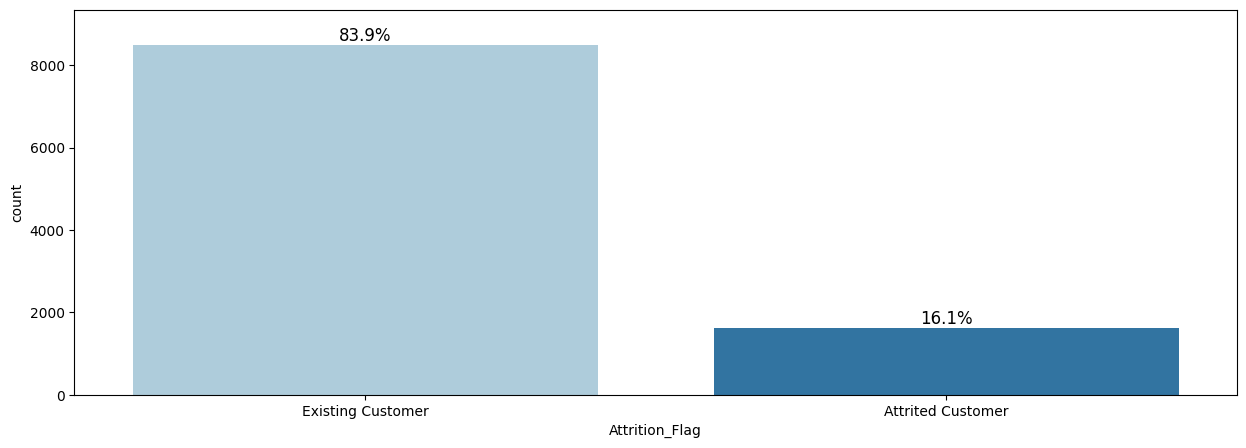

In [45]:
perc_on_bar('Attrition_Flag')

* 16.1% of the customers attrited.
* This indicates an imbalance in the data.

## Bivariate Analysis

In [60]:
## Encoding Existing and Attrited customers to 0 and 1 respectively, for analysis.
data['Attrition_Flag'] = data['Attrition_Flag'].replace({'Existing Customer': 0, 'Attrited Customer': 1}).astype(int)

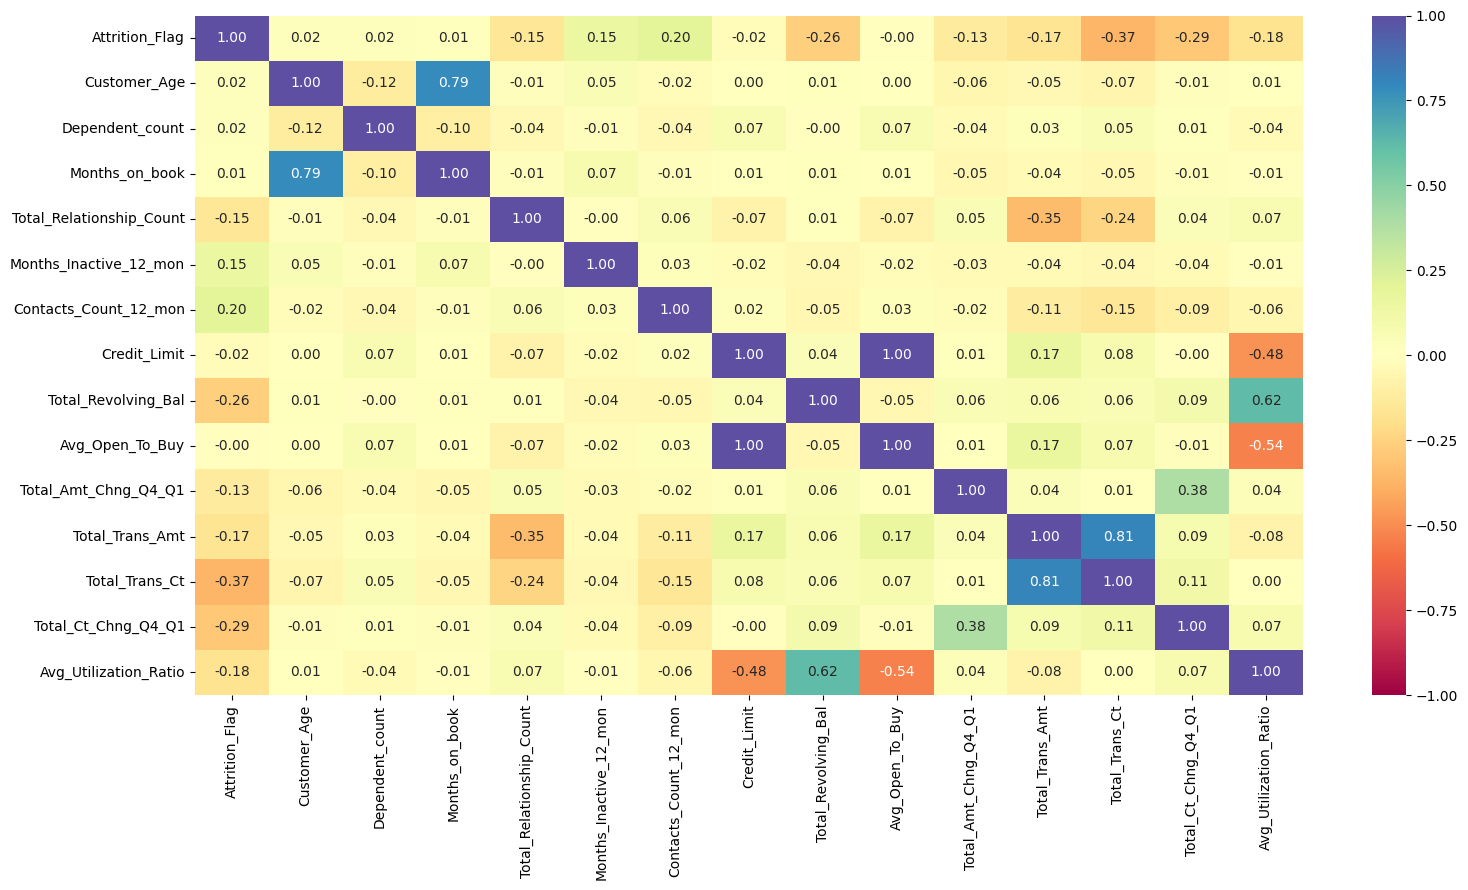

In [61]:
plt.figure(figsize=(16, 9))
sns.heatmap(data.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, fmt='.2f', cmap='Spectral')
plt.tight_layout()   # stops the long column names at the bottom from being cut off
plt.show()

* Attrition_Flag shows a bit of a negative correlation with Total_Trans_Ct (total transactions) and Total_Trans_Amt (total transaction amount).
* There's a strong positive correlation between Months_on_book and Customer_Age, Total_Revolving_Bal and Avg_Utilization_Ratio, Total_Trans_Amt and Total_Trans_Ct.
* There's a negative correlation of Total_Relationship_count with Total_Trans_Amt and Total_Trans_Ct, Avg_Utilization_Ratio with Credit_Limit and Avg_Open_To_Buy.

In [62]:
### Function to plot stacked bar charts for categorical columns

def stacked_plot(x):
    ## counts, with row/column totals
    tab1 = pd.crosstab(x, data['Attrition_Flag'], margins=True).sort_values(by=1, ascending=False)
    print(tab1)
    print('-' * 120)
    ## share of each category that stayed (0) vs churned (1), highest churn first
    tab = pd.crosstab(x, data['Attrition_Flag'], normalize='index').sort_values(by=1, ascending=False)
    ax = tab.plot(kind='bar', stacked=True, figsize=(17, 7), rot=0)
    ax.legend(['Existing (0)', 'Attrited (1)'], loc='upper left', bbox_to_anchor=(1, 1), frameon=False)
    ax.set_ylabel('share of customers')
    plt.tight_layout()
    plt.show()

### Attrition_Flag vs Gender

Attrition_Flag     0     1    All
Gender                           
All             8500  1627  10127
F               4428   930   5358
M               4072   697   4769
------------------------------------------------------------------------------------------------------------------------


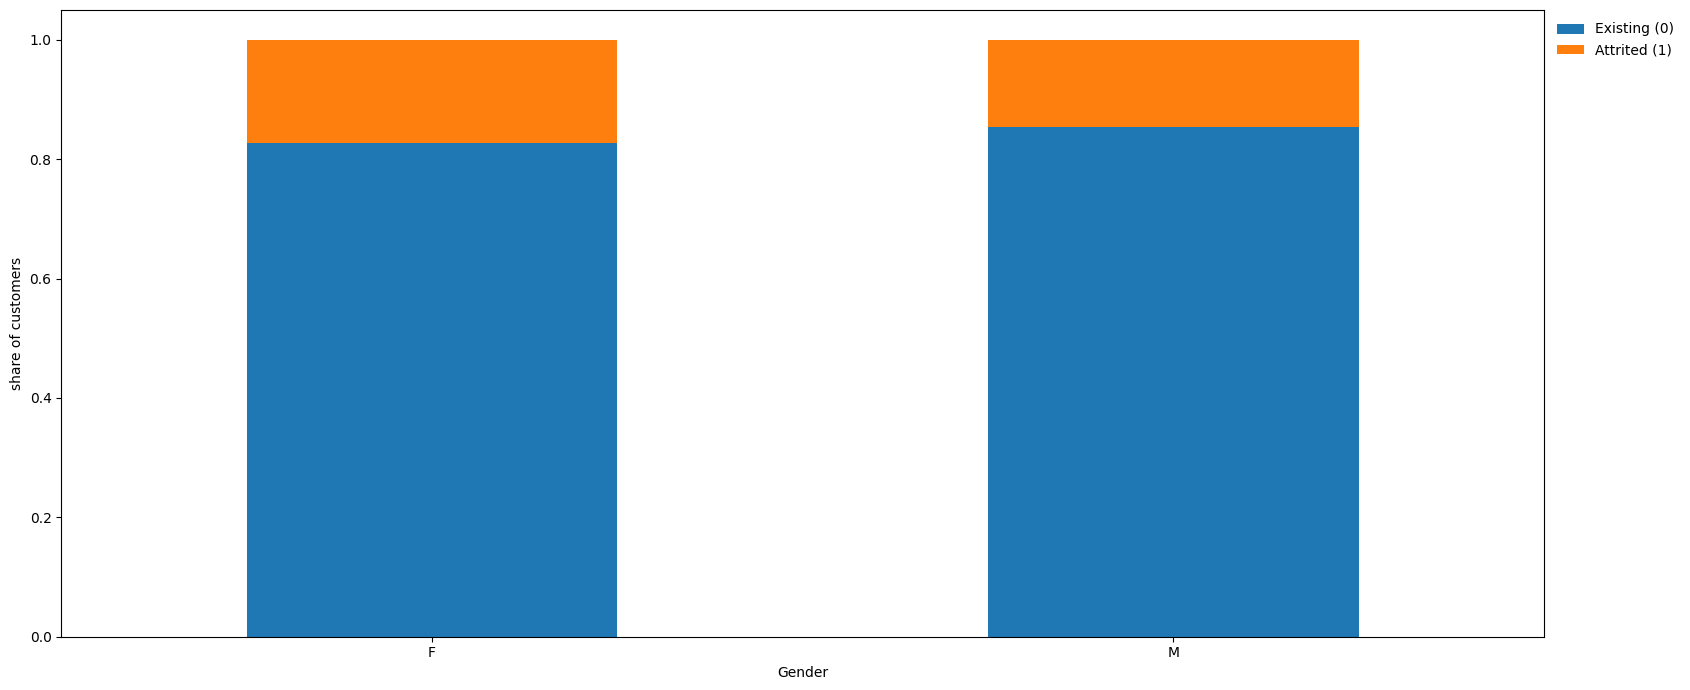

In [63]:
stacked_plot(data['Gender'])

* There's not much difference in attrition percentages for Males and Females.
* ~20% of both Males and Females attrite.

### Attrition_Flag vs Marital_Status

Attrition_Flag     0     1    All
Marital_Status                   
All             8500  1627  10127
Married         3978   709   4687
Single          3275   668   3943
Unknown          620   129    749
Divorced         627   121    748
------------------------------------------------------------------------------------------------------------------------


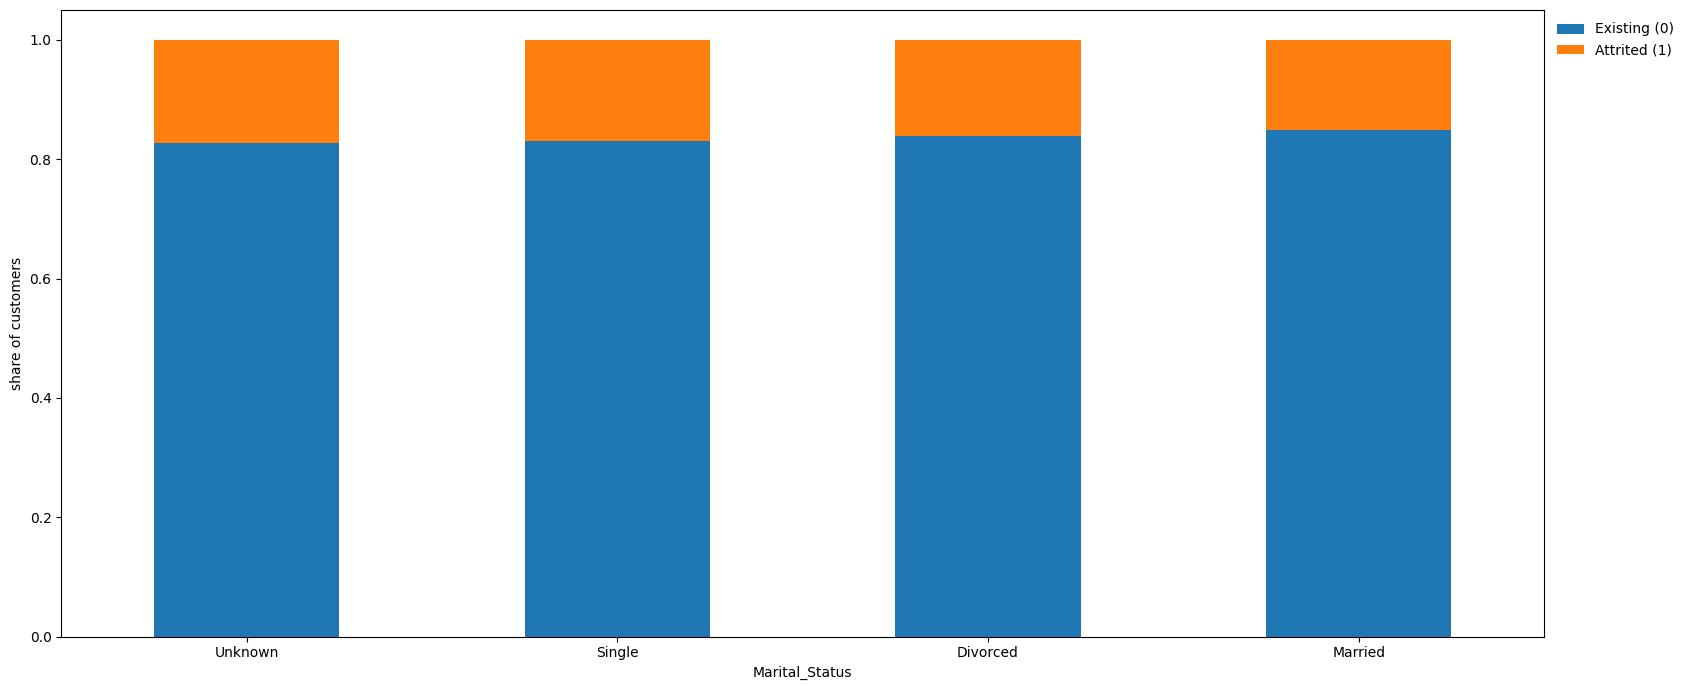

In [64]:
stacked_plot(data['Marital_Status'])

* There's not much difference in attrition percentages for Marital_Status.
* ~20% of Singles, Divorced attrite.
* Married customers attrite the least.

### Attrition_Flag vs Education_Level

Attrition_Flag      0     1    All
Education_Level                   
All              8500  1627  10127
Graduate         2641   487   3128
High School      1707   306   2013
Unknown          1263   256   1519
Uneducated       1250   237   1487
College           859   154   1013
Doctorate         356    95    451
Post-Graduate     424    92    516
------------------------------------------------------------------------------------------------------------------------


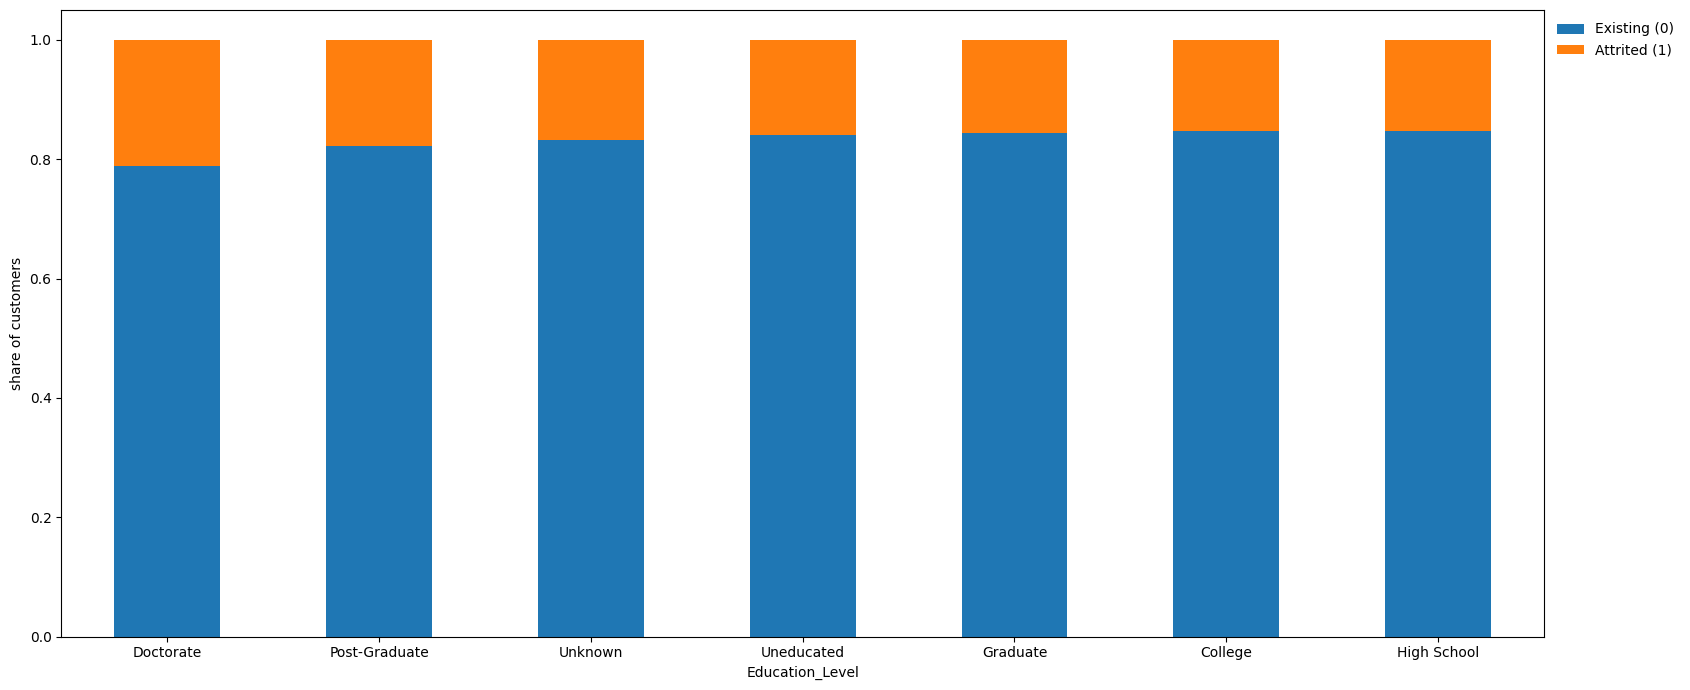

In [65]:
stacked_plot(data['Education_Level'])

* Customers with higher education -  Doctorates and Post Graduates are the ones most(~20% for both education levels) attriting.

### Attrition_Flag vs Income_Category

Attrition_Flag      0     1    All
Income_Category                   
All              8500  1627  10127
Less than $40K   2949   612   3561
$40K - $60K      1519   271   1790
$80K - $120K     1293   242   1535
$60K - $80K      1213   189   1402
Unknown           925   187   1112
$120K +           601   126    727
------------------------------------------------------------------------------------------------------------------------


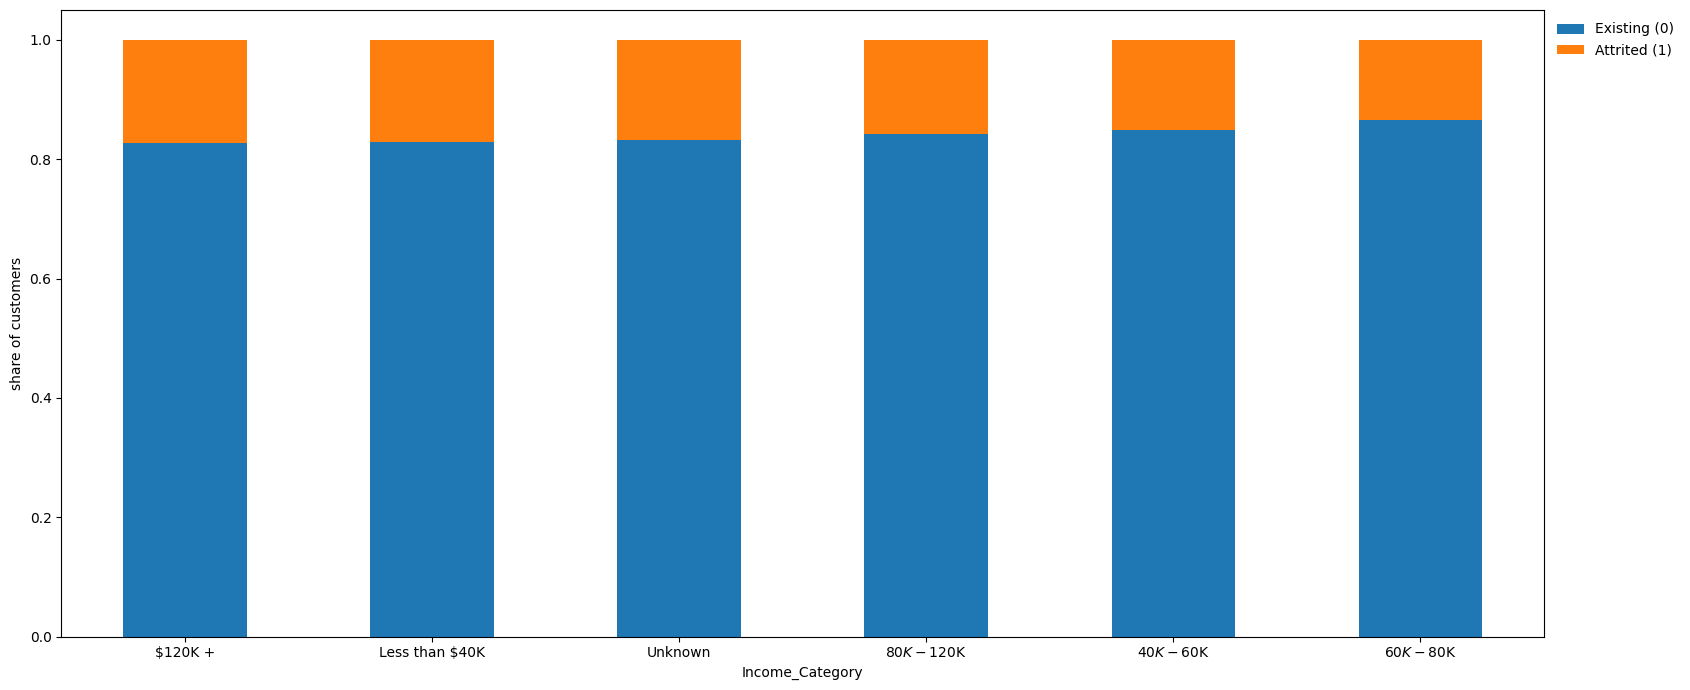

In [67]:
stacked_plot(data['Income_Category'])

* The customers from two extreme income groups - Earning less than 40K and Earning more than 120k+ are the ones attriting the most.

### Attrition_Flag vs Card_Category

Attrition_Flag     0     1    All
Card_Category                    
All             8500  1627  10127
Blue            7917  1519   9436
Silver           473    82    555
Gold              95    21    116
Platinum          15     5     20
------------------------------------------------------------------------------------------------------------------------


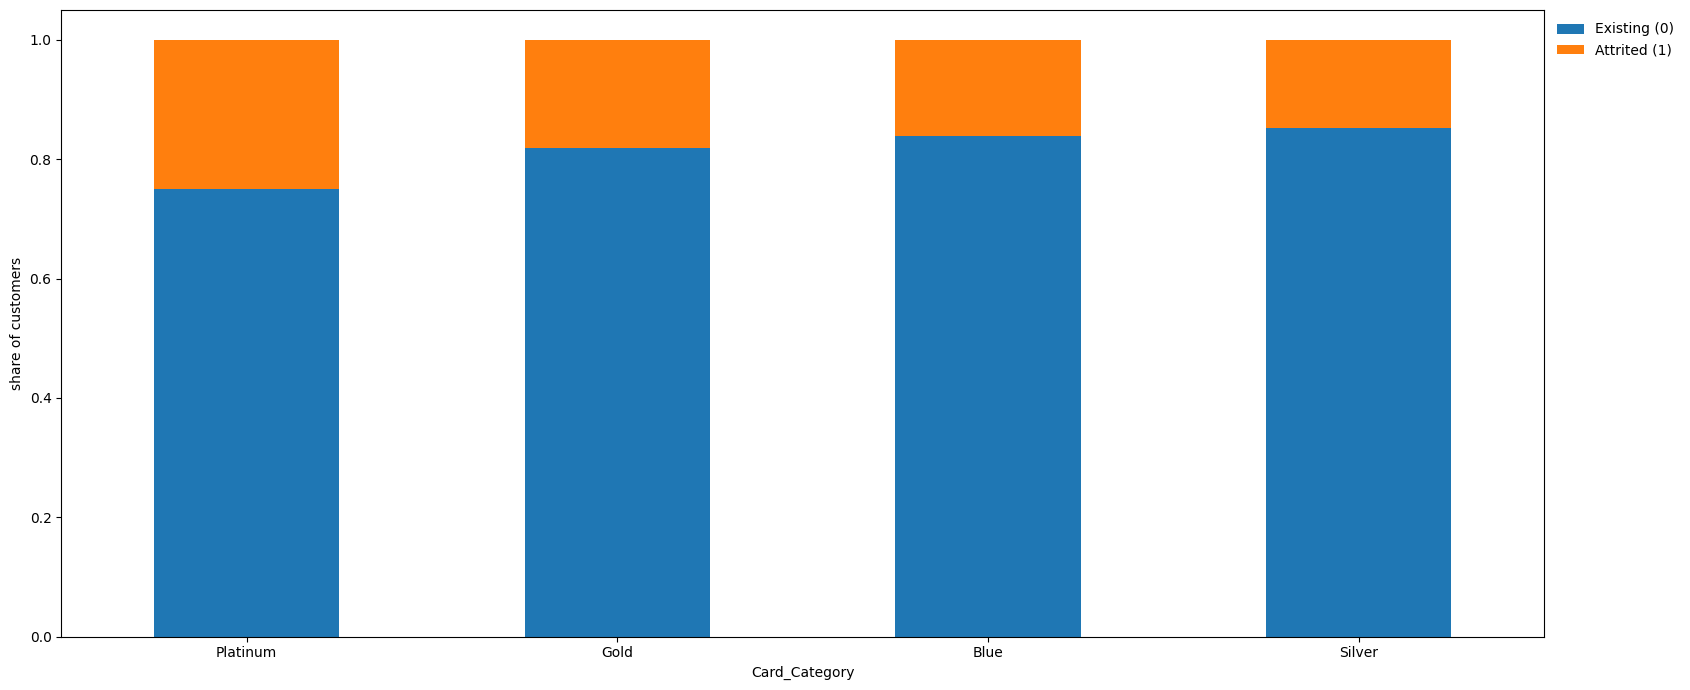

In [68]:
stacked_plot(data['Card_Category'])

* ~35% of attrition is amongst the customers with platinum cards followed by ~30% attrition in Gold cards.
* Customers with Platinum and Gold cards are our premium customers and the highest attrition for these customers is alarming as they are using the premium card provided by the bank.

### Attrition_Flag vs Contacts_Count_12_mon

Attrition_Flag            0     1    All
Contacts_Count_12_mon                   
All                    8500  1627  10127
3                      2699   681   3380
2                      2824   403   3227
4                      1077   315   1392
1                      1391   108   1499
5                       117    59    176
6                         0    54     54
0                       392     7    399
------------------------------------------------------------------------------------------------------------------------


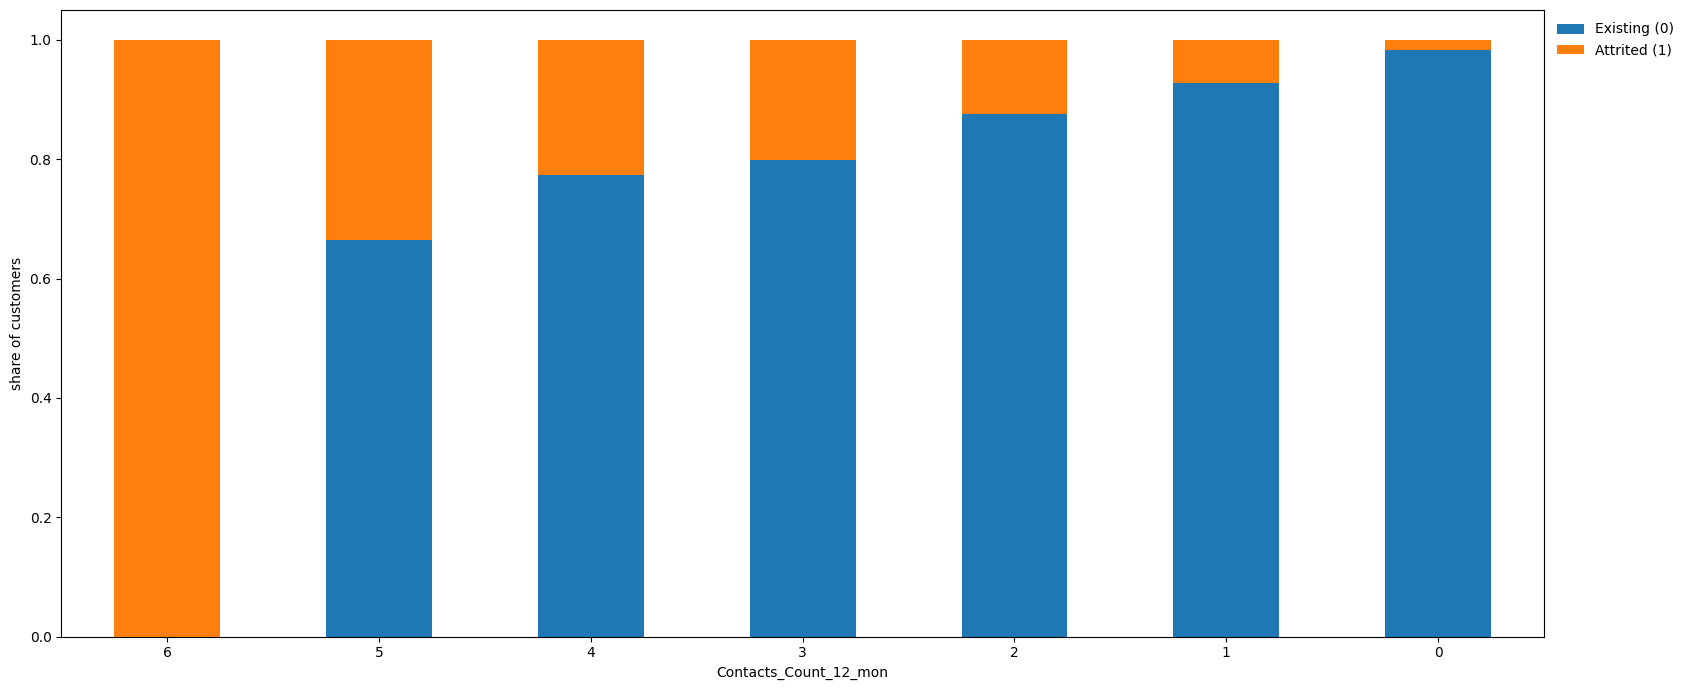

In [69]:
stacked_plot(data['Contacts_Count_12_mon'])

* Highest attrition is among the customers who interacted the most with the bank.
* This signifies that the bank is not able to resolve the problems faced by customers leading to attrition
* A preliminary step to identify attriting customers would be to look out for customers who have reached out to them repeatedly.

### Attrition_Flag vs Months_Inactive_12_mon

Attrition_Flag             0     1    All
Months_Inactive_12_mon                   
All                     8500  1627  10127
3                       3020   826   3846
2                       2777   505   3282
4                        305   130    435
1                       2133   100   2233
5                        146    32    178
6                        105    19    124
0                         14    15     29
------------------------------------------------------------------------------------------------------------------------


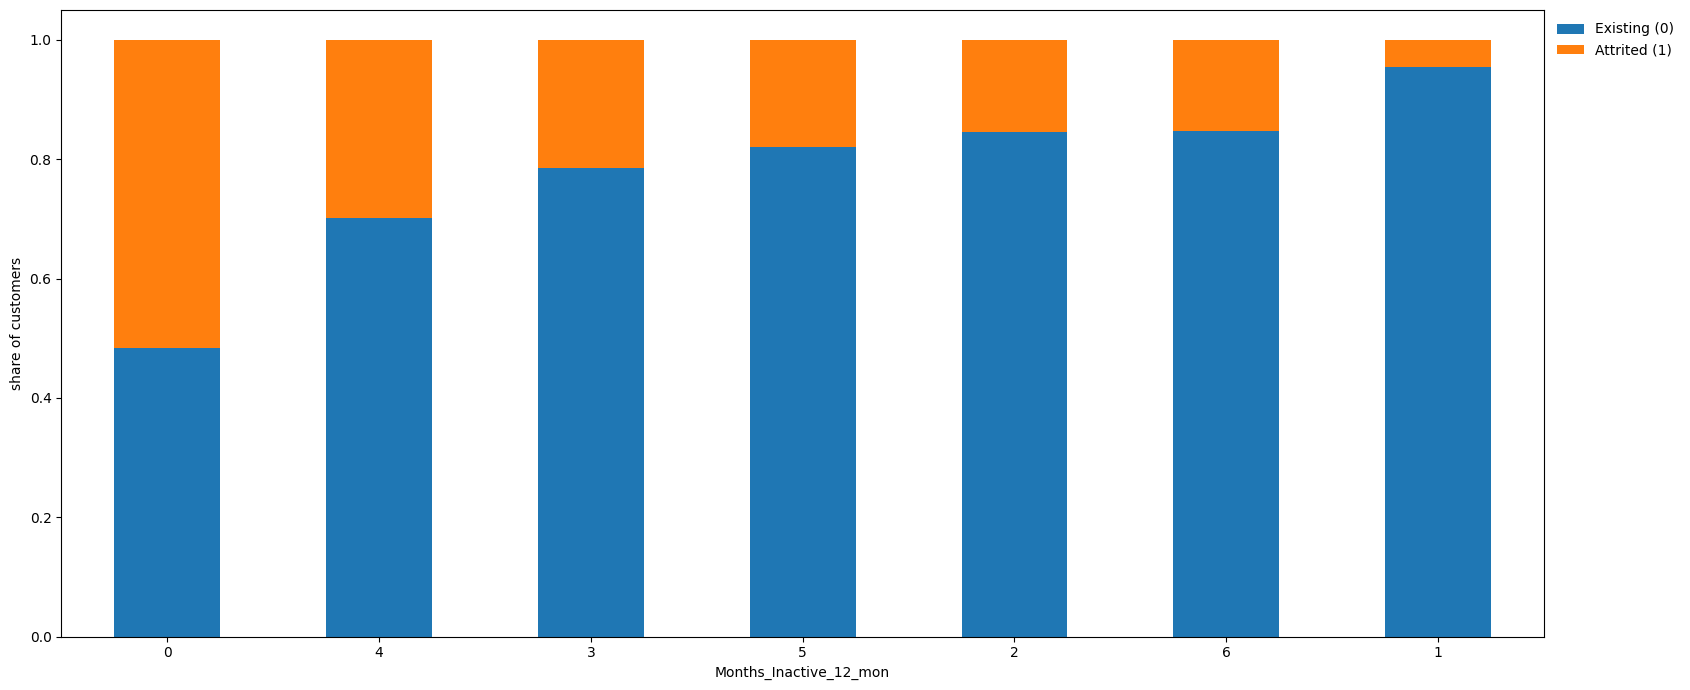

In [70]:
stacked_plot(data['Months_Inactive_12_mon'])

* As inactivity increases attrition also increases (2-4 months)
* The interpretation from here for 0 months and 6 months is difficult as customers who recently used the card attrited the most while those who were inactive for 6 months attrited less.

### Attrition_Flag vs Total_Relationship_Count

Attrition_Flag               0     1    All
Total_Relationship_Count                   
All                       8500  1627  10127
3                         1905   400   2305
2                          897   346   1243
1                          677   233    910
5                         1664   227   1891
4                         1687   225   1912
6                         1670   196   1866
------------------------------------------------------------------------------------------------------------------------


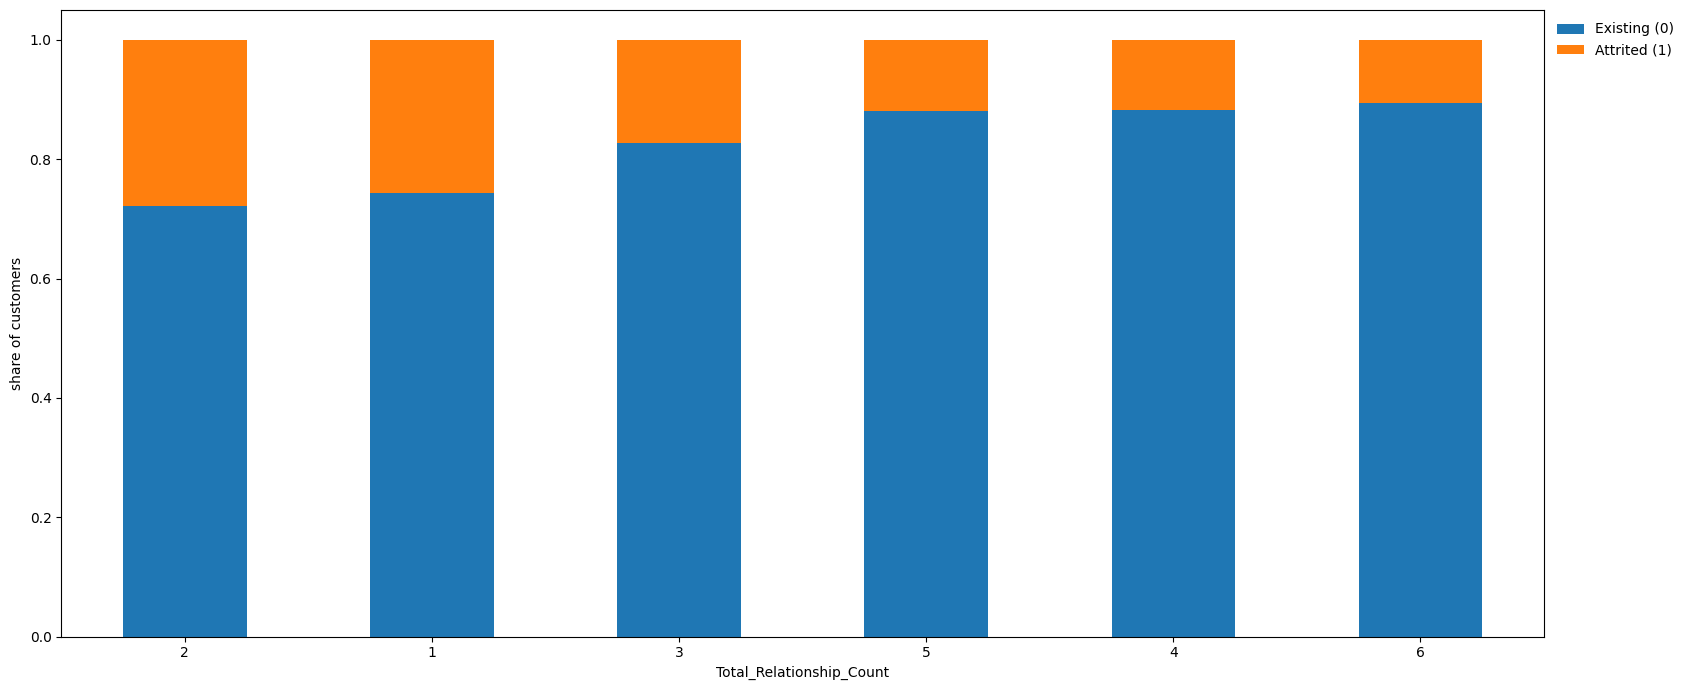

In [71]:
stacked_plot(data['Total_Relationship_Count'])

* Attrition is highest among the customers who are using 1 or 2 products offered by the bank - together they constitute ~55% of the attrition.
* Customers who use more than 3 products are the ones least attriting, such customers might be more financially stable and actively invest in different services provided by the bank.

### Attrition_Flag vs Dependent_count

Attrition_Flag      0     1    All
Dependent_count                   
All              8500  1627  10127
3                2250   482   2732
2                2238   417   2655
1                1569   269   1838
4                1314   260   1574
0                 769   135    904
5                 360    64    424
------------------------------------------------------------------------------------------------------------------------


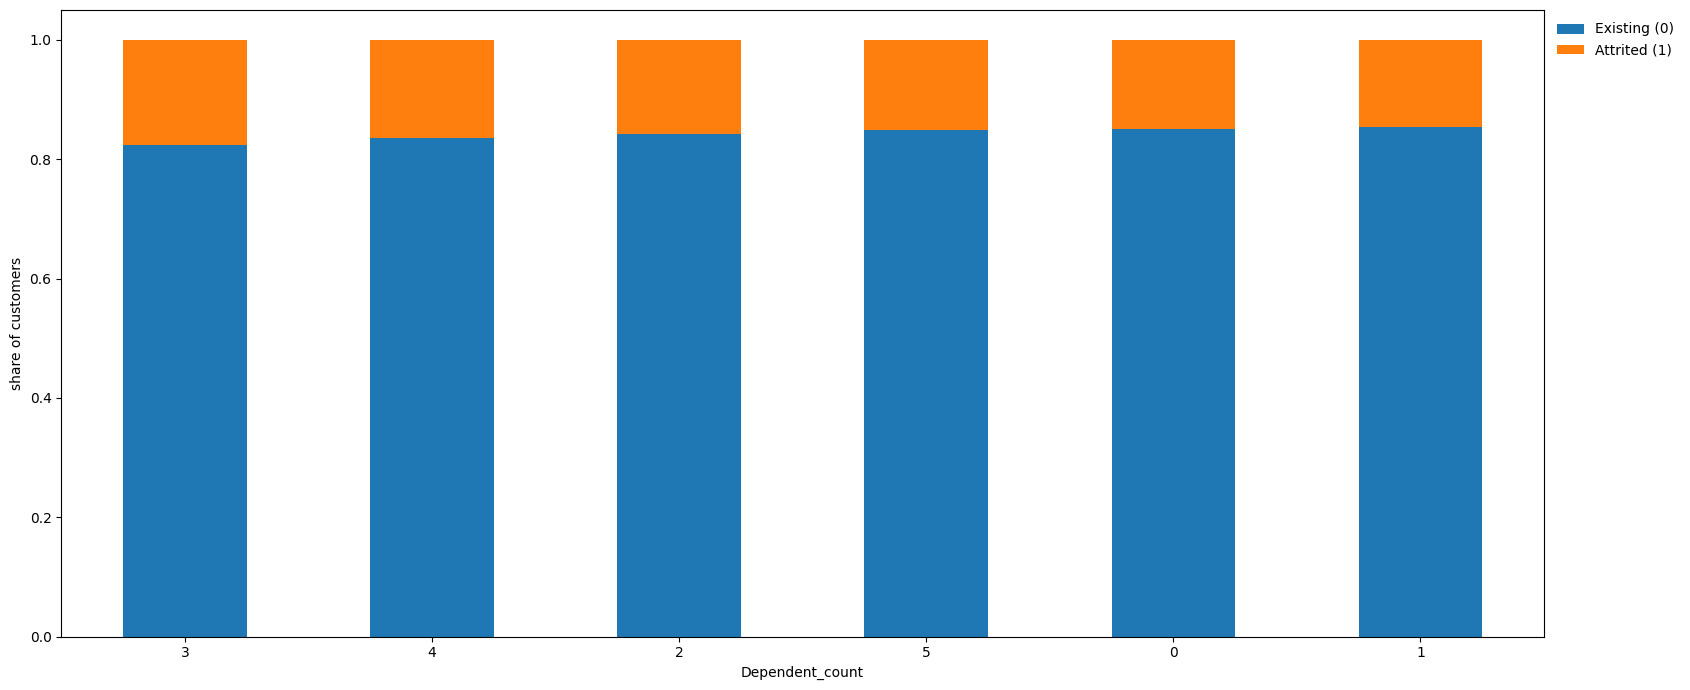

In [72]:
stacked_plot(data['Dependent_count'])

* More the number of dependents more is the attrition, more responsibilities might lead to financial instability in such customers.
* Attrition is fairly low for customers with 0 or 1 dependents.

In [73]:
### Function to plot distributions and Boxplots of customers
def plot(x, target='Attrition_Flag'):
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    axs[0, 0].set_title('Distribution of an Attrited Customer')
    sns.histplot(data[data[target] == 1][x], ax=axs[0, 0], color='teal', kde=True, stat='density')

    axs[0, 1].set_title('Distribution of an Existing Customer')
    sns.histplot(data[data[target] == 0][x], ax=axs[0, 1], color='orange', kde=True, stat='density')

    axs[1, 0].set_title('Boxplot w.r.t Attrition_Flag')
    sns.boxplot(data=data, x=target, y=x, hue=target, ax=axs[1, 0], palette='gist_rainbow', legend=False)

    axs[1, 1].set_title('Boxplot w.r.t Attrition_Flag - Without outliers')
    sns.boxplot(data=data, x=target, y=x, hue=target, ax=axs[1, 1], showfliers=False,
                palette='gist_rainbow', legend=False)

    plt.tight_layout()
    plt.show()

### Attrition_Flag vs Customer_Age

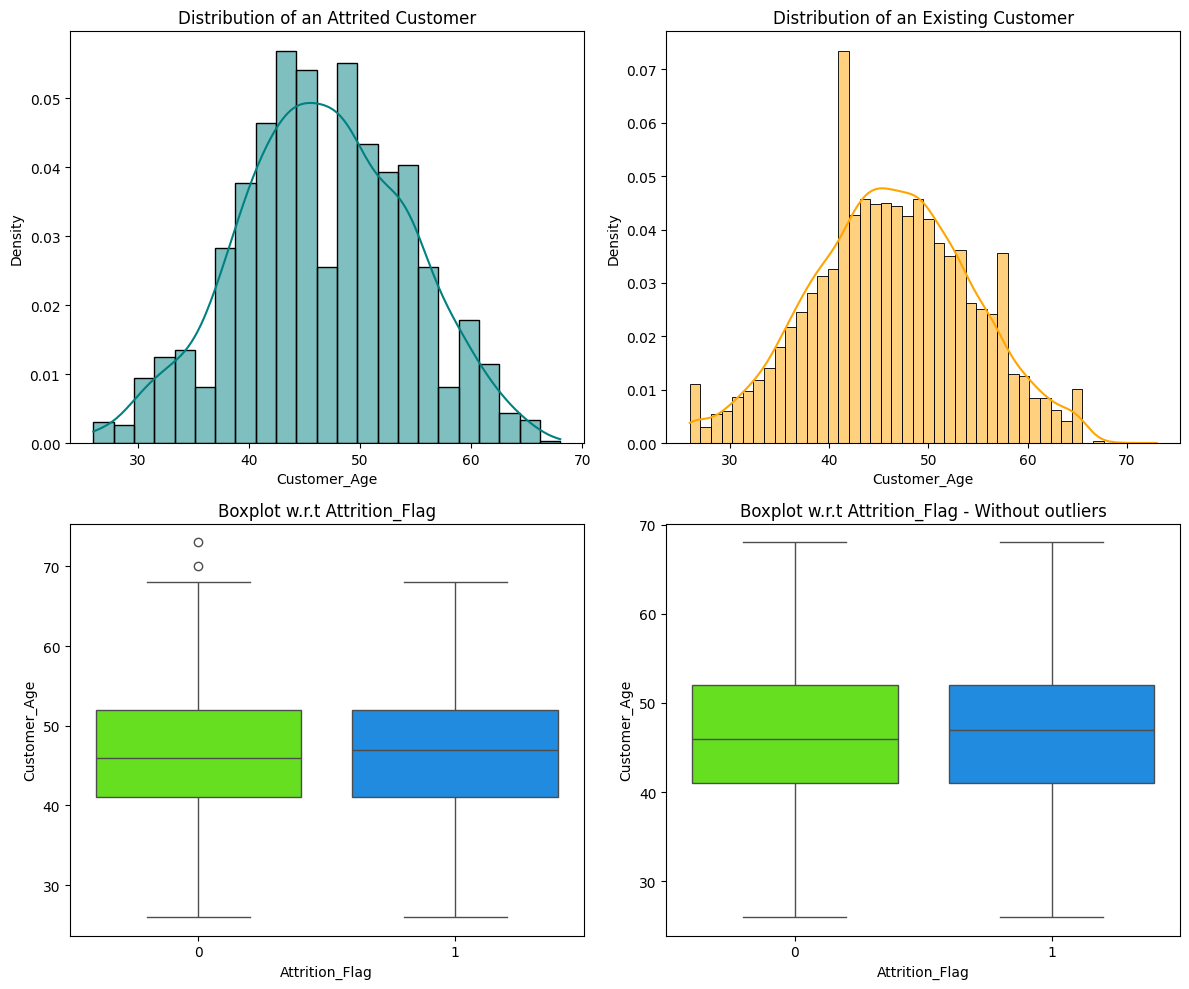

In [74]:
plot('Customer_Age')

* There's no difference in the age of customers who attrited and who didn't.

### Attrition_Flag vs Months_on_book

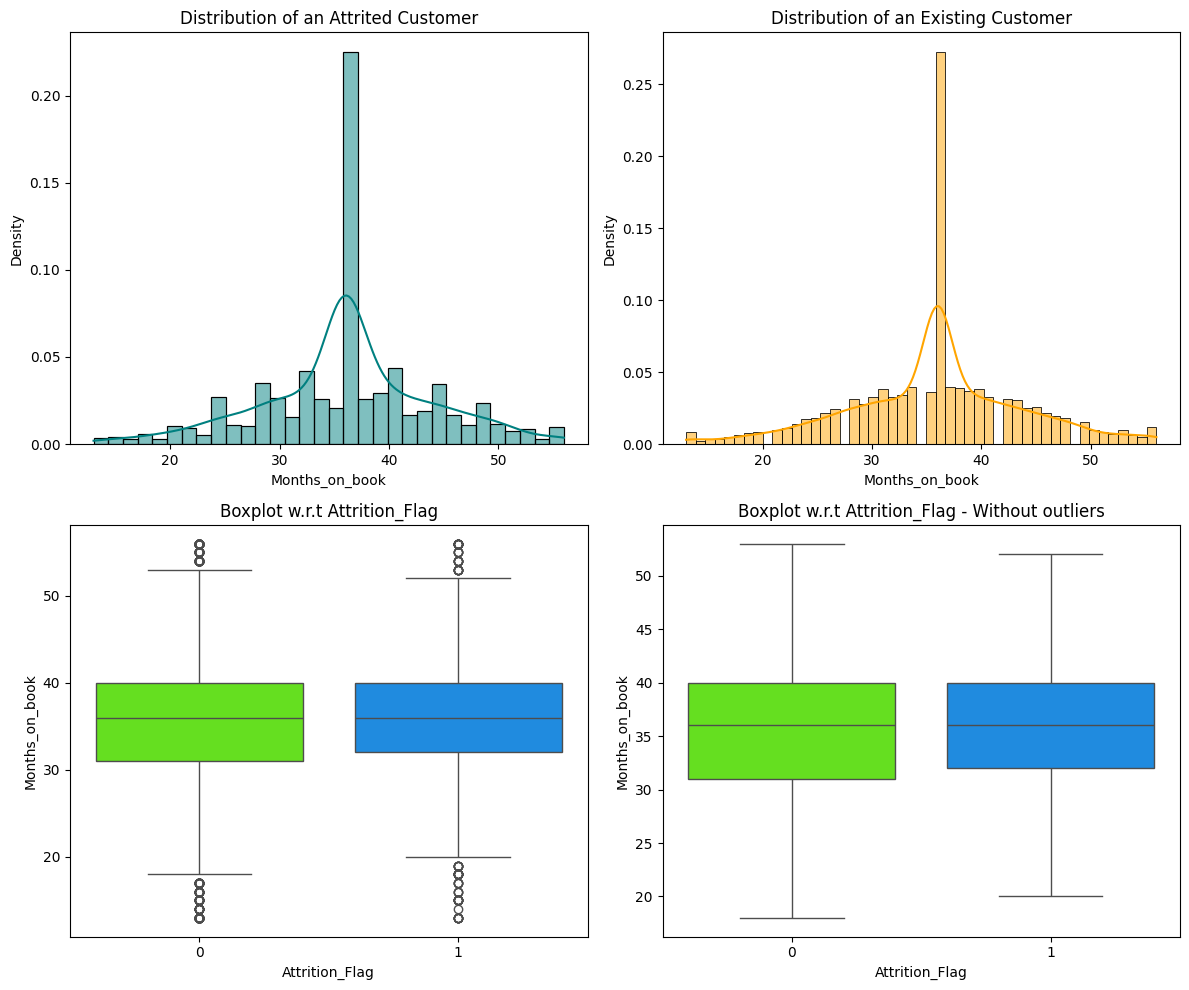

In [75]:
plot('Months_on_book')

* Tenure of relationship with the bank doesn't seem to have an impact on attrition.

### Attrition_Flag vs Credit_Limit

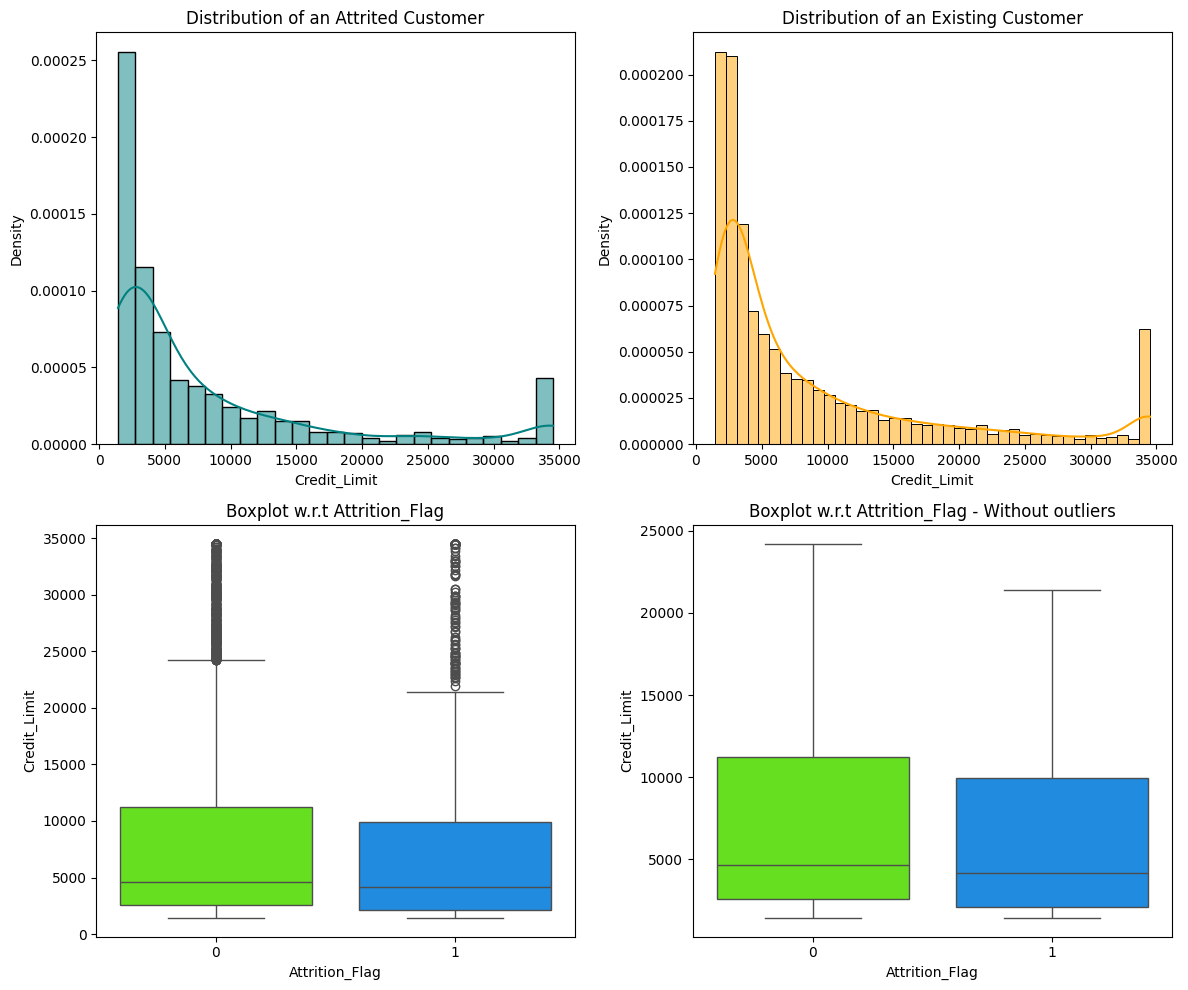

In [76]:
plot('Credit_Limit')

* Customers with lower credit limits are the ones who attrited.

### Attrition_Flag vs Total_Revolving_Bal

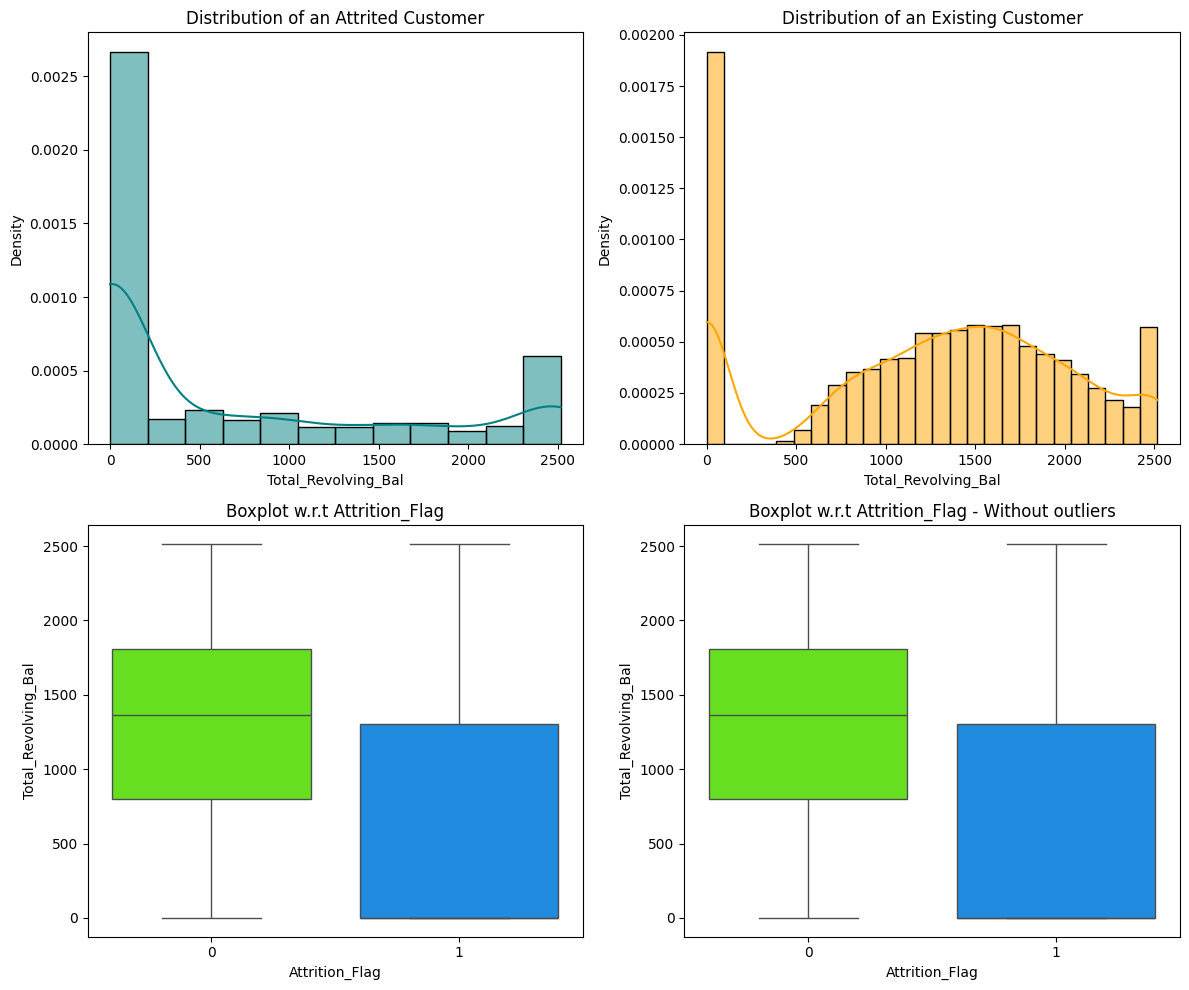

In [77]:
plot('Total_Revolving_Bal')

* Customers with less total revolving balance are the ones who attrited, such customers must have cleared their dues and opted out of the credit card service.

### Attrition_Flag vs Avg_Open_To_Buy

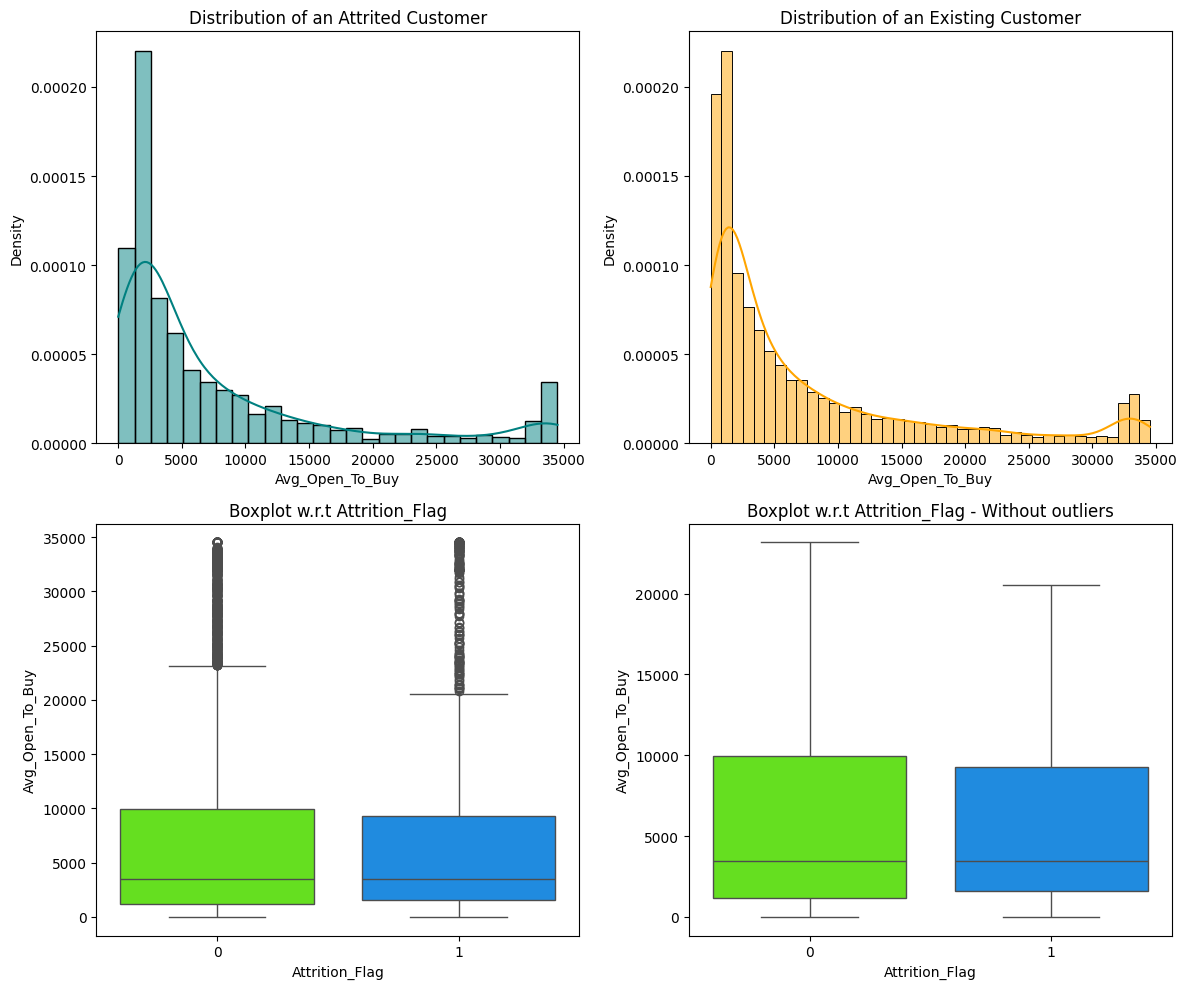

In [78]:
plot('Avg_Open_To_Buy')

* There's not much difference in the distribution for an attrited and existing customer.

### Attrition_Flag vs Total_Trans_Ct

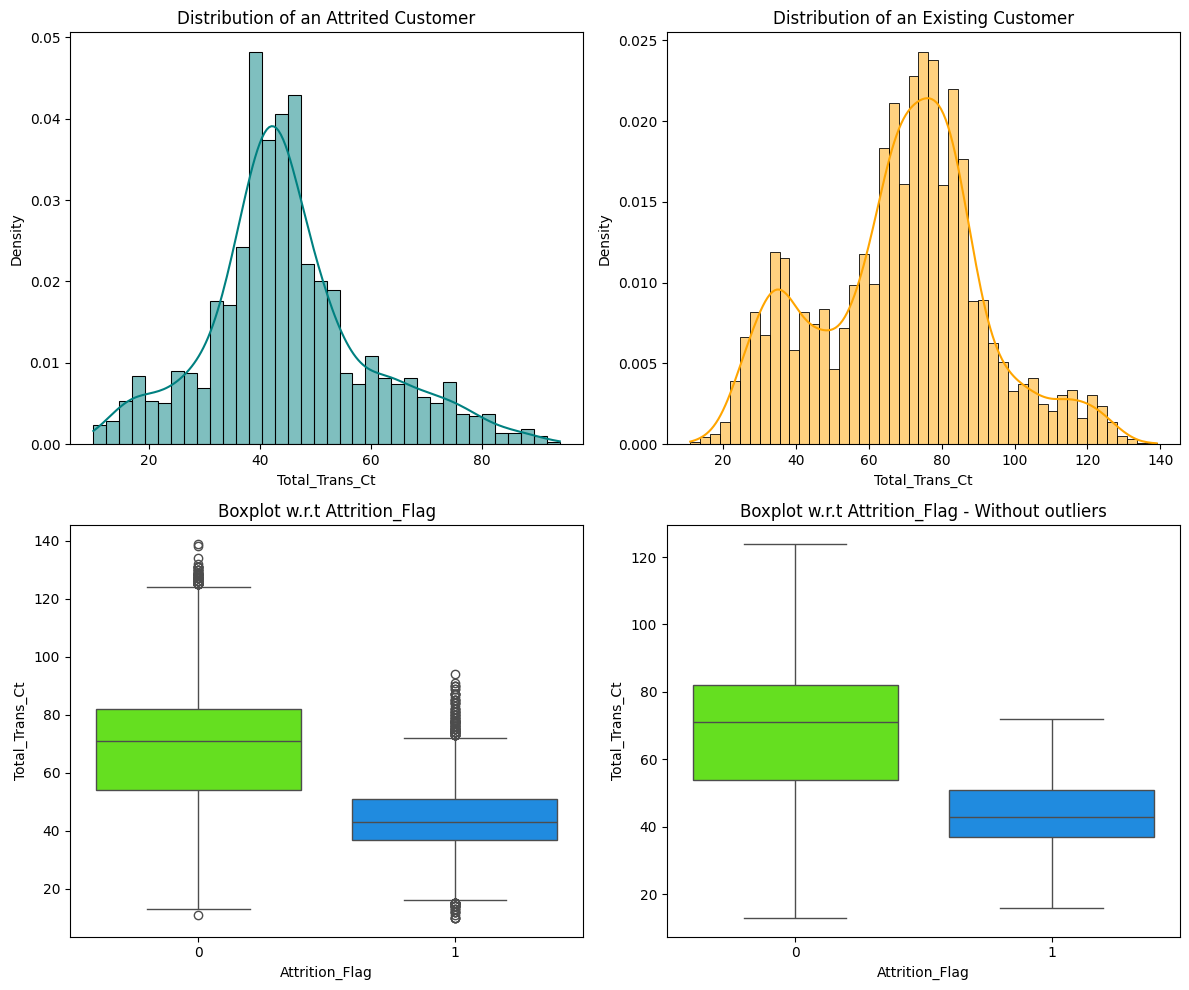

In [79]:
plot('Total_Trans_Ct')

* Less number of transactions lead to higher attrition.
* Customers with less than 80 to 100 transactions (or median transactions equal to 40) in a year should be more focussed upon.

### Attrition_Flag vs Total_Trans_Amt

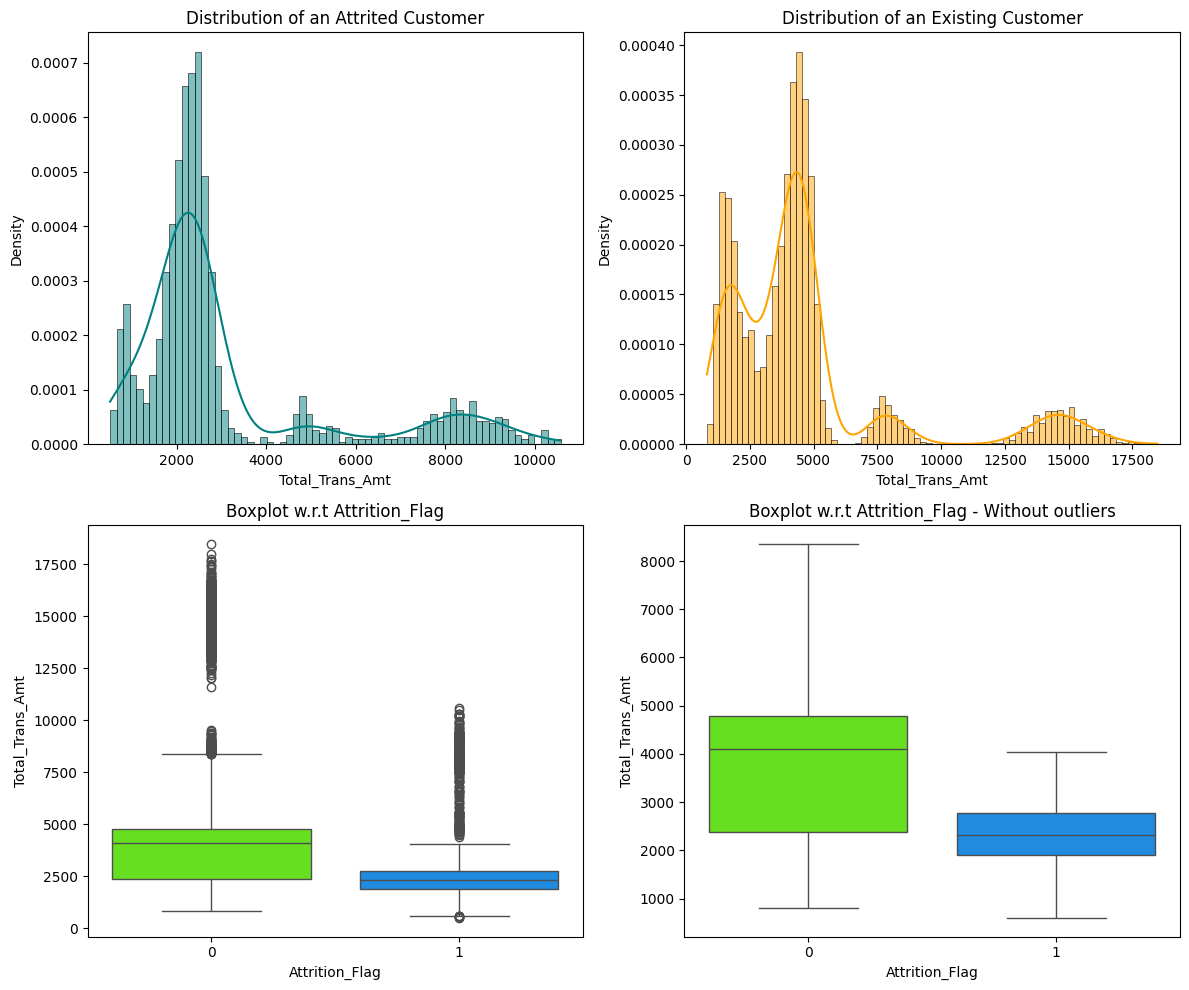

In [80]:
plot('Total_Trans_Amt')

* Less number of transactions might lead to a less transaction amount and eventually leading to customer attrition.

### Attrition_Flag vs Total_Amt_Chng_Q4_Q1

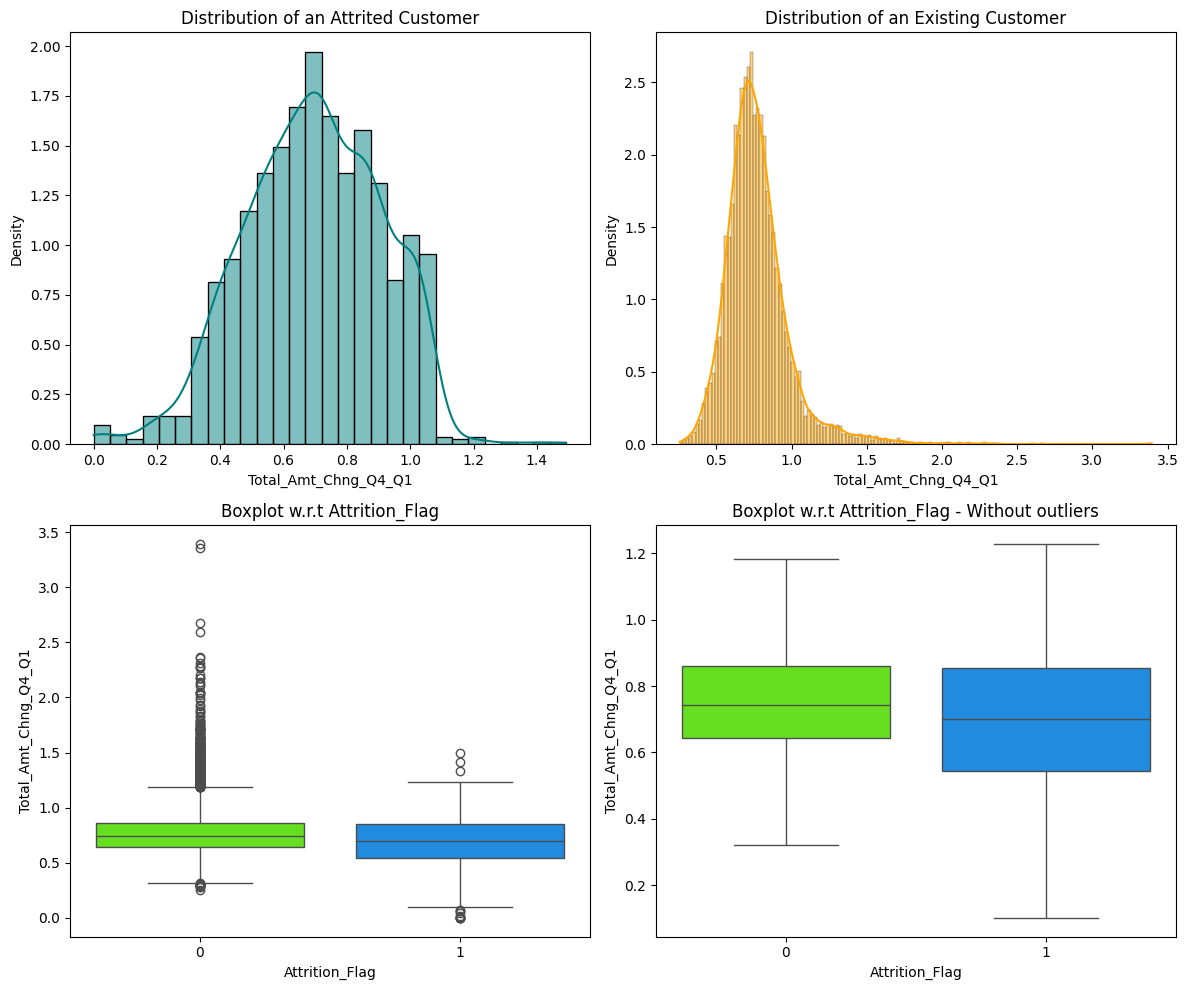

In [81]:
plot('Total_Amt_Chng_Q4_Q1')

* Customers who didn't attrite showed less variability across Q4 to Q1 as compared to the ones who attrited.

### Attrition_Flag vs Total_Ct_Chng_Q4_Q1

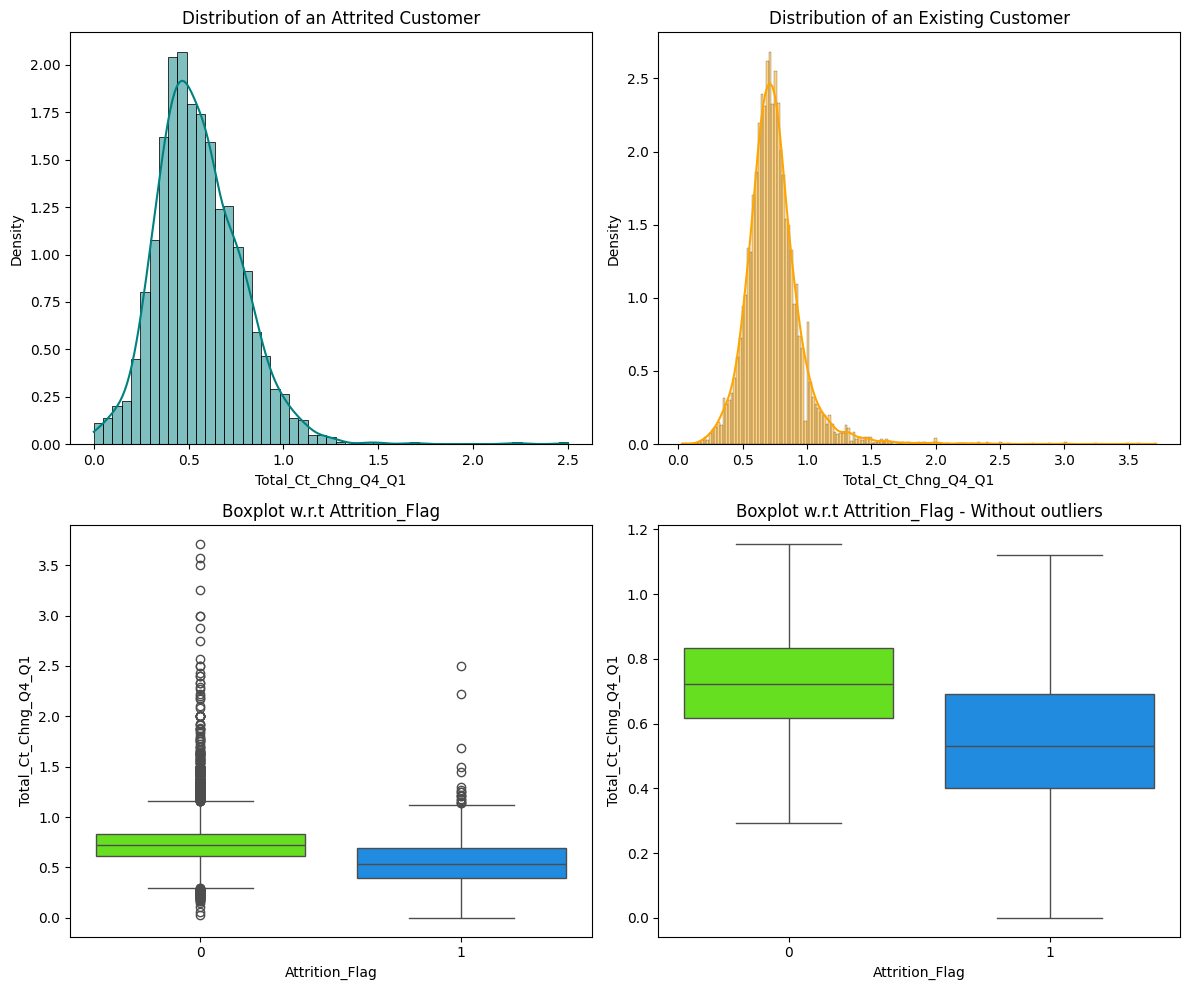

In [82]:
plot('Total_Ct_Chng_Q4_Q1')

* Customers who didn't attrite showed less variability across Q4 to Q1 as compared to the ones who attrited.

### Attrition_Flag vs Avg_Utilization_Ratio

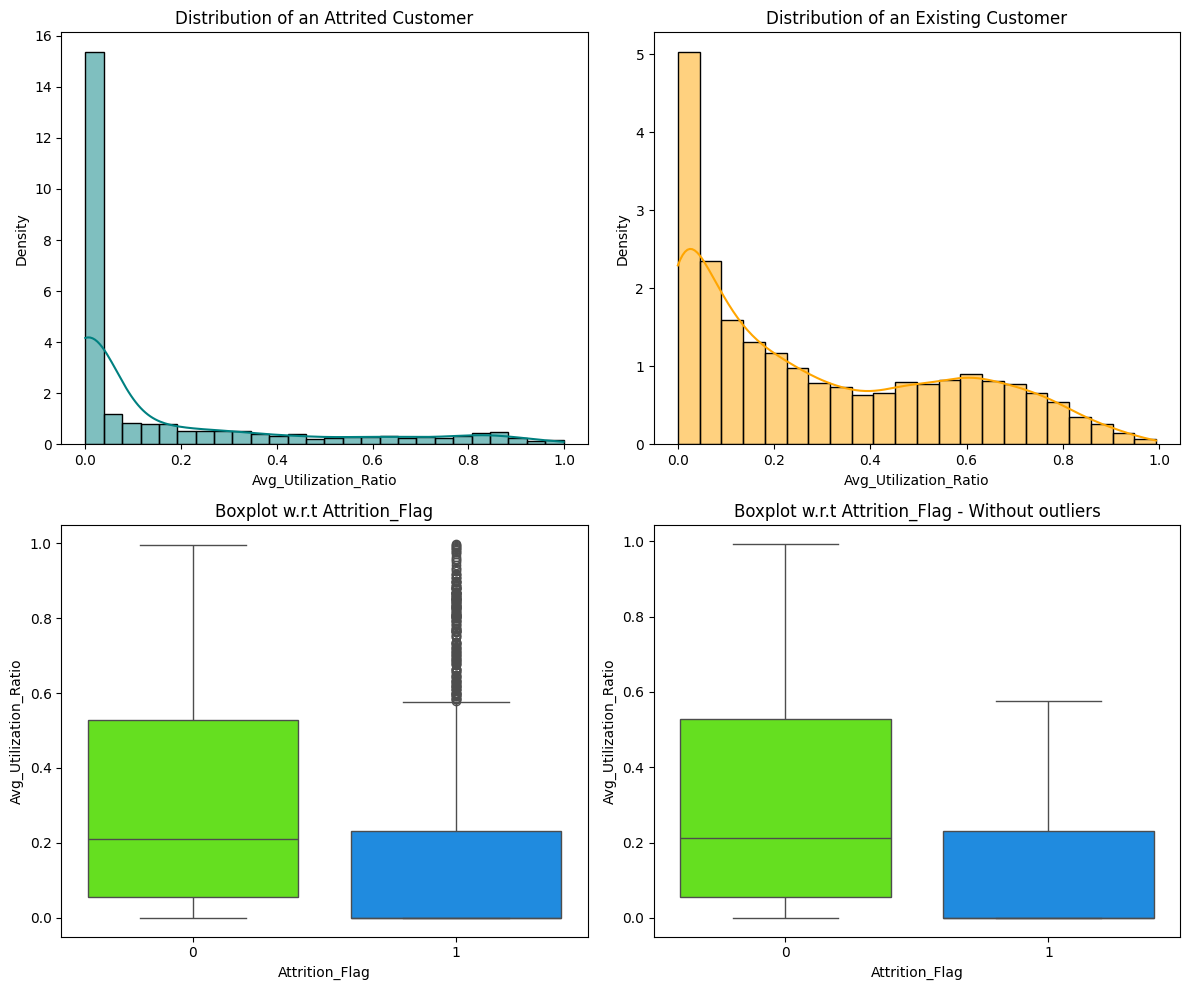

In [83]:
plot('Avg_Utilization_Ratio')

* Customers utilizing their full credit limit are the ones who didn't attrite.
* Less utilization of the available credits indicates inactivity of customers.

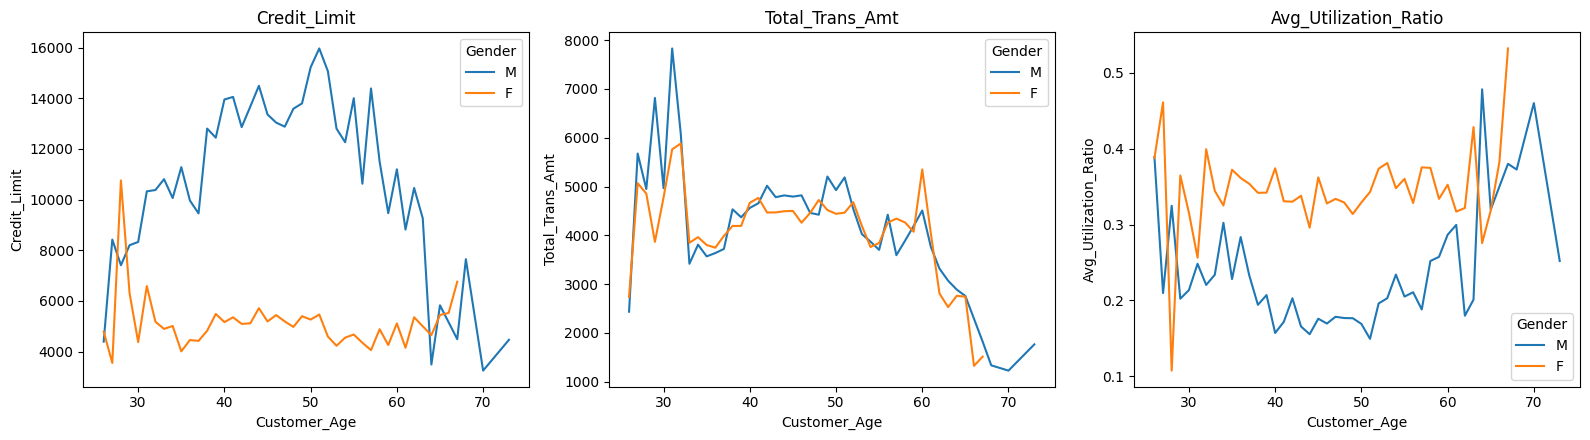

In [85]:
cols = ['Credit_Limit', 'Total_Trans_Amt', 'Avg_Utilization_Ratio']
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))          # one row, three charts
for ax, variable in zip(axes, cols):
    sns.lineplot(data=data, x='Customer_Age', y=variable, hue='Gender', errorbar=None, ax=ax)
    ax.set_title(variable)
plt.tight_layout()
plt.show()

* With age the credit limit of male customers increased (till 50 years) but for the female customers the credit limit constant throughout.
* Although the credit limit for female customers is less the total transactions made by them for all age groups is the same.
* Female customers utilized their credits more as compared to the male customers where utilization dropped from 30-50 years but increased after 60 years.

### Let's find the percentage of outliers, in each column of the data, using IQR.

In [87]:
num = data.select_dtypes(include='number').drop(columns=['Attrition_Flag'])   # numeric features only

Q1 = num.quantile(0.25)                 # 25th percentile
Q3 = num.quantile(0.75)                 # 75th percentile
IQR = Q3 - Q1                           # Inter-Quartile Range

lower = Q1 - 1.5 * IQR                  # values outside [lower, upper] are outliers
upper = Q3 + 1.5 * IQR

In [89]:
# % of values outside the IQR bounds, per numeric feature
outlier_pct = ((num < lower) | (num > upper)).mean() * 100
outlier_pct.sort_values(ascending=False).round(2)

,0
Credit_Limit,9.720
Avg_Open_To_Buy,9.510
Total_Trans_Amt,8.850
Contacts_Count_12_mon,6.210
Total_Amt_Chng_Q4_Q1,3.910
Total_Ct_Chng_Q4_Q1,3.890
Months_on_book,3.810
Months_Inactive_12_mon,3.270
Customer_Age,0.020
Total_Trans_Ct,0.020


* After identifying outliers, we can decide whether to remove/treat them or not. It depends on one's approach, here I'm not going to treat them as there will be outliers in real case scenario (in age, the total amount of transactions, number of transactions, etc) and I want our model to learn the underlying pattern for such customers.

### Data Preparation

In [90]:
data1=data.copy()

In [91]:
# Label-encode categoricals for KNN imputation. 'Unknown' is left out of each map,
# so it becomes NaN and gets filled by the KNN imputer.
gender          = {'M': 0, 'F': 1}
education_level = {'Uneducated': 0, 'High School': 1, 'College': 2, 'Graduate': 3, 'Post-Graduate': 4, 'Doctorate': 5}
marital_status  = {'Married': 0, 'Single': 1, 'Divorced': 2}
income_category = {'Less than $40K': 0, '$40K - $60K': 1, '$60K - $80K': 2, '$80K - $120K': 3, '$120K +': 4}
card_category   = {'Blue': 0, 'Silver': 1, 'Gold': 2, 'Platinum': 3}

for col, mapping in [('Gender', gender), ('Education_Level', education_level), ('Marital_Status', marital_status),
                     ('Income_Category', income_category), ('Card_Category', card_category)]:
    data1[col] = data1[col].map(mapping).astype('Int32')

data1[['Education_Level', 'Marital_Status', 'Income_Category']].isna().sum()

,0
Education_Level,1519
Marital_Status,749
Income_Category,1112


In [92]:
data1.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,0,45,0,3,1,0,2,0,39,5,1,3,12691.000,777,11914.000,1.335,1144,42,1.625,0.061
1,0,49,1,5,3,1,0,0,44,6,1,2,8256.000,864,7392.000,1.541,1291,33,3.714,0.105
2,0,51,0,3,3,0,3,0,36,4,1,0,3418.000,0,3418.000,2.594,1887,20,2.333,0.000
3,0,40,1,4,1,<NA>,0,0,34,3,4,1,3313.000,2517,796.000,1.405,1171,20,2.333,0.760
4,0,40,0,3,0,0,2,0,21,5,1,0,4716.000,0,4716.000,2.175,816,28,2.500,0.000


* Values have been encoded.

In [93]:
data1.isnull().sum()

,0
Attrition_Flag,0
Customer_Age,0
Gender,0
Dependent_count,0
Education_Level,1519
Marital_Status,749
Income_Category,1112
Card_Category,0
Months_on_book,0
Total_Relationship_Count,0


### Missing-Value Treatment

* I'm using KNN imputer to impute missing values.
* `KNNImputer`: Each sample's missing values are imputed by looking at the n_neighbors nearest neighbors found in the training set. Default value for n_neighbors=5.
* KNN imputer replaces missing values using the average of k nearest non-missing feature values.
* Nearest points are found based on euclidean distance.

In [94]:
imputer = KNNImputer(n_neighbors=5)

In [95]:
X = data1.drop(['Attrition_Flag'],axis=1)
y = data1['Attrition_Flag']

In [96]:
# Splitting data into training and test set:
# For a change I made test_size = 30% where in Kaggle test split is 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=7,stratify=y)
print(X_train.shape, X_test.shape)

(7088, 19) (3039, 19)


In [97]:
#Fit and transform the train data
X_train=pd.DataFrame(imputer.fit_transform(X_train),columns=X_train.columns)

#Transform the test data
X_test=pd.DataFrame(imputer.transform(X_test),columns=X_test.columns)

In [98]:
#Checking that no column has missing values in train or test sets
print(X_train.isna().sum())
print('-'*30)
print(X_test.isna().sum())

Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64
------------------------------
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal       

* All missing values have been treated.
* Let's inverse map the encoded values.

In [99]:
## Function to inverse the encoding
def inverse_mapping(x,y):
    inv_dict = {v: k for k, v in x.items()}
    X_train[y] = np.round(X_train[y]).map(inv_dict).astype('category')
    X_test[y] = np.round(X_test[y]).map(inv_dict).astype('category')

In [100]:
inverse_mapping(gender,'Gender')
inverse_mapping(education_level,'Education_Level')
inverse_mapping(marital_status,'Marital_Status')
inverse_mapping(income_category,'Income_Category')
inverse_mapping(card_category,'Card_Category')

* Checking inverse mapped values/categories.

In [101]:
cols = X_train.select_dtypes(include=['object','category'])
for i in cols.columns:
    print(X_train[i].value_counts())
    print('*'*30)

Gender
F    3753
M    3335
Name: count, dtype: int64
******************************
Education_Level
Graduate         2509
High School      1548
College          1307
Uneducated       1040
Post-Graduate     362
Doctorate         322
Name: count, dtype: int64
******************************
Marital_Status
Married     3443
Single      3107
Divorced     538
Name: count, dtype: int64
******************************
Income_Category
Less than $40K    2620
$40K - $60K       1508
$80K - $120K      1250
$60K - $80K       1190
$120K +            520
Name: count, dtype: int64
******************************
Card_Category
Blue        6619
Silver       373
Gold          81
Platinum      15
Name: count, dtype: int64
******************************


In [102]:
cols = X_test.select_dtypes(include=['object','category'])
for i in cols.columns:
    print(X_train[i].value_counts())
    print('*'*30)

Gender
F    3753
M    3335
Name: count, dtype: int64
******************************
Education_Level
Graduate         2509
High School      1548
College          1307
Uneducated       1040
Post-Graduate     362
Doctorate         322
Name: count, dtype: int64
******************************
Marital_Status
Married     3443
Single      3107
Divorced     538
Name: count, dtype: int64
******************************
Income_Category
Less than $40K    2620
$40K - $60K       1508
$80K - $120K      1250
$60K - $80K       1190
$120K +            520
Name: count, dtype: int64
******************************
Card_Category
Blue        6619
Silver       373
Gold          81
Platinum      15
Name: count, dtype: int64
******************************


* Inverse mapping returned original labels.

### Encoding categorical varaibles

In [103]:
X_train=pd.get_dummies(X_train,drop_first=True)
X_test=pd.get_dummies(X_test,drop_first=True)
print(X_train.shape, X_test.shape)

(7088, 29) (3039, 29)


* After encoding there are 30 columns.

## Building the model

## Model evaluation criterion

### Model can make wrong predictions as:
1. Predicting a customer will attrite and the customer doesn't attrite
2. Predicting a customer will not attrite and the customer attrites

### Which case is more important?
* Predicting that customer will not attrite but he attrites i.e. losing on a valuable customer or asset.

### How to reduce this loss i.e need to reduce False Negatives?
* Bank would want `Recall` to be maximized, greater the Recall higher the chances of minimizing false negatives. Hence, the focus should be on increasing Recall or minimizing the false negatives or in other words identifying the true positives(i.e. Class 1) so that the bank can retain their valuable customers by identifying the customers who are at risk of attrition.

**let me create two functions to calculate different metrics and confusion matrix, so that we don't have to use the same code repeatedly for each model.**

In [104]:
def get_metrics_score(model,train,test,train_y,test_y,flag=True):
    '''
    model : classifier to predict values of X

    '''
    # defining an empty list to store train and test results
    score_list=[]

    pred_train = model.predict(train)
    pred_test = model.predict(test)

    train_acc = model.score(train,train_y)
    test_acc = model.score(test,test_y)

    train_recall = metrics.recall_score(train_y,pred_train)
    test_recall = metrics.recall_score(test_y,pred_test)

    train_precision = metrics.precision_score(train_y,pred_train)
    test_precision = metrics.precision_score(test_y,pred_test)

    score_list.extend((train_acc,test_acc,train_recall,test_recall,train_precision,test_precision))

    # If the flag is set to True then only the following print statements will be dispayed. The default value is set to True.
    if flag == True:
        print("Accuracy on training set : ",model.score(train,train_y))
        print("Accuracy on test set : ",model.score(test,test_y))
        print("Recall on training set : ",metrics.recall_score(train_y,pred_train))
        print("Recall on test set : ",metrics.recall_score(test_y,pred_test))
        print("Precision on training set : ",metrics.precision_score(train_y,pred_train))
        print("Precision on test set : ",metrics.precision_score(test_y,pred_test))

    return score_list # returning the list with train and test scores

In [105]:
def make_confusion_matrix(model,y_actual,labels=[1, 0]):
    '''
    model : classifier to predict values of X
    y_actual : ground truth

    '''
    y_predict = model.predict(X_test)
    cm=metrics.confusion_matrix( y_actual, y_predict, labels=[0, 1])
    df_cm = pd.DataFrame(cm, index = [i for i in ["Actual - No","Actual - Yes"]],
                  columns = [i for i in ['Predicted - No','Predicted - Yes']])
    group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in
                         cm.flatten()/np.sum(cm)]
    labels = [f"{v1}\n{v2}" for v1, v2 in
              zip(group_counts,group_percentages)]
    labels = np.asarray(labels).reshape(2,2)
    plt.figure(figsize = (10,7))
    sns.heatmap(df_cm, annot=labels,fmt='')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

### Logistic Regression

In [106]:
lr = LogisticRegression(random_state=1)
lr.fit(X_train,y_train)

LogisticRegression(random_state=1)

**Let's evaluate the model performance by using KFold and cross_val_score**

- `K-Folds cross-validator` provides dataset indices to split data into train/validation sets. Split dataset into k consecutive stratified folds (without shuffling by default). Each fold is then used once as validation while the k - 1 remaining folds form the training set.

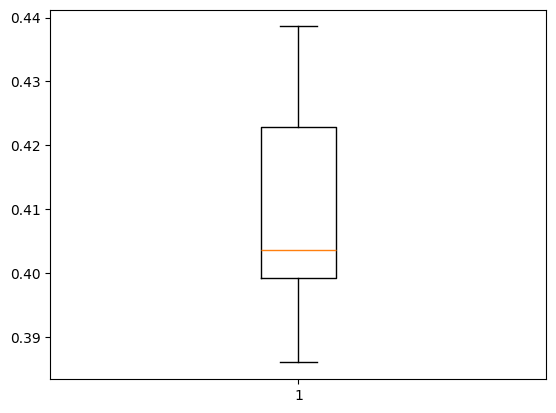

In [107]:
scoring='recall'
kfold=StratifiedKFold(n_splits=5,shuffle=True,random_state=1)     #Setting number of splits equal to 5
cv_result_bfr=cross_val_score(estimator=lr, X=X_train, y=y_train, scoring=scoring, cv=kfold)
#Plotting boxplots for CV scores of model defined above
plt.boxplot(cv_result_bfr)
plt.show()

* Performance on training set varies between 0.38 to 0.50 recall.
* Let's check the performance on test data.

Accuracy on training set :  0.8776805869074492
Accuracy on test set :  0.8818690358670616
Recall on training set :  0.42493415276558383
Recall on test set :  0.4262295081967213
Precision on training set :  0.6954022988505747
Precision on test set :  0.7247386759581882


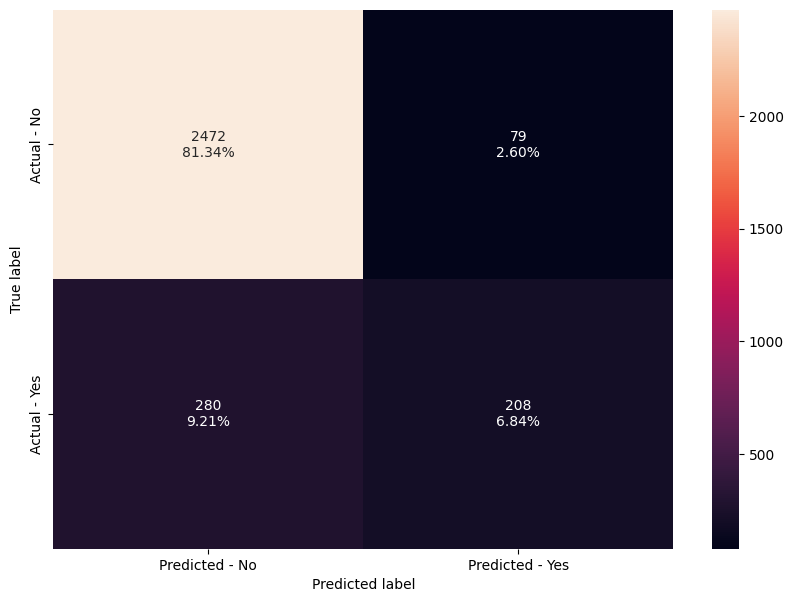

In [108]:
#Calculating different metrics
scores_LR = get_metrics_score(lr,X_train,X_test,y_train,y_test)

# creating confusion matrix
make_confusion_matrix(lr,y_test)

Accuracy on training set :  0.8776805869074492
Accuracy on test set :  0.8818690358670616
Recall on training set :  0.42493415276558383
Recall on test set :  0.4262295081967213
Precision on training set :  0.6954022988505747
Precision on test set :  0.7247386759581882


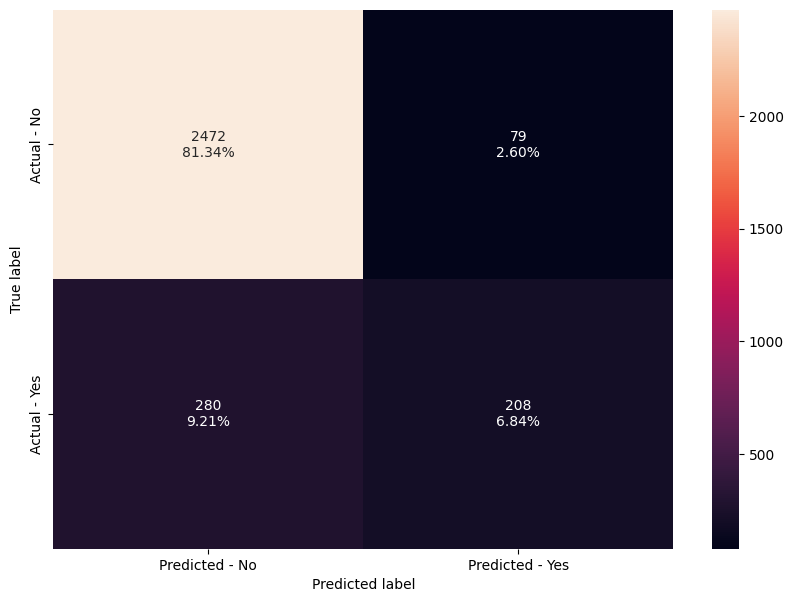

In [109]:
#Calculating different metrics
scores_LR = get_metrics_score(lr,X_train,X_test,y_train,y_test)

# creating confusion matrix
make_confusion_matrix(lr,y_test)

* Logistic Regression has given a generalized performance on training and test set.
* Recall is very low, we can try oversampling (increase training data) to see if the model performance can be improved.

### Oversampling train data using SMOTE

In [110]:
from imblearn.over_sampling import SMOTE

In [111]:
print("Before UpSampling, counts of label 'Yes': {}".format(sum(y_train==1)))
print("Before UpSampling, counts of label 'No': {} \n".format(sum(y_train==0)))

sm = SMOTE(sampling_strategy = 1 ,k_neighbors = 5, random_state=1)   #Synthetic Minority Over Sampling Technique
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After UpSampling, counts of label 'Yes': {}".format(sum(y_train_over==1)))
print("After UpSampling, counts of label 'No': {} \n".format(sum(y_train_over==0)))


print('After UpSampling, the shape of train_X: {}'.format(X_train_over.shape))
print('After UpSampling, the shape of train_y: {} \n'.format(y_train_over.shape))

Before UpSampling, counts of label 'Yes': 1139
Before UpSampling, counts of label 'No': 5949 

After UpSampling, counts of label 'Yes': 5949
After UpSampling, counts of label 'No': 5949 

After UpSampling, the shape of train_X: (11898, 29)
After UpSampling, the shape of train_y: (11898,) 



### Logistic Regression on oversampled data

In [112]:
log_reg_over = LogisticRegression(random_state = 1)

# Training the basic logistic regression model with training set
log_reg_over.fit(X_train_over,y_train_over)

LogisticRegression(random_state=1)

**Let's evaluate the model performance by using KFold and cross_val_score**

- `K-Folds cross-validator` provides dataset indices to split data into train/validation sets. Split dataset into k consecutive stratified folds (without shuffling by default). Each fold is then used once as validation while the k - 1 remaining folds form the training set.

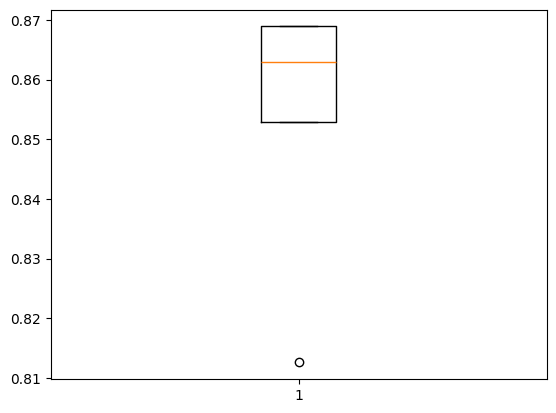

In [113]:
scoring='recall'
kfold=StratifiedKFold(n_splits=5,shuffle=True,random_state=1)     #Setting number of splits equal to 5
cv_result_over=cross_val_score(estimator=log_reg_over, X=X_train_over, y=y_train_over, scoring=scoring, cv=kfold)
#Plotting boxplots for CV scores of model defined above
plt.boxplot(cv_result_over)
plt.show()

* Performance of model on training set varies between 0.85 to 0.87, which is an improvement from the previous model
* The variability in the model performance has also decreased.
* Let's check the performance on the test set.

Accuracy on training set :  0.8297192805513531
Accuracy on test set :  0.8121092464626521
Recall on training set :  0.8429988233316523
Recall on test set :  0.7889344262295082
Precision on training set :  0.8211887997380055
Precision on test set :  0.451348182883939


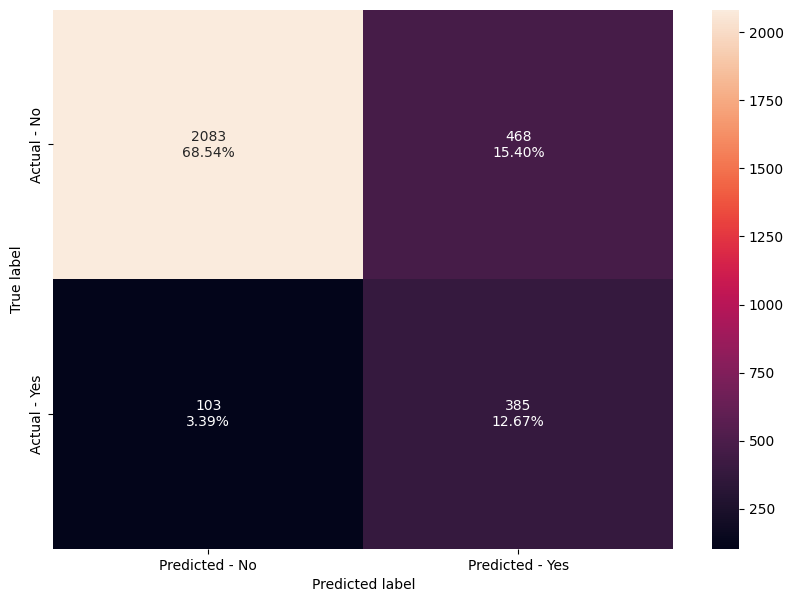

In [114]:
#Calculating different metrics
get_metrics_score(log_reg_over,X_train_over,X_test,y_train_over,y_test)

# creating confusion matrix
make_confusion_matrix(log_reg_over,y_test)

* Performance of the model increased
* Lets try:

  a) Regularization to see if overfitting in precision can be reduced

  b) Undersampling the train to handle the imbalance between classes and check the model performance.

### Regularization

In [115]:
# Choose the type of classifier.
lr_estimator = LogisticRegression(random_state=1,solver='saga')

# Grid of parameters to choose from
parameters = {'C': np.arange(0.1,1.1,0.1)}

# Run the grid search
grid_obj = GridSearchCV(lr_estimator, parameters, scoring='recall')
grid_obj = grid_obj.fit(X_train_over, y_train_over)

# Set the clf to the best combination of parameters
lr_estimator = grid_obj.best_estimator_

# Fit the best algorithm to the data.
lr_estimator.fit(X_train_over, y_train_over)

LogisticRegression(C=np.float64(0.1), random_state=1, solver='saga')

Accuracy on training set :  0.7065052950075643
Accuracy on test set :  0.8042119118130964
Recall on training set :  0.5738779626828038
Recall on test set :  0.5532786885245902
Precision on training set :  0.7810569663692519
Precision on test set :  0.41731066460587324


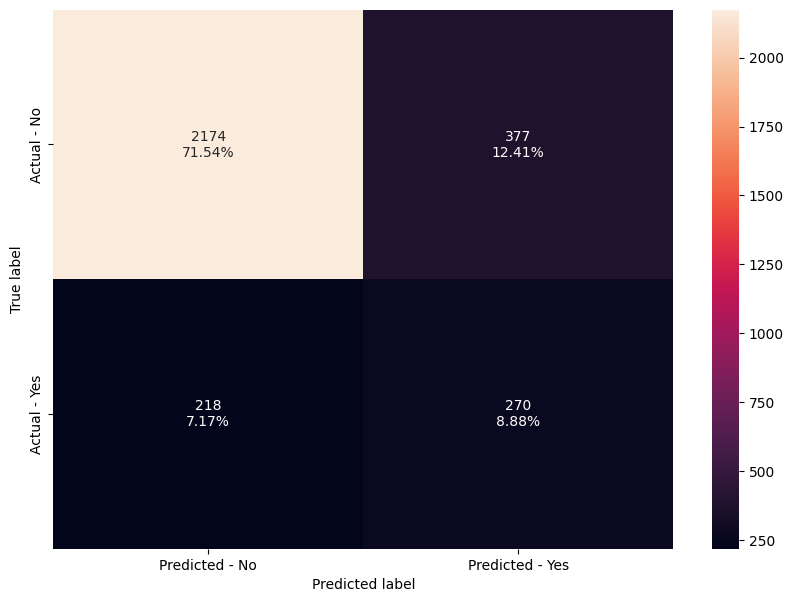

In [116]:
#Calculating different metrics
get_metrics_score(lr_estimator,X_train_over,X_test,y_train_over,y_test)

# creating confusion matrix
make_confusion_matrix(lr_estimator,y_test)

* After regularization, the recall has also reduced.
* Let's try undersampling now.

### Undersampling train data using SMOTE

In [117]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state = 1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

In [118]:
print("Before Under Sampling, counts of label 'Yes': {}".format(sum(y_train==1)))
print("Before Under Sampling, counts of label 'No': {} \n".format(sum(y_train==0)))

print("After Under Sampling, counts of label 'Yes': {}".format(sum(y_train_un==1)))
print("After Under Sampling, counts of label 'No': {} \n".format(sum(y_train_un==0)))

print('After Under Sampling, the shape of train_X: {}'.format(X_train_un.shape))
print('After Under Sampling, the shape of train_y: {} \n'.format(y_train_un.shape))

Before Under Sampling, counts of label 'Yes': 1139
Before Under Sampling, counts of label 'No': 5949 

After Under Sampling, counts of label 'Yes': 1139
After Under Sampling, counts of label 'No': 1139 

After Under Sampling, the shape of train_X: (2278, 29)
After Under Sampling, the shape of train_y: (2278,) 



### Logistic Regression on undersampled data

In [119]:
log_reg_under = LogisticRegression(random_state = 1)
log_reg_under.fit(X_train_un,y_train_un )

LogisticRegression(random_state=1)

**Let's evaluate the model performance by using KFold and cross_val_score**

- `K-Folds cross-validator` provides dataset indices to split data into train/validation sets. Split dataset into k consecutive stratified folds (without shuffling by default). Each fold is then used once as validation while the k - 1 remaining folds form the training set.

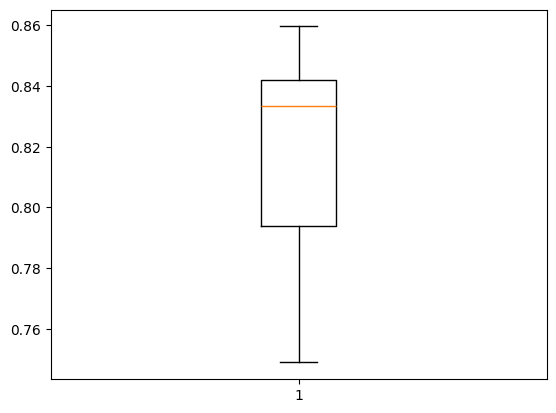

In [120]:
scoring='recall'
kfold=StratifiedKFold(n_splits=5,shuffle=True,random_state=1)     #Setting number of splits equal to 5
cv_result_under=cross_val_score(estimator=log_reg_under, X=X_train_un, y=y_train_un, scoring=scoring, cv=kfold)
#Plotting boxplots for CV scores of model defined above
plt.boxplot(cv_result_under)
plt.show()

* Performance of model on training set varies between 0.76 to 0.86, which is an improvement from the initial model(without oversampling)
* The variability in results is quite large as compared to the oversampled model.
* Let's check the performance on the test set.

Accuracy on training set :  0.8169446883230904
Accuracy on test set :  0.8167160250082264
Recall on training set :  0.820017559262511
Recall on test set :  0.8012295081967213
Precision on training set :  0.8150087260034904
Precision on test set :  0.4594594594594595


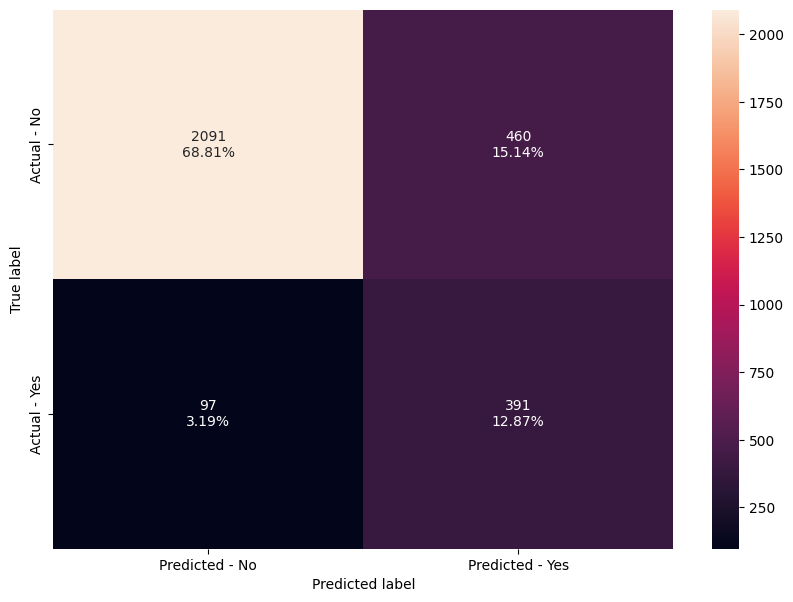

In [121]:
#Calculating different metrics
get_metrics_score(log_reg_under,X_train_un,X_test,y_train_un,y_test)


# creating confusion matrix
make_confusion_matrix(log_reg_under,y_test)

* Model has given a generalized performance on training and test set.
* Model performance has improved using downsampling - Logistic regression is now able to differentiate well between positive and negative classes.

**We will proceed with the original data (data before over or under sampling) as Logistic Regression model gave a generalized performance on it.**

### Bagging and Boosting

**Let's start by building different models using KFold and cross_val_score with pipelines and tune the best model using GridSearchCV and RandomizedSearchCV**

- `Stratified K-Folds cross-validator` provides dataset indices to split data in train/validation sets. Split dataset into k consecutive folds (without shuffling by default) keeping distribution of both classes in each fold same as the target variable. Each fold is then used once as a validation while the k - 1 remaining folds form the training set.

In [122]:
models = []  # Empty list to store all the models

# Appending pipelines for each model into the list

models.append(
    (
        "DTREE",
        Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("decision_tree", DecisionTreeClassifier(random_state=1,)),
            ]
        ),
    )
)


models.append(
    (
        "Bagging",
        Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("random_forest", BaggingClassifier(random_state=1)),
            ]
        ),
    )
)


models.append(
    (
        "RF",
        Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("random_forest", RandomForestClassifier(random_state=1)),
            ]
        ),
    )
)

models.append(
    (
        "ADB",
        Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("adaboost", AdaBoostClassifier(random_state=1)),
            ]
        ),
    )
)


models.append(
    (
        "GBM",
        Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("gradient_boosting", GradientBoostingClassifier(random_state=1)),
            ]
        ),
    )
)


models.append(
    (
        "XGB",
        Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("xgboost", XGBClassifier(random_state=1,eval_metric='logloss')),
            ]
        ),
    )
)

results = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models

# loop through all models to get the mean cross validated score
for name, model in models:
    scoring = "recall"
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5
    cv_result = cross_val_score(
        estimator=model, X=X_train, y=y_train, scoring=scoring, cv=kfold
    )
    results.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean() * 100))

DTREE: 80.24808717829816
Bagging: 81.21338588762654
RF: 78.13741401963057
ADB: 75.85362083623156
GBM: 85.60051008578716
XGB: 88.67493623927662


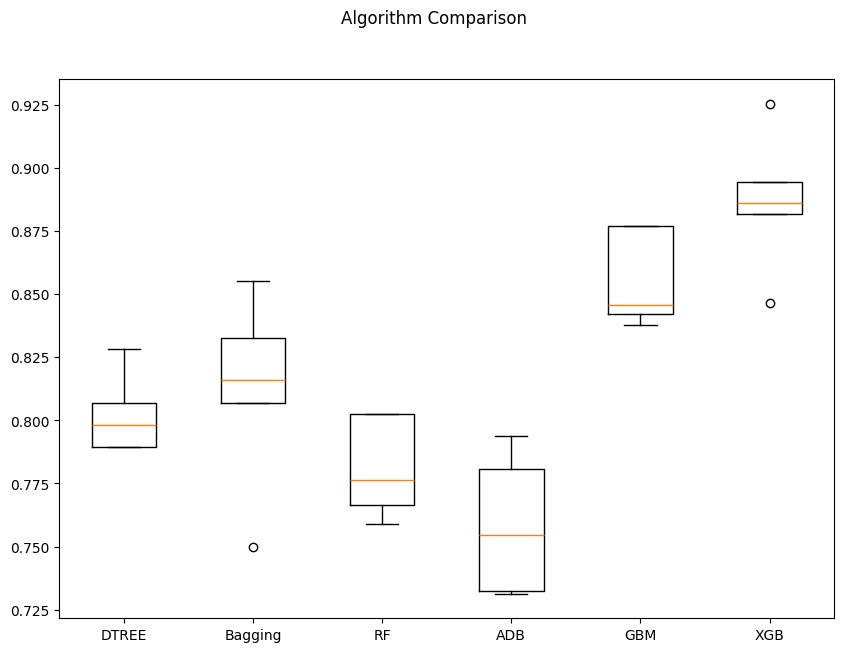

In [123]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(10, 7))

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results)
ax.set_xticklabels(names)

plt.show()

- We can see that XGBoost is giving the highest cross validated recall followed by GradientBoost.
- The boxplot shows that the performance of XGBoost and GBM is consistent.
- The boxplot shows that the performance of AdaBoost is also consistent (with one outlier).
- Let's tune the models see if the performance improves.

## Hyperparameter Tuning

* We will use pipelines with StandardScaler with bagging and boosting models and tune them using GridSearchCV and RandomizedSearchCV. We will also compare the performance and time taken by these two methods - grid search and randomized search.

* We can also use make_pipeline function instead of Pipeline to create a pipeline.

* `make_pipeline`: This is a shorthand for the Pipeline constructor; it does not require, and does not permit, naming the estimators. Instead, their names will be set to the lowercase of their types automatically.

### Hyperparameter tuning Decision Tree

#### GridSearchCV

In [124]:
%%time

# Creating pipeline
pipe = make_pipeline(StandardScaler(), DecisionTreeClassifier(random_state=1))

# Parameter grid to pass in GridSearchCV

param_grid = {'decisiontreeclassifier__max_depth': np.arange(2,30),
              'decisiontreeclassifier__min_samples_leaf': [1, 2, 5, 7, 10],
              'decisiontreeclassifier__max_leaf_nodes' : [2, 3, 5, 10,15],
              'decisiontreeclassifier__min_impurity_decrease': [0.0001,0.001,0.01,0.1]
             }

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

# Calling GridSearchCV
grid_cv = GridSearchCV(estimator=pipe, param_grid=param_grid, scoring=scorer, cv=5, n_jobs = -1)

# Fitting parameters in GridSeachCV
grid_cv.fit(X_train, y_train)

print(
    "Best Parameters:{} \nScore: {}".format(grid_cv.best_params_, grid_cv.best_score_)
)

Best Parameters:{'decisiontreeclassifier__max_depth': np.int64(5), 'decisiontreeclassifier__max_leaf_nodes': 15, 'decisiontreeclassifier__min_impurity_decrease': 0.0001, 'decisiontreeclassifier__min_samples_leaf': 10} 
Score: 0.7822706546100936
CPU times: user 21.3 s, sys: 1.97 s, total: 23.3 s
Wall time: 8min 31s


In [125]:
# Creating new pipeline with best parameters
dtree_tuned1 = make_pipeline(
    StandardScaler(),
    DecisionTreeClassifier(
        max_depth=5,
        max_leaf_nodes=15,
        random_state=1,
        min_impurity_decrease=0.0001,
        min_samples_leaf=10
    ),
)

# Fit the model on training data
dtree_tuned1.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(max_depth=5, max_leaf_nodes=15,
                                        min_impurity_decrease=0.0001,
                                        min_samples_leaf=10, random_state=1))])

Accuracy on training set :  0.9400395033860045
Accuracy on test set :  0.9167489305692662
Recall on training set :  0.8208955223880597
Recall on test set :  0.7520491803278688
Precision on training set :  0.8088235294117647
Precision on test set :  0.7354709418837675


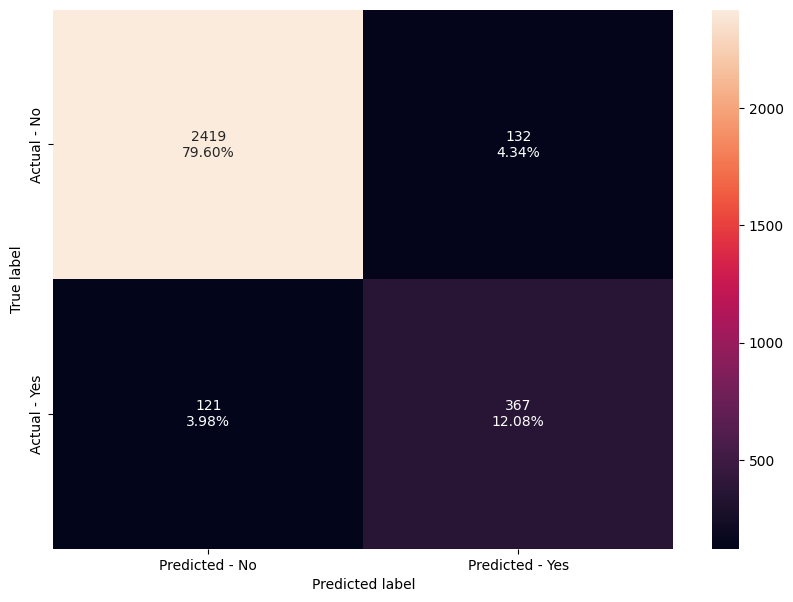

In [126]:
# Calculating different metrics
get_metrics_score(dtree_tuned1,X_train,X_test,y_train,y_test)

# Creating confusion matrix
make_confusion_matrix(dtree_tuned1, y_test)

- The test recall has decreased by ~5% as compared to the result from cross validation with default parameters.
- The model is slightly overfitting the training data in terms of recall.

#### RandomizedSearchCV

In [127]:
%%time

# Creating pipeline
pipe = make_pipeline(StandardScaler(), DecisionTreeClassifier(random_state=1))

# Parameter grid to pass in RandomSearchCV
param_grid = {'decisiontreeclassifier__max_depth': np.arange(2,30),
              'decisiontreeclassifier__min_samples_leaf': [1, 2, 5, 7, 10],
              'decisiontreeclassifier__max_leaf_nodes' : [2, 3, 5, 10,15],
              'decisiontreeclassifier__min_impurity_decrease': [0.0001,0.001,0.01,0.1]
             }

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=pipe, param_distributions=param_grid, n_jobs = -1, n_iter=50, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train,y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'decisiontreeclassifier__min_samples_leaf': 5, 'decisiontreeclassifier__min_impurity_decrease': 0.001, 'decisiontreeclassifier__max_leaf_nodes': 10, 'decisiontreeclassifier__max_depth': np.int64(26)} with CV score=0.7796815828116547:
CPU times: user 530 ms, sys: 43.2 ms, total: 574 ms
Wall time: 11.9 s


In [128]:
# Creating new pipeline with best parameters
dtree_tuned2 = make_pipeline(
    StandardScaler(),
    DecisionTreeClassifier(
        max_depth=26,
        max_leaf_nodes=10,
        random_state=1,
        min_impurity_decrease=0.001,
        min_samples_leaf=5
    ),
)

# Fit the model on training data
dtree_tuned2.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(max_depth=26, max_leaf_nodes=10,
                                        min_impurity_decrease=0.001,
                                        min_samples_leaf=5, random_state=1))])

Accuracy on training set :  0.9283295711060948
Accuracy on test set :  0.9108259295820994
Recall on training set :  0.8235294117647058
Recall on test set :  0.7848360655737705
Precision on training set :  0.7534136546184739
Precision on test set :  0.697632058287796


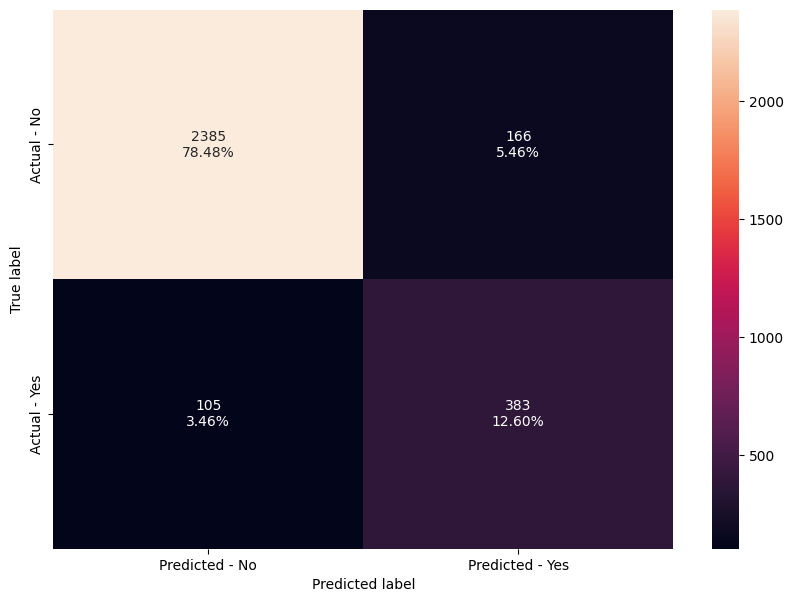

In [129]:
# Calculating different metrics
get_metrics_score(dtree_tuned2,X_train,X_test,y_train,y_test)

# Creating confusion matrix
make_confusion_matrix(dtree_tuned2, y_test)

- Grid search took significantly longer time than random search. This difference would further increase as the number of parameters increases.  
- The model performance improved in terms of recall for parameters given by random search.
- The model is slightly overfitting the data for parameters given by random search.

### Hyperparameter tuning BaggingClassifier

#### GridSearchCV

In [130]:
%%time

# Creating pipeline
pipe = make_pipeline(StandardScaler(), BaggingClassifier(random_state=1))

# Parameter grid to pass in GridSearchCV

param_grid = {
              'baggingclassifier__max_samples': [0.7,0.8,0.9,1],
              'baggingclassifier__max_features': [0.7,0.8,0.9,1],
              'baggingclassifier__n_estimators' : [10,20,30,40,50],
             }

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

# Calling GridSearchCV
grid_cv = GridSearchCV(estimator=pipe, param_grid=param_grid, scoring=scorer, cv=5, n_jobs = -1)

# Fitting parameters in GridSeachCV
grid_cv.fit(X_train, y_train)

print(
    "Best Parameters:{} \nScore: {}".format(grid_cv.best_params_, grid_cv.best_score_)
)

Best Parameters:{'baggingclassifier__max_features': 0.9, 'baggingclassifier__max_samples': 0.9, 'baggingclassifier__n_estimators': 50} 
Score: 0.8472370353195766
CPU times: user 5.08 s, sys: 322 ms, total: 5.41 s
Wall time: 3min 49s


In [131]:
# Creating new pipeline with best parameters
bagg_tuned1 = make_pipeline(
    StandardScaler(),
    BaggingClassifier(
        max_features=0.8,
        max_samples=0.7,
        random_state=1,
        n_estimators=50,
    ),
)

# Fit the model on training data
bagg_tuned1.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('baggingclassifier',
                 BaggingClassifier(max_features=0.8, max_samples=0.7,
                                   n_estimators=50, random_state=1))])

Accuracy on training set :  0.9980248306997742
Accuracy on test set :  0.9651201052977953
Recall on training set :  0.9885864793678666
Recall on test set :  0.8442622950819673
Precision on training set :  0.9991126885536823
Precision on test set :  0.9321266968325792


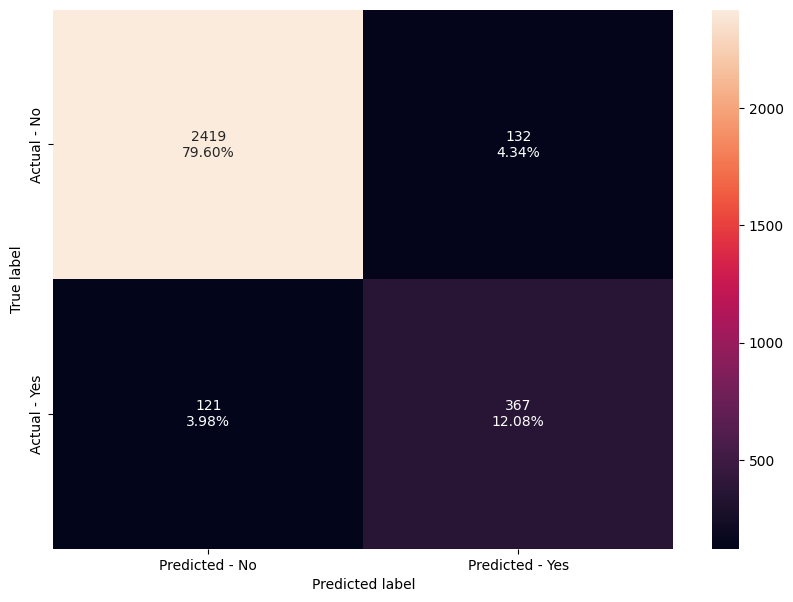

In [132]:
# Calculating different metrics
get_metrics_score(bagg_tuned1,X_train,X_test,y_train,y_test)

# Creating confusion matrix
make_confusion_matrix(dtree_tuned1, y_test)

- The test recall has increased by ~2% as compared to the result from cross validation with default parameters.
- The model is overfitting the training data in terms of recall.

#### RandomizedSearchCV

In [133]:
%%time

# Creating pipeline
pipe = make_pipeline(StandardScaler(), BaggingClassifier(random_state=1))

# Parameter grid to pass in RandomSearchCV
param_grid = {
              'baggingclassifier__max_samples': [0.7,0.8,0.9,1],
              'baggingclassifier__max_features': [0.7,0.8,0.9,1],
              'baggingclassifier__n_estimators' : [10,20,30,40,50],
             }

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=pipe, param_distributions=param_grid, n_jobs = -1, n_iter=50, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train,y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'baggingclassifier__n_estimators': 50, 'baggingclassifier__max_samples': 0.9, 'baggingclassifier__max_features': 0.9} with CV score=0.8472370353195766:
CPU times: user 3.99 s, sys: 200 ms, total: 4.19 s
Wall time: 2min 11s


In [134]:
# Creating new pipeline with best parameters
bagg_tuned2 = make_pipeline(
    StandardScaler(),
    BaggingClassifier(
        max_features=0.8,
        random_state=1,
        max_samples=0.7,
        n_estimators=50
    ),
)

# Fit the model on training data
bagg_tuned2.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('baggingclassifier',
                 BaggingClassifier(max_features=0.8, max_samples=0.7,
                                   n_estimators=50, random_state=1))])

Accuracy on training set :  0.9980248306997742
Accuracy on test set :  0.9651201052977953
Recall on training set :  0.9885864793678666
Recall on test set :  0.8442622950819673
Precision on training set :  0.9991126885536823
Precision on test set :  0.9321266968325792


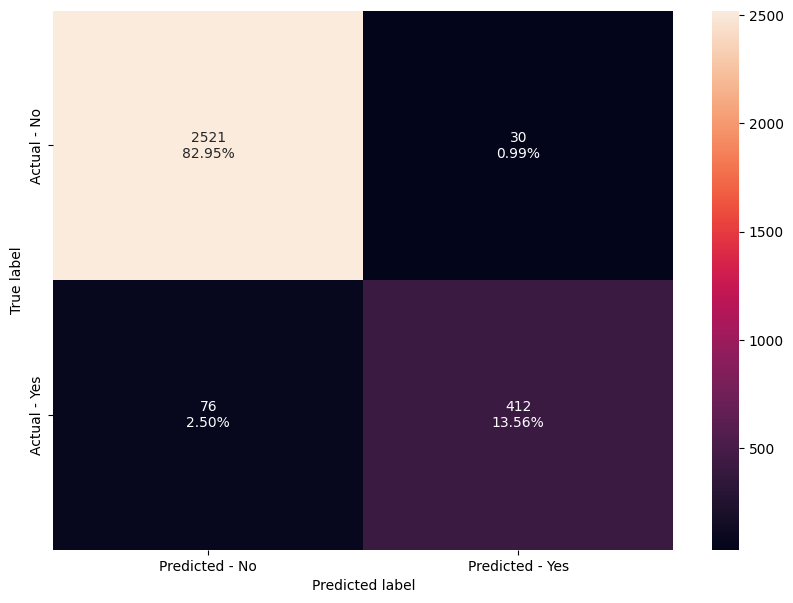

In [135]:
# Calculating different metrics
get_metrics_score(bagg_tuned2,X_train,X_test,y_train,y_test)

# Creating confusion matrix
make_confusion_matrix(bagg_tuned2, y_test)

- Grid search took significantly longer time than random search. This difference would further increase as the number of parameters increases.  
- The parameters from random search are exactly same as compared grid search.
- The model is overfitting the data for parameters given by random search.

### Hyperparameter tuning Random Forest

#### GridSearchCV

In [136]:
%%time

# Creating pipeline
pipe = make_pipeline(StandardScaler(), RandomForestClassifier(random_state=1))

# Parameter grid to pass in GridSearchCV

param_grid = {
    "randomforestclassifier__n_estimators": [100,150,250],
    "randomforestclassifier__min_samples_leaf": np.arange(1, 6),
    "randomforestclassifier__max_features": [np.arange(0.3, 0.6, 0.1),'sqrt','log2'],
    "randomforestclassifier__max_samples": np.arange(0.2, 0.6, 0.1),
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

# Calling GridSearchCV
grid_cv = GridSearchCV(estimator=pipe, param_grid=param_grid, scoring=scorer, cv=5, n_jobs = -1)

# Fitting parameters in GridSeachCV
grid_cv.fit(X_train, y_train)

print(
    "Best Parameters:{} \nScore: {}".format(grid_cv.best_params_, grid_cv.best_score_)
)

Best Parameters:{'randomforestclassifier__max_features': 'sqrt', 'randomforestclassifier__max_samples': np.float64(0.5000000000000001), 'randomforestclassifier__min_samples_leaf': np.int64(1), 'randomforestclassifier__n_estimators': 250} 
Score: 0.7559084937012134
CPU times: user 6.91 s, sys: 751 ms, total: 7.66 s
Wall time: 9min


In [137]:
# Creating new pipeline with best parameters
rf_tuned1 = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(
        n_estimators=250,
        max_features='sqrt',
        random_state=1,
        max_samples=0.5000000000000001,
        min_samples_leaf=1
    ),
)

# Fit the model on training data
rf_tuned1.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('randomforestclassifier',
                 RandomForestClassifier(max_samples=0.5000000000000001,
                                        n_estimators=250, random_state=1))])

Accuracy on training set :  0.9954853273137697
Accuracy on test set :  0.9516288252714709
Recall on training set :  0.9736611062335382
Recall on test set :  0.7520491803278688
Precision on training set :  0.9981998199819982
Precision on test set :  0.9338422391857506


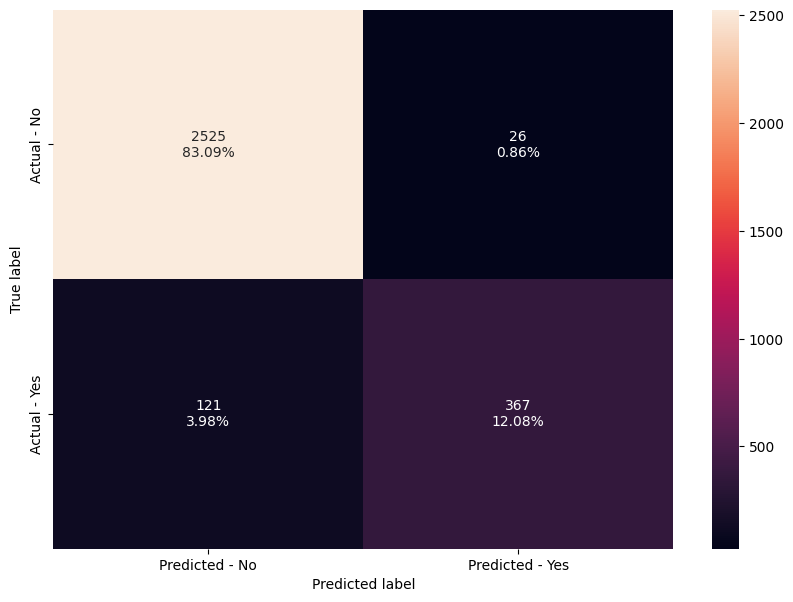

In [138]:
# Calculating different metrics
get_metrics_score(rf_tuned1,X_train,X_test,y_train,y_test)

# Creating confusion matrix
make_confusion_matrix(rf_tuned1, y_test)

- The test recall has decreased by ~2% as compared to the result from cross validation with default parameters.
- The model is overfitting the training data in terms of recall.

#### RandomizedSearchCV

In [139]:
%%time

# Creating pipeline
pipe = make_pipeline(StandardScaler(), RandomForestClassifier(random_state=1))

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "randomforestclassifier__n_estimators": [100,150,250],
    "randomforestclassifier__min_samples_leaf": np.arange(1, 6),
    "randomforestclassifier__max_features": [np.arange(0.3, 0.6, 0.1),'sqrt','log2'],
    "randomforestclassifier__max_samples": np.arange(0.2, 0.6, 0.1),
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=pipe, param_distributions=param_grid, n_jobs = -1, n_iter=50, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train,y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'randomforestclassifier__n_estimators': 250, 'randomforestclassifier__min_samples_leaf': np.int64(1), 'randomforestclassifier__max_samples': np.float64(0.5000000000000001), 'randomforestclassifier__max_features': 'sqrt'} with CV score=0.7559084937012134:
CPU times: user 3.81 s, sys: 236 ms, total: 4.05 s
Wall time: 2min 7s


In [140]:
# Creating new pipeline with best parameters
rf_tuned2 = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(
        n_estimators=250,
        max_features='sqrt',
        random_state=1,
        max_samples=0.5000000000000001,
        min_samples_leaf=1
    ),
)

# Fit the model on training data
rf_tuned2.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('randomforestclassifier',
                 RandomForestClassifier(max_samples=0.5000000000000001,
                                        n_estimators=250, random_state=1))])

Accuracy on training set :  0.9954853273137697
Accuracy on test set :  0.9516288252714709
Recall on training set :  0.9736611062335382
Recall on test set :  0.7520491803278688
Precision on training set :  0.9981998199819982
Precision on test set :  0.9338422391857506


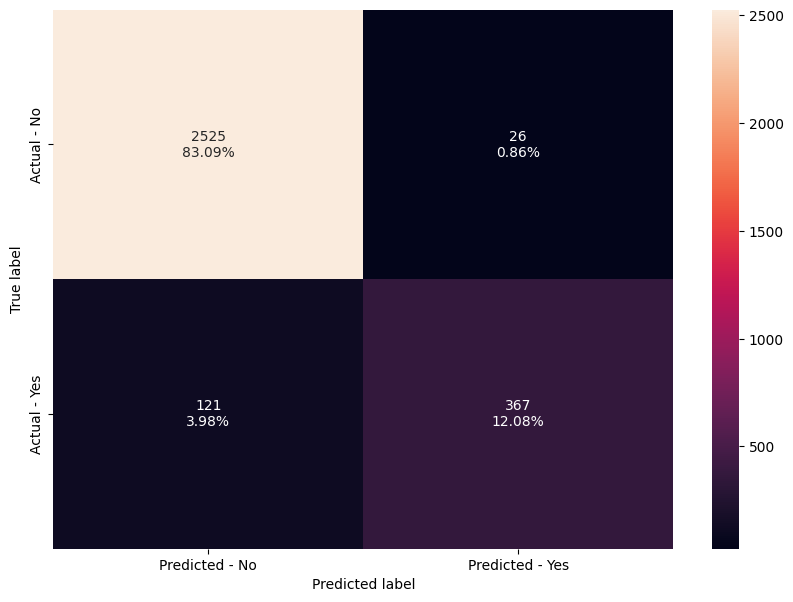

In [141]:
# Calculating different metrics
get_metrics_score(rf_tuned2,X_train,X_test,y_train,y_test)

# Creating confusion matrix
make_confusion_matrix(rf_tuned2, y_test)

- Grid search took significantly longer time than random search. This difference would further increase as the number of parameters increases.  
- The parameters from random search are exactly same as compared grid search except the base estimator.
- The model is overfitting the data for parameters given by random search.

### Hyperparameter tuning AdaBoost

#### GridSearchCV

In [144]:
%%time

# Creating pipeline
pipe = make_pipeline(StandardScaler(), AdaBoostClassifier(random_state=1))

# Parameter grid to pass in GridSearchCV
param_grid = {
    "adaboostclassifier__n_estimators": np.arange(10, 110, 10),
    "adaboostclassifier__learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "adaboostclassifier__estimator": [
        DecisionTreeClassifier(max_depth=1, random_state=1),
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}

# Calling GridSearchCV (scoring="recall" is the same as make_scorer(recall_score))
grid_cv = GridSearchCV(estimator=pipe, param_grid=param_grid, scoring="recall", cv=5, n_jobs=-1)
grid_cv.fit(X_train, y_train)

print("Best Parameters:{} \nScore: {}".format(grid_cv.best_params_, grid_cv.best_score_))

Best Parameters:{'adaboostclassifier__estimator': DecisionTreeClassifier(max_depth=3, random_state=1), 'adaboostclassifier__learning_rate': 1, 'adaboostclassifier__n_estimators': np.int64(100)} 
Score: 0.8849911121415875
CPU times: user 8.37 s, sys: 868 ms, total: 9.23 s
Wall time: 11min 35s


In [145]:
# Creating new pipeline with best parameters
abc_tuned1 = make_pipeline(
    StandardScaler(),
    AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3, random_state=1),   # was: base_estimator=
        n_estimators=100,
        learning_rate=0.2,
        random_state=1,
    ),
)

# Fit the model on training data
abc_tuned1.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('adaboostclassifier',
                 AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                                     random_state=1),
                                    learning_rate=0.2, n_estimators=100,
                                    random_state=1))])

Accuracy on training set :  0.9740406320541761
Accuracy on test set :  0.9638038828562027
Recall on training set :  0.887620719929763
Recall on test set :  0.8319672131147541
Precision on training set :  0.9475164011246485
Precision on test set :  0.9354838709677419


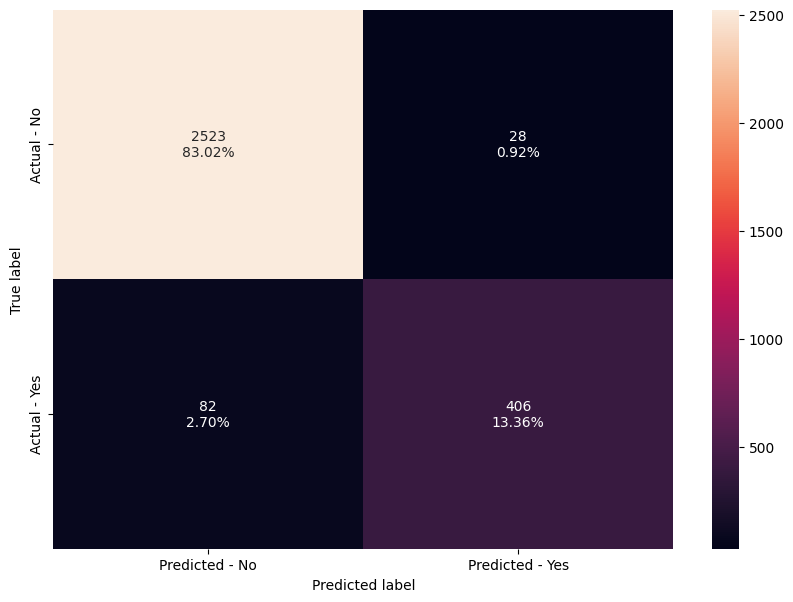

In [146]:
# Calculating different metrics
get_metrics_score(abc_tuned1,X_train,X_test,y_train,y_test)

# Creating confusion matrix
make_confusion_matrix(abc_tuned1, y_test)

- The test recall has increased by ~3% as compared to the result from cross validation with default parameters.
* Model is slightly overfitting in terms of recall.

#### RandomizedSearchCV

In [149]:
%%time

# Creating pipeline
pipe = make_pipeline(StandardScaler(), AdaBoostClassifier(random_state=1))

# Parameter grid to pass in RandomizedSearchCV
param_grid = {
    "adaboostclassifier__n_estimators": np.arange(10, 110, 10),
    "adaboostclassifier__learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "adaboostclassifier__estimator": [                      # was: base_estimator
        DecisionTreeClassifier(max_depth=1, random_state=1),
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}

# Calling RandomizedSearchCV (scoring="recall" is the same as make_scorer(recall_score))
randomized_cv = RandomizedSearchCV(estimator=pipe, param_distributions=param_grid, n_iter=50,
                                   scoring="recall", cv=5, random_state=1, n_jobs=-1)

# Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train, y_train)

print("Best parameters are {} with CV score={}".format(randomized_cv.best_params_, randomized_cv.best_score_))

Best parameters are {'adaboostclassifier__n_estimators': np.int64(70), 'adaboostclassifier__learning_rate': 1, 'adaboostclassifier__estimator': DecisionTreeClassifier(max_depth=3, random_state=1)} with CV score=0.8832251333178762
CPU times: user 3.82 s, sys: 287 ms, total: 4.11 s
Wall time: 4min 1s


In [151]:
# Creating new pipeline with best parameters
abc_tuned2 = make_pipeline(
    StandardScaler(),
    AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=2, random_state=1),   # was: base_estimator=
        n_estimators=50,
        learning_rate=1,
        random_state=1,
    ),
)

# Fit the model on training data
abc_tuned2.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('adaboostclassifier',
                 AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2,
                                                                     random_state=1),
                                    learning_rate=1, random_state=1))])

Accuracy on training set :  0.9702313769751693
Accuracy on test set :  0.953932214544258
Recall on training set :  0.8674275680421423
Recall on test set :  0.7827868852459017
Precision on training set :  0.9427480916030534
Precision on test set :  0.9182692307692307


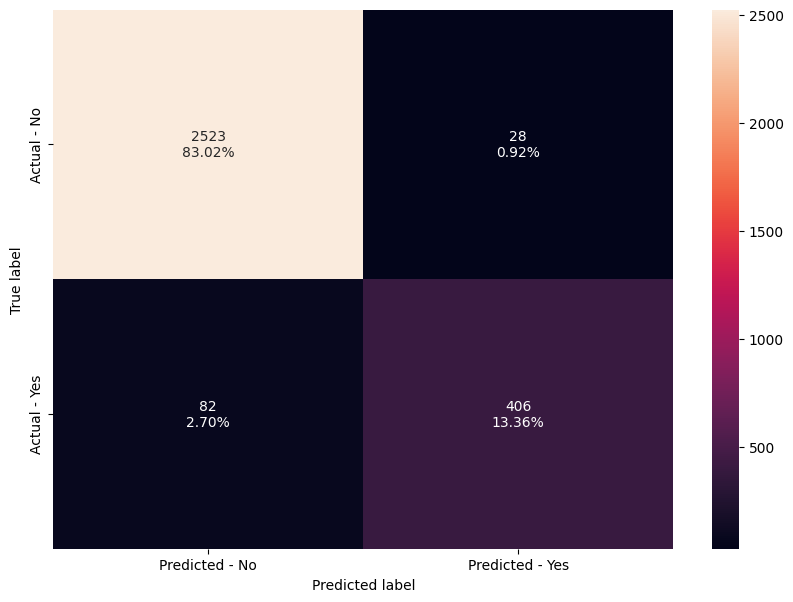

In [152]:
# Calculating different metrics
get_metrics_score(abc_tuned2,X_train,X_test,y_train,y_test)

# Creating confusion matrix
make_confusion_matrix(abc_tuned1, y_test)

- Grid search took significantly longer time than random search. This difference would further increase as the number of parameters increases.  
- The parameters from random search are almost same as compared grid search except the base estimator and estimators.
- The model is slightly overfitting the data for parameters given by random search.

### Hyperparameter tuning GradientBoosting

#### GridSearchCV

In [153]:
%%time

# Creating pipeline
pipe = make_pipeline(StandardScaler(), GradientBoostingClassifier(random_state=1))

# Parameter grid to pass in GridSearchCV
param_grid = {
    "gradientboostingclassifier__init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "gradientboostingclassifier__n_estimators": np.arange(75,150,25),
    "gradientboostingclassifier__learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "gradientboostingclassifier__subsample":[0.5,0.7,1],
    "gradientboostingclassifier__max_features":[0.5,0.7,1],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

# Calling GridSearchCV
grid_cv = GridSearchCV(estimator=pipe, param_grid=param_grid, scoring=scorer, cv=5, n_jobs = -1)

# Fitting parameters in GridSeachCV
grid_cv.fit(X_train, y_train)

print(
    "Best Parameters:{} \nScore: {}".format(grid_cv.best_params_, grid_cv.best_score_)
)

Best Parameters:{'gradientboostingclassifier__init': AdaBoostClassifier(random_state=1), 'gradientboostingclassifier__learning_rate': 0.2, 'gradientboostingclassifier__max_features': 0.5, 'gradientboostingclassifier__n_estimators': np.int64(125), 'gradientboostingclassifier__subsample': 1} 
Score: 0.8832367261766751
CPU times: user 12.9 s, sys: 1.76 s, total: 14.7 s
Wall time: 22min 55s


In [154]:
# Creating new pipeline with best parameters
gbc_tuned1 = make_pipeline(
    StandardScaler(),
    GradientBoostingClassifier(
        init=AdaBoostClassifier(random_state=1),
        learning_rate=0.2,
        max_features=0.7,
        n_estimators=125,
        subsample=1,
        random_state=1,
    ),
)

# Fit the model on training data
gbc_tuned1.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('gradientboostingclassifier',
                 GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                                            learning_rate=0.2, max_features=0.7,
                                            n_estimators=125, random_state=1,
                                            subsample=1))])

Accuracy on training set :  0.9906884875846501
Accuracy on test set :  0.9697268838433696
Recall on training set :  0.9596136962247586
Recall on test set :  0.875
Precision on training set :  0.9820305480682839
Precision on test set :  0.9323144104803494


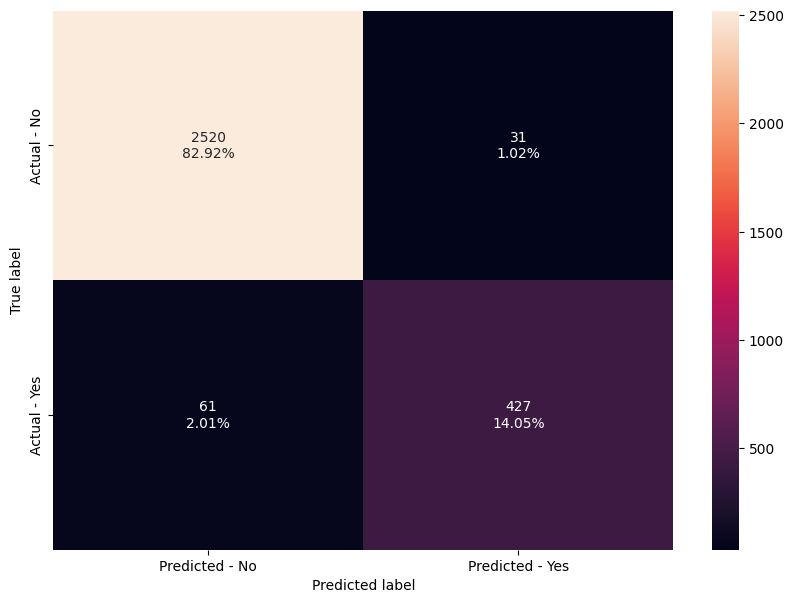

In [155]:
# Calculating different metrics
get_metrics_score(gbc_tuned1,X_train,X_test,y_train,y_test)

# Creating confusion matrix
make_confusion_matrix(gbc_tuned1, y_test)

- The test recall has increased by ~1% as compared to the result from cross validation with default parameters.
- The model is slightly overfitting the training data in terms of recall.

#### RandomizedSearchCV

In [156]:
%%time

#Creating pipeline
pipe=make_pipeline(StandardScaler(),GradientBoostingClassifier(random_state=1))

#Parameter grid to pass in RandomSearchCV
param_grid = {
    "gradientboostingclassifier__init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "gradientboostingclassifier__n_estimators": np.arange(75,150,25),
    "gradientboostingclassifier__learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "gradientboostingclassifier__subsample":[0.5,0.7,1],
    "gradientboostingclassifier__max_features":[0.5,0.7,1],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=pipe, param_distributions=param_grid, n_iter=50, scoring=scorer, cv=5, random_state=1, n_jobs = -1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train,y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'gradientboostingclassifier__subsample': 0.7, 'gradientboostingclassifier__n_estimators': np.int64(125), 'gradientboostingclassifier__max_features': 0.7, 'gradientboostingclassifier__learning_rate': 0.2, 'gradientboostingclassifier__init': AdaBoostClassifier(random_state=1)} with CV score=0.8814746116392304:
CPU times: user 4.57 s, sys: 335 ms, total: 4.91 s
Wall time: 4min 23s


In [157]:
# Creating new pipeline with best parameters
gbc_tuned2 = make_pipeline(
    StandardScaler(),
    GradientBoostingClassifier(
        init=AdaBoostClassifier(random_state=1),
        learning_rate=0.2,
        max_features=0.7,
        n_estimators=125,
        subsample=1,
        random_state=1,
    ),
)

# Fit the model on training data
gbc_tuned2.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('gradientboostingclassifier',
                 GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                                            learning_rate=0.2, max_features=0.7,
                                            n_estimators=125, random_state=1,
                                            subsample=1))])

Accuracy on training set :  0.9906884875846501
Accuracy on test set :  0.9697268838433696
Recall on training set :  0.9596136962247586
Recall on test set :  0.875
Precision on training set :  0.9820305480682839
Precision on test set :  0.9323144104803494


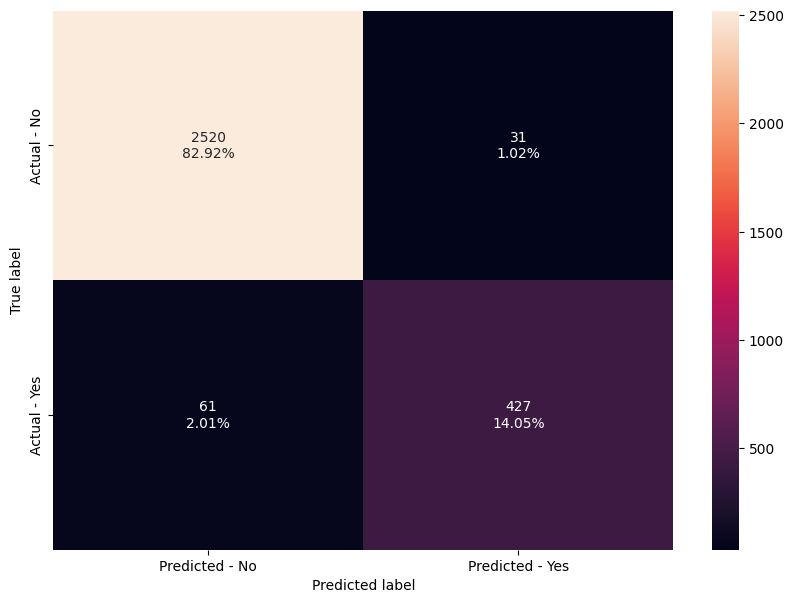

In [158]:
# Calculating different metrics
get_metrics_score(gbc_tuned2,X_train,X_test,y_train,y_test)

# Creating confusion matrix
make_confusion_matrix(gbc_tuned2, y_test)

- Grid search took significantly longer time than random search. This difference would further increase as the number of parameters increases.  
- The parameters from random search are exactly same as compared grid search.
- The model is slightly overfitting the data for parameters given by random search.

### Hyperparameter tuning XGBoost

#### GridSearchCV

In [159]:
%%time

#Creating pipeline
pipe=make_pipeline(StandardScaler(), XGBClassifier(random_state=1,eval_metric='logloss'))

#Parameter grid to pass in GridSearchCV
param_grid={'xgbclassifier__n_estimators':np.arange(50,300,50),'xgbclassifier__scale_pos_weight':[0,1,2,5,10],
            'xgbclassifier__learning_rate':[0.01,0.1,0.2,0.05], 'xgbclassifier__gamma':[0,1,3,5],
            'xgbclassifier__subsample':[0.7,0.8,0.9,1]}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling GridSearchCV
grid_cv = GridSearchCV(estimator=pipe, param_grid=param_grid, scoring=scorer, cv=5, n_jobs = -1)

#Fitting parameters in GridSeachCV
grid_cv.fit(X_train,y_train)


print("Best parameters are {} with CV score={}:" .format(grid_cv.best_params_,grid_cv.best_score_))

Best parameters are {'xgbclassifier__gamma': 0, 'xgbclassifier__learning_rate': 0.01, 'xgbclassifier__n_estimators': np.int64(50), 'xgbclassifier__scale_pos_weight': 10, 'xgbclassifier__subsample': 0.8} with CV score=0.9771775253110752:
CPU times: user 44.1 s, sys: 5.6 s, total: 49.7 s
Wall time: 40min 43s


In [160]:
# Creating new pipeline with best parameters
xgb_tuned1 = make_pipeline(
    StandardScaler(),
    XGBClassifier(
        random_state=1,
        n_estimators=250,
        scale_pos_weight=10,
        subsample=0.7,
        learning_rate=0.01,
        gamma=1,
        eval_metric='logloss',
    ),
)

# Fit the model on training data
xgb_tuned1.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('xgbclassifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=True, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=1, grow_policy=None, importance_type=None,
                               interaction_constraints=None, learning_rate=0.01,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=250, n_jobs=None,
                               num_parallel_tree=None, ...))])

Accuracy on training set :  0.9554176072234764
Accuracy on test set :  0.9338598223099703
Recall on training set :  0.9991220368744512
Recall on test set :  0.9508196721311475
Precision on training set :  0.7832071576049553
Precision on test set :  0.7238689547581904


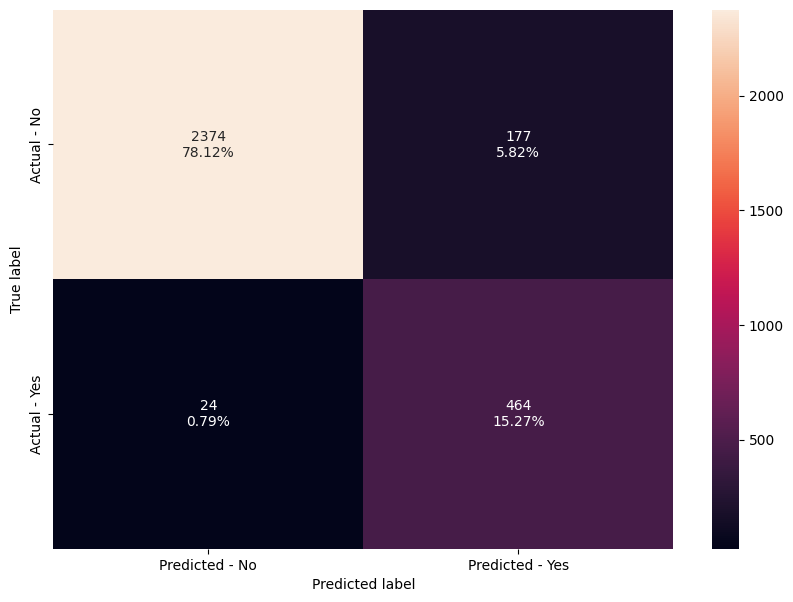

In [161]:
# Calculating different metrics
get_metrics_score(xgb_tuned1,X_train,X_test,y_train,y_test)

# Creating confusion matrix
make_confusion_matrix(xgb_tuned1, y_test)

- The test recall has increased by ~7% as compared to the result from cross validation with default parameters.
* Model has given a generalized performance on training and test set.

#### RandomizedSearchCV

In [162]:
%%time

#Creating pipeline
pipe=make_pipeline(StandardScaler(),XGBClassifier(random_state=1,eval_metric='logloss'))

#Parameter grid to pass in RandomSearchCV
param_grid={'xgbclassifier__n_estimators':np.arange(50,300,50),'xgbclassifier__scale_pos_weight':[0,1,2,5,10],
            'xgbclassifier__learning_rate':[0.01,0.1,0.2,0.05], 'xgbclassifier__gamma':[0,1,3,5],
            'xgbclassifier__subsample':[0.7,0.8,0.9,1]}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=pipe, param_distributions=param_grid, n_iter=50, n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train,y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'xgbclassifier__subsample': 0.7, 'xgbclassifier__scale_pos_weight': 10, 'xgbclassifier__n_estimators': np.int64(50), 'xgbclassifier__learning_rate': 0.2, 'xgbclassifier__gamma': 5} with CV score=0.942936084705155:
CPU times: user 1.73 s, sys: 157 ms, total: 1.89 s
Wall time: 1min 9s


In [163]:
# Creating new pipeline with best parameters
xgb_tuned2 = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "XGB",
            XGBClassifier(
                random_state=1,
                n_estimators=150,
                scale_pos_weight=10,
                learning_rate=0.05,
                gamma=3,
                subsample=0.7,
                eval_metric='logloss',
            ),
        ),
    ]
)
# Fit the model on training data
xgb_tuned2.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('XGB',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=True, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=3, grow_policy=None, importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=150, n_jobs=None,
                               num_parallel_tree=None, ...))])

Accuracy on training set :  0.9816591422121896
Accuracy on test set :  0.9595261599210266
Recall on training set :  1.0
Recall on test set :  0.9426229508196722
Precision on training set :  0.8975571315996848
Precision on test set :  0.8288288288288288


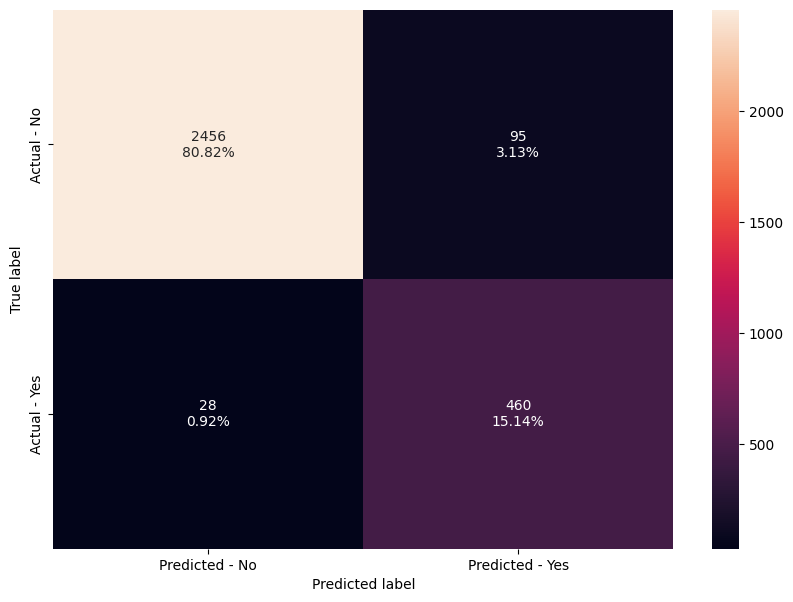

In [164]:
# Calculating different metrics
get_metrics_score(xgb_tuned2,X_train,X_test,y_train,y_test)

# Creating confusion matrix
make_confusion_matrix(xgb_tuned2, y_test)

- Grid search took significantly longer time than random search. This difference would further increase as the number of parameters increases.  
- The parameters from random search are significantly different as compared grid search.
- The model has given a generalized performance on training and test set.

In [165]:
# defining list of model
models = [lr]

# defining empty lists to add train and test results
acc_train = []
acc_test = []
recall_train = []
recall_test = []
precision_train = []
precision_test = []

# looping through all the models to get the metrics score - Accuracy, Recall and Precision
for model in models:

    j = get_metrics_score(model,X_train,X_test,y_train,y_test,False)
    acc_train.append(j[0])
    acc_test.append(j[1])
    recall_train.append(j[2])
    recall_test.append(j[3])
    precision_train.append(j[4])
    precision_test.append(j[5])

In [166]:
# defining list of models
models = [log_reg_over, lr_estimator]

# looping through all the models to get the metrics score - Accuracy, Recall and Precision
for model in models:

    j = get_metrics_score(model,X_train_over,X_test,y_train_over,y_test,False)
    acc_train.append(j[0])
    acc_test.append(j[1])
    recall_train.append(j[2])
    recall_test.append(j[3])
    precision_train.append(j[4])
    precision_test.append(j[5])

In [167]:
# defining list of model
models = [log_reg_under]

# looping through all the models to get the metrics score - Accuracy, Recall and Precision
for model in models:

    j = get_metrics_score(model,X_train_un,X_test,y_train_un,y_test,False)
    acc_train.append(j[0])
    acc_test.append(j[1])
    recall_train.append(j[2])
    recall_test.append(j[3])
    precision_train.append(j[4])
    precision_test.append(j[5])

In [168]:
# defining list of models
models = [dtree_tuned1,dtree_tuned2,bagg_tuned1,bagg_tuned2,rf_tuned1,rf_tuned2,abc_tuned1,abc_tuned2,gbc_tuned1,gbc_tuned2,xgb_tuned1, xgb_tuned2]


# looping through all the models to get the metrics score - Accuracy, Recall and Precision
for model in models:

    j = get_metrics_score(model,X_train,X_test,y_train,y_test,False)
    acc_train.append(j[0])
    acc_test.append(j[1])
    recall_train.append(j[2])
    recall_test.append(j[3])
    precision_train.append(j[4])
    precision_test.append(j[5])

In [169]:
comparison_frame = pd.DataFrame(
    {
        "Model": [
            "Logistic Regression",
            'Logistic Regression on Oversampled data',
            'Logistic Regression-Regularized (Oversampled data)',
            'Logistic Regression on Undersampled data',
            "Decision Tree with GridSearchCV",
            "Decision Tree with RandomizedSearchCV",
            "Bagging Classifier with GridSearchCV",
            "Bagging Classifier with RandomizedSearchCV",
            "Random Forest with GridSearchCV",
            "Random Forest with RandomizedSearchCV",
            "AdaBoost with GridSearchCV",
            "AdaBoost Tree with RandomizedSearchCV",
            "GradientBoost with GridSearchCV",
            "GradientBoost Tree with RandomizedSearchCV",
            "XGBoost with GridSearchCV",
            "XGBoost with RandomizedSearchCV",
        ],
        "Train_Accuracy": acc_train,
        "Test_Accuracy": acc_test,
        "Train_Recall": recall_train,
        "Test_Recall": recall_test,
        "Train_Precision": precision_train,
        "Test_Precision": precision_test,
    }
)

# Sorting models in decreasing order of test recall
comparison_frame

,Model,Train_Accuracy,Test_Accuracy,Train_Recall,Test_Recall,Train_Precision,Test_Precision
0,Logistic Regression,0.878,0.882,0.425,0.426,0.695,0.725
1,Logistic Regression on Oversampled data,0.830,0.812,0.843,0.789,0.821,0.451
2,Logistic Regression-Regularized (Oversampled d...,0.707,0.804,0.574,0.553,0.781,0.417
3,Logistic Regression on Undersampled data,0.817,0.817,0.820,0.801,0.815,0.459
4,Decision Tree with GridSearchCV,0.940,0.917,0.821,0.752,0.809,0.735
5,Decision Tree with RandomizedSearchCV,0.928,0.911,0.824,0.785,0.753,0.698
6,Bagging Classifier with GridSearchCV,0.998,0.965,0.989,0.844,0.999,0.932
7,Bagging Classifier with RandomizedSearchCV,0.998,0.965,0.989,0.844,0.999,0.932
8,Random Forest with GridSearchCV,0.995,0.952,0.974,0.752,0.998,0.934
9,Random Forest with RandomizedSearchCV,0.995,0.952,0.974,0.752,0.998,0.934


- The xgboost model tuned using RandomizedSearchCV is giving the best test recall of 0.95 and an overall generalized performance.
- Let's see the feature importance from the tuned xgboost model

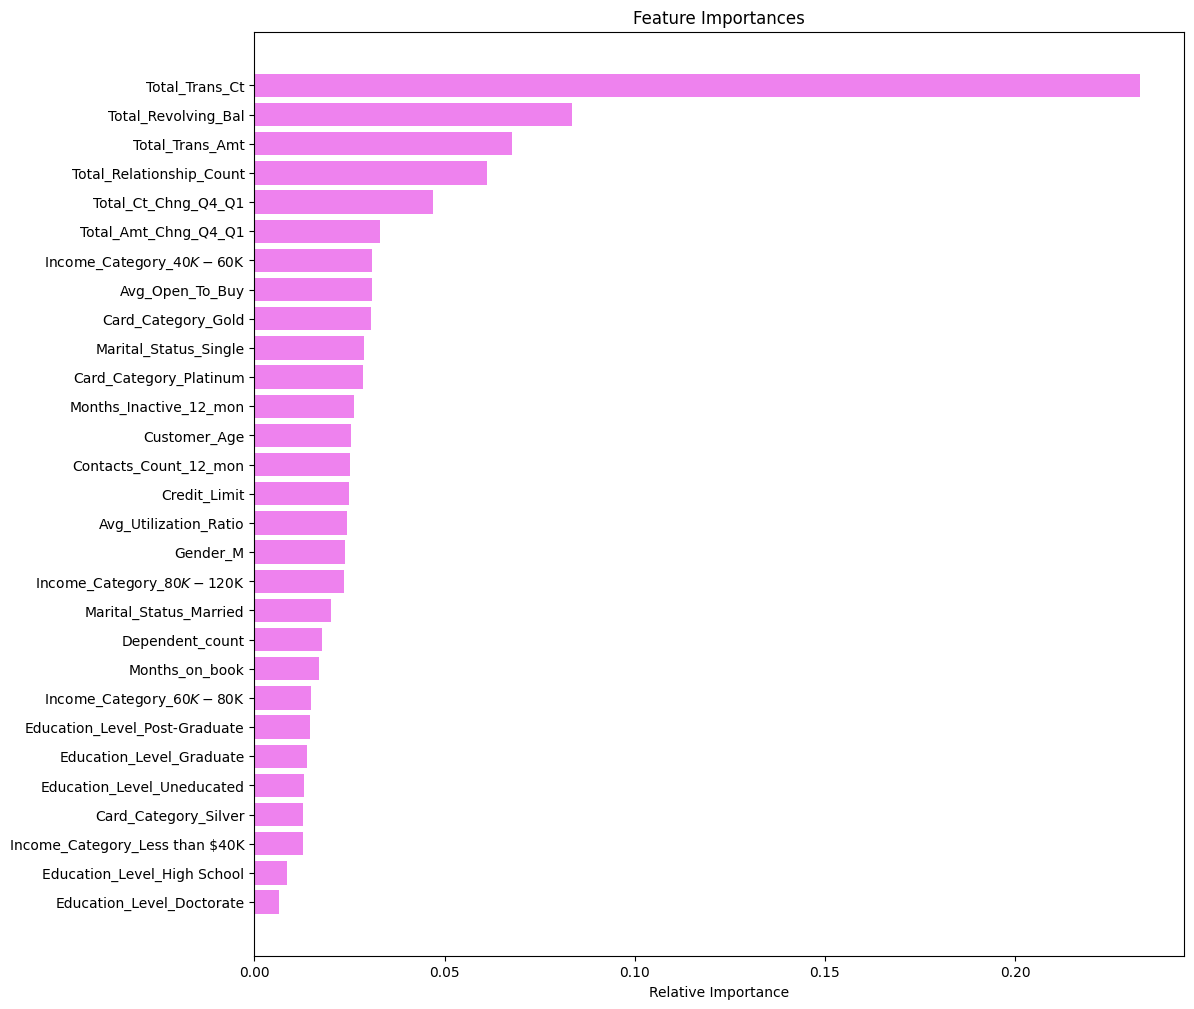

In [171]:
feature_names = X_train.columns
importances = xgb_tuned2[1].feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

* Total_Trans_Ct is the most important variable in predicting credit card churn followed by Total_Revolving_Bal, Total_Trans_Amt, Total_Relationship_Count, Total_Ct_Chng_Q4_Q1 and Martial_Status.

## Thamilarasan Ramasamy's Business Recommendations

* I have been able to build a predictive model:

  a) that bank can deploy this model to identify customers who are at the risk of attrition.
  
  b) that the bank can use to find the key causes that drive attrition.
  
  c) based on which bank can take appropriate actions to build better retention policies for customers.
  

* Factors that drive the attrition - Total_Trans_Ct, Total_Revolving_Bal, Total_Trans_Amt, Total_Relationship_Count
* Total_Trans_Ct: Less number of transactions in a year leads to attrition of a customer - to increase the usage of cards the bank can provide offers like cashback, special discounts on the purchase of something, etc so that customers feel motivated to use their cards.

* Total_Revolving_Bal: Customers with less total revolving balance are the ones who attrited, such customers must have cleared their dues and opted out of the credit card service. After the customer has cleared the dues bank can ask for a feedback on their experience and get to the casue of attrition.

* Total_Trans_Amt: Less number of transactions can lead to less transaction amount and eventually leads to customer attrition - Bank can provide offers on the purchase of costlier items which in-turn will benefit the customers and bank both.

* Total_Relationship_Count: Attrition is highest among the customers who are using 1 or 2 products offered by the bank - together they constitute ~55% of the attrition - Bank should investigate here to find the problems customers are facing with these products, customer support, or more transparency can help in retaining customers.

* Female customers should be the target customers for any kind of marketing campaign as they are the ones who utilize their credits, make more and higher amount transactions. But their credit limit is less so increasing the credit limit for such customers can profit the bank.

* Months_Inactive: As inactivity increases the attrition also increases, 2-4 months of inactivity are the biggest contributors of attrition -Bank can send automated messages to engage customers, these messages can be about their monthly activity, new offers or services, etc.

* Highest attrition is among the customers who interacted/reached out the most with/to the bank, This indicates that the bank is not able to resolve the problems faced by customers leading to attrition - a feedback collection system can be set-up to check if the customers are satisfied with the resolution provided, if not, the bank should act upon it accordingly.